# General Introduction to the Analysis

**Translational Regulation Analysis: 5′UTR, 3′UTR and Combined Regulatory Architecture**

**Overview**

This analysis investigates how sequence-encoded regulatory features within the 5′ untranslated region (5′UTR), 3′ untranslated region (3′UTR), and their combined architecture contribute to translational efficiency (TE) modulation.

Translational control is a multi-layered regulatory process influenced by:
- Sequence motifs
- RNA secondary structure propensity
- GC content and length
- Positional hexamers
- Potential RNA-binding protein (RBP) signatures
- Combinatorial interactions between 5′ and 3′ elements

Our goal is to determine whether UTR-encoded features can classify transcripts according to their translational behavior and whether distinct regulatory regimes emerge.

---

**Biological Rationale**

**5′UTR Contributions**
The 5′UTR primarily influences:
- Ribosome recruitment
- Scanning efficiency
- Start codon accessibility
- Upstream regulatory motifs (e.g., uORF-like patterns, Kozak context modulation)

Thus, we expect 5′UTR features to be enriched in determinants of **initiation control**.

**3′UTR Contributions**
The 3′UTR contributes to:
- mRNA stability
- Poly(A)-dependent translation enhancement
- miRNA-like regulatory signatures
- RNA-binding protein recruitment

These features may modulate translation through **post-initiation and stability-dependent mechanisms**.

**Combined 5′ + 3′ Architecture**
Regulatory behavior often emerges from coordinated 5′–3′ communication:
- Closed-loop formation
- Cooperative RBP binding
- Context-dependent motif interactions

Therefore, analyzing both regions together allows detection of **combinatorial regulatory logic** that may not be evident when each region is analyzed independently.

---

**Analytical Strategy**

We perform classification analysis using sequence-derived features from:

1. **5′UTR only**
2. **3′UTR only**
3. **5′UTR + 3′UTR combined**
4. **Augmented models incorporating regulatory distribution features (including bimodality)**

The workflow includes:
- Feature extraction (hexamers, motif presence, structural proxies)
- Dimensionality control and feature selection
- Cross-validated classification modeling
- Performance comparison across region-specific models
- Interpretation of regulatory signatures

The objective is not only predictive performance, but also biological interpretability:
- Which region contributes most?
- Are regulatory effects additive or synergistic?
- Do transcripts segregate into distinct regulatory states?

---

**Central Hypothesis**

We hypothesize that:

- Distinct UTR regions encode partially independent regulatory signals.
- Combined models outperform region-specific models due to emergent interactions.
- Translational regulation may exhibit **bimodal structure**, reflecting discrete regulatory regimes rather than a continuous spectrum.

# Dependencies

In [4]:
# Importing Libraries, Packages, and Functions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, kruskal
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler  
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.impute import KNNImputer
from sklearn.metrics import f1_score, recall_score, precision_recall_fscore_support
from itertools import product
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from statsmodels.stats.multitest import fdrcorrection
import lzma
import random
import pickle
from tqdm.notebook import tqdm
from tqdm import tqdm
import itertools
import sys
from collections import Counter


# Functions

## K-mers

*generate_kmers()* Generate_kmers generates a DataFrame of 6-mer frequencies (df_kmer_frequencies) and another DataFrame of 6-mer locations (df_kmer_locations) for a given list of DNA sequences, with both frequencies and locations normalized appropriately:<br>
__Frequencies:__ The count of each 6-mer divided by the total possible 6-mer positions in the sequence, providing a normalized frequency that accounts for varying sequence lengths.
__Locations:__ The distribution of each 6-mer across three equal segments of the sequence, normalized by the total count of the k-mer to give a relative distribution independent of the absolute k-mer count.<br>
Addtionally, I fixed bins to hold counts by thirds as bins = np.array([0.0, 0.33, 0.66, 1.0]), where previousely it was- bins = np.array([0.0, 0.33, 0.66])

In [8]:
def generate_kmers(dna_sequences, bases, k_i, label):
    """
    Generates k-mers of a specific length (k_i) from DNA sequences, with normalized frequencies and locations.

    Args:
        dna_sequences (list): List of DNA sequences.
        bases (list): List of nucleotide bases (e.g., ['A', 'C', 'G', 'T']).
        k_i (int): The length of k-mers to generate.
        label (str): A label for the column headings.

    Returns:
        pd.DataFrame: DataFrame with k-mer frequencies, normalized by sequence length.
        pd.DataFrame: DataFrame with coarse locations of k-mers, normalized by sequence length.
    """
    bins = np.array([0.0, 0.33, 0.66, 1.0])

    kmers = [''.join(p) for p in product(bases, repeat=k_i)]
    kmers = [kmer + "_" + label for kmer in kmers]

    kmer_frequencies = {kmer: [] for kmer in kmers}
    kmer_locations = {kmer + "_loc": [] for kmer in kmers}

    for sequence in dna_sequences:
        sequence_length = len(sequence)
        if sequence_length < k_i:
            for kmer in kmers:
                kmer_frequencies[kmer].append(0)
                kmer_locations[kmer + "_loc"].append([0, 0, 0])
            continue

        sequence_counts = {kmer: 0 for kmer in kmers}
        sequence_position = {kmer: [] for kmer in kmers}

        for i in range(sequence_length - k_i + 1):
            kmer = sequence[i:i + k_i] + "_" + label
            sequence_counts[kmer] += 1
            sequence_position[kmer].append(i / sequence_length)

        for kmer in kmers:
            total_kmers = sequence_length - k_i + 1
            kmer_frequencies[kmer].append(sequence_counts[kmer] / total_kmers)
            locations = np.digitize(sequence_position[kmer], bins) - 1
            location_counts = np.bincount(locations, minlength=3)
            normalized_location_counts = location_counts / sequence_counts[kmer] if sequence_counts[kmer] > 0 else [0, 0, 0]
            kmer_locations[kmer + "_loc"].append(normalized_location_counts)

    df_kmer_frequencies = pd.DataFrame(kmer_frequencies)
    df_kmer_locations = pd.DataFrame(kmer_locations)

    return df_kmer_frequencies, df_kmer_locations

In [9]:
def generate_kmers_byRange(dna_sequences, frm, to, k_i, label):
    """
    Generates k-mers of a specific length (k_i) from DNA sequences within specified range [frm, to]
    and computes normalized frequencies.

    Args:
        dna_sequences (pd.Series): Series of DNA sequences.
        frm (int): Starting index of the range within sequences.
        to (int): Ending index of the range within sequences.
        k_i (int): The length of k-mers to generate.
        label (str): A label for the column headings.

    Returns:
        pd.DataFrame: DataFrame with k-mer frequencies, normalized by sequence length,
                      with the same indices as the input dna_sequences.
    """
    kmers = [''.join(p) for p in product("ACGT", repeat=k_i)]
    kmer_frequencies = {kmer: [] for kmer in kmers}
    
    empty_counter = 0

    for sequence in dna_sequences:
        subseq = sequence[frm:to]  # Subset by range
        seq_len = len(subseq)
        
        if seq_len == 0:
            empty_counter += 1
            for kmer in kmers:
                kmer_frequencies[kmer].append(0)  # Set frequency to 0 for sequences with no substring
            continue
        
        if seq_len < k_i:
            for kmer in kmers:
                kmer_frequencies[kmer].append(0)  # Set frequency to 0 for short sequences
            continue

        # Count k-mers in the sequence
        sequence_counts = {kmer: 0 for kmer in kmers}
        for i in range(seq_len - k_i + 1):
            kmer = subseq[i:i + k_i]
            if kmer in sequence_counts:
                sequence_counts[kmer] += 1

        # Calculate normalized frequencies
        total_kmers = seq_len - k_i + 1
        for kmer in kmers:
            kmer_frequencies[kmer].append(sequence_counts[kmer] / total_kmers)

    df_kmer_frequencies = pd.DataFrame(kmer_frequencies, index=dna_sequences.index)
    df_kmer_frequencies.columns = [f"{col}_{label}" for col in df_kmer_frequencies.columns]  # Append label to column names
    
    # Print the number of empty substrings and total sequences
    print(f"Number of empty substrings: {empty_counter} out of {len(dna_sequences)} total sequences")
    
    return df_kmer_frequencies


**k-mer positional enrichment / localization analysis**

To complement the classification models, we compute **where specific k-mers tend to occur along a UTR (or any subsequence window)**.  
Rather than measuring only whether a motif exists, this analysis captures **positional bias**—e.g., whether certain k-mers preferentially appear near the cap-proximal region of the 5′UTR, around the start-codon vicinity, or toward the distal end of the 3′UTR.

**What the function does**

Given a list of sequences and a window `[frm:to]`:

1. **Enumerate all possible k-mers** (4^k combinations over A/C/G/T).
2. **Scan each sequence** (restricted to the chosen window) and record the **1-based start position** of every observed k-mer occurrence.
3. Aggregate occurrences across all sequences to produce, for each k-mer:
   - **mean_position**: the average location of that k-mer across all occurrences
   - **SD_position**: the spread of positions (currently computed as standard deviation; can be converted to a standard error if desired)

**Why this matters biologically**

Many regulatory elements are **position-dependent**:
- In the **5′UTR**, motifs near the 5′ cap or close to the AUG can have different functional impact than the same motif elsewhere.
- In the **3′UTR**, motifs may cluster toward proximal/distal regions, reflecting different RBP recruitment or decay/translation coupling.

Therefore, k-mer positional summaries provide an interpretable way to detect **localized motif programs**, and can be used either:
- as **post hoc interpretation** of model-identified motifs, or
- as **additional engineered features** (e.g., mean/variance of motif location) for classification/regression.

**Notes / conventions**

- Positions are recorded as **1-based** indices within the sliced window.
- Windows are defined by Python slicing: the scanned region is `sequence[frm:to]`.
- `SD_position` is currently computed as **standard deviation** over observed positions (ignoring missing values).  
  If you want a true **standard error**, divide by `sqrt(n)` (where `n` is the number of occurrences for that k-mer).

In [10]:
import numpy as np
import pandas as pd
from itertools import product
from collections import defaultdict

def col_standard_error(df):
    """
    Calculate the standard error of each column in a DataFrame.
    """
    return df.apply(lambda x: np.std(x.dropna())  if len(x.dropna()) > 1 else 0) # / np.sqrt(len(x.dropna()))

def kmer_positions(dna_sequences,frm, to, k_i):
    """
    Generates k-mers of a specific length (k_i) from DNA sequences and their positions.
    
    Args:
    dna_sequences: List of DNA sequences.
    k_i: The length of k-mers to generate.
    
    Returns:
    A DataFrame with mean positions and standard errors of k-mers.
    """
    # Generate all possible k-mers
    kmers = [''.join(p) for p in product('ACGT', repeat=k_i)]
    
    # Initialize dictionary to hold positions
    kmer_positions = defaultdict(list)
    
    for sequence in dna_sequences:
        sequence = sequence[frm:to]  # Subset by range
        sequence_length = len(sequence)
        
        if sequence_length >= k_i:
            for i in range(sequence_length - k_i + 1):
                kmer = sequence[i:i + k_i]
                if kmer in kmers:
                    kmer_positions[kmer].append(i + 1)
    
    # Convert lists to columns in a DataFrame
    max_length = max(len(positions) for positions in kmer_positions.values())
    kmer_positions_df = pd.DataFrame({kmer: positions + [np.nan] * (max_length - len(positions)) 
                                      for kmer, positions in kmer_positions.items()})
    
    # Calculate mean positions and standard errors
    kmer_positions_stringency = pd.DataFrame({
        'mean_position': kmer_positions_df.mean(),
        'SD_position': col_standard_error(kmer_positions_df)
    })
    
    kmer_positions_stringency['mean_position'].replace({np.nan: None}, inplace=True)
    
    return kmer_positions_stringency

# Example usage:
dna_sequences = ["ACGTACGT", "TGCATGCA"]
k_i = 2
result = kmer_positions(dna_sequences,0,9, k_i)
print(result)


    mean_position  SD_position
AC            3.0          2.0
CG            4.0          2.0
GT            5.0          2.0
TA            4.0          0.0
TG            3.0          2.0
GC            4.0          2.0
CA            5.0          2.0
AT            4.0          0.0


/var/folders/qq/l5jkdczn20l5krgkqd7kk3v00000gp/T/ipykernel_11180/3307172842.py:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  kmer_positions_stringency['mean_position'].replace({np.nan: None}, inplace=True)


In [11]:
def kmer_loc_sep_col_optimized(X_n_kemrs_loc):
    # Prepare a list to hold DataFrames for each column
    df_list = []
    
    # Iterate over columns in the DataFrame, with progress displayed
    for col in tqdm(X_n_kemrs_loc.columns, desc="Processing columns"):
        # Generate new column names
        col_loc = [f"{col}_1", f"{col}_2", f"{col}_3"]
        
        # Convert each list in the column into a separate DataFrame directly
        kmer_loc = np.array(X_n_kemrs_loc[col].to_list())
        df_loc = pd.DataFrame(kmer_loc, columns=col_loc, index=X_n_kemrs_loc.index)
        
        # Append the new DataFrame to the list
        df_list.append(df_loc)
    
    # Concatenate all DataFrames in the list at once
    X_n_kmers_loc_locs = pd.concat(df_list, axis=1)
    
    return X_n_kmers_loc_locs


In [12]:
def kmer_loc_sep_col_optimized(X_n_kemrs_loc):
    # Prepare a list to hold DataFrames for each column
    df_list = []
    
    # Iterate over columns in the DataFrame
    for col in X_n_kemrs_loc.columns:
        # Generate new column names
        col_loc = [f"{col}_1", f"{col}_2", f"{col}_3"]
        
        # Convert each list in the column into a separate DataFrame directly
        kmer_loc = np.array(X_n_kemrs_loc[col].to_list())
        df_loc = pd.DataFrame(kmer_loc, columns=col_loc, index=X_n_kemrs_loc.index)
        
        # Append the new DataFrame to the list
        df_list.append(df_loc)
    
    # Concatenate all DataFrames in the list at once
    X_n_kmers_loc_locs = pd.concat(df_list, axis=1)
    
    return X_n_kmers_loc_locs

## preprocessing

__Deviding numeric/categorical/UTRs sequences data__<br>
*features_type()* devideds the input DF of all features by type.
- 'X_n' for nummeric
- 'X_c' for categorical
- 'X_3prime_s' for 3'UTR sequences
- 'X_5prime_s' for 5'UTR sequences

In [15]:
def features_type(X_features):
    # For numerical features
    X_n = X_features.select_dtypes(include=[np.number, 'float64', 'int64']).copy()

    # For categorical features
    X_c = X_features.select_dtypes(include=['object', 'category']).copy()
    X_c = X_c.drop(['TIF_name', 'seq3UTR', 'seq5UTR'], axis=1)

    # 3 prime
    X_3prime_s = X_features['seq3UTR']

    # 5 prime
    X_5prime_s = X_features['seq5UTR']
    
    return X_n, X_c, X_3prime_s, X_5prime_s

__Scaling Process__
<br>
Scaling is a critical preprocessing step in many machine learning workflows.<br>
It ensures that numerical features contribute equally to model training, which is particularly important for algorithms that are sensitive to the scale of the input data, such as support vector machines, k-nearest neighbors, and many neural network architectures.

***Initialize the Scaler:***
    
Based on the scaler_type argument, the function initializes the appropriate scaler from scikit-learn: *StandardScaler()*, *MinMaxScaler()*, or *RobustScaler()*.<br>
These scalers are commonly used to normalize or standardize numerical data before feeding it into machine learning models.<br>
StandardScaler- standardizes features by removing the mean and scaling to unit variance.<br>
MinMaxScaler- scales and translates each feature to a given range, typically between zero and one.<br>
RobustScaler- scales features using statistics that are robust to outliers, based on the interquartile range.

***Fit and Transform the Training Data:***
    
The scaler is fitted to the training data (X_train_n), learning the scaling parameters (like mean and standard deviation for StandardScaler).
It then transforms the training data based on these parameters.

***Transform the Validation and Test Data:***
    
The validation (X_val_n) and test data (X_test_n) are transformed using the same scaling parameters learned from the training data.
It's crucial to use the same parameters to ensure consistency and to avoid data leakage.

In otherwords, it's crucial in preprocessing to fit the scaler or transformer only on the training data and then
use those parameters to transform the validation and test data. This practice ensures that the model is not
inadvertently exposed to information from the validation and test sets, which could lead to overfitting.

In [17]:
def scale_numerics(X_train_n, X_val_n, X_test_n, scaler_type):
    # Initialize the scaler
    if scaler_type == 'standard':
        scaler = StandardScaler()  
    elif scaler_type == 'minmax':
        scaler = MinMaxScaler(feature_range=(0.1, 1))
    elif scaler_type == 'robust':
        scaler = RobustScaler()
    else:
        scaler = StandardScaler()
        
    #Fit and transform the training data
    X_train_n_scaled = scaler.fit_transform(X_train_n)

    # Transform the validation and test data
    X_val_n_scaled = scaler.transform(X_val_n)
    X_test_n_scaled = scaler.transform(X_test_n)

    return X_train_n_scaled, X_val_n_scaled, X_test_n_scaled

__Labling categorial features__<br>
*label_encoder()* takes the categorical data frame 'X_c' and return a label data frame 'X_l'.<br>
For example, if the feature contains A, C, G, T, it will transform it to integers. 
For example, A will be 1, C will be 2, G will be 3 and T will be 4

In [19]:
def label_encoder(X_c):
    # Creating a copy of X_c that will be used for the labelling
    X_temp = X_c.copy()
    # Apply LabelEncoder to each column in the copied DataFrame
    for column in X_temp.columns:
        le = LabelEncoder()
        X_temp[column] = le.fit_transform(X_temp[column])
    
    return X_temp

__One-hot-encoding the categorial-labled 'X_l'__<br>
*from_label_to_one_hot()* takes the DataFrame 'X_l' with label-encoded features 
and returns a new DataFrame where each feature is one-hot-encoded:

In [21]:
def from_label_to_one_hot(X_l):
    col_one_hot = X_l.nunique().index
    num_cat = X_l.nunique().values
    # Apply pd.get_dummies to the entire DataFrame
    one_hot = pd.get_dummies(X_l, columns=X_l.columns)
    
    return one_hot, col_one_hot, num_cat


# Example of one-hot-encoded
# Define a simple example DataFrame with label-encoded features
X_l = pd.DataFrame({
    'Color': [1, 2, 3, 1],  # Imagine 1=Red, 2=Green, 3=Blue
    'Size': [2, 1, 2, 1]    # 1=Small, 2=Large
})

# Applying the function to our example DataFrame
one_hot_encoded_df, columns_encoded, num_categories = from_label_to_one_hot(X_l)

one_hot_encoded_df, columns_encoded, num_categories
del([one_hot_encoded_df, columns_encoded, num_categories])

## Feature selection

__Feature selection by statistical test__<br>
*feat_sel_by_stats()* function performs feature selection for numerical data based on statistical testing between two groups defined by a binary target variable. It uses the ***Mann-Whitney U test*** to evaluate each feature's ability to distinguish between these groups. Features with p-values below a specified threshold (criteria) are retained for further analysis.<br>
This method is particularly useful in scenarios where the data does not necessarily follow a normal distribution, making the Mann-Whitney U test a more appropriate choice than t-tests.

This function is useful in the preprocessing phase of a machine learning or data analysis pipeline, particularly for dimensionality reduction based on statistical relevance to the target variable. By focusing on features that show significant differences between groups, it aims to improve model interpretability, performance, and generalizability by excluding features that are likely not informative.

The function takes the scaled numberical features of train, val, and test. 
It also takes feat_col which are the feature names, and criteria which is the threshold for p-value.
Statistical test done on all features and those with p-value smaller than criteria are considered as predictive and hence, chosen.
The statistical test is done only on the training set.
The function retruns the training, validation, and testing sets only with the selected features, and the selected features themselves.

The *feat_sel_filter_stats_label()* function takes the label features of train, val, and test. 
It also takes feat_col which are the feature names (I get it in line 614), and criteria which is the threshold for p-value.
Statistical test done on all features and those with p-value smaller than criteria are considered as predictive and hence, chosen.
The statistical test is done only on the training set.
The function retruns the training, validation, and testing sets only with the selected features, and the selected features themselves.
Some guidness:
1. Use the chi2_contigency test from scipy.stats: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html
2. Define a list to store p-values
3. Do a for loop for all features and:
4. Gets as input to the statistical test the contigency table. Calculate it for each feature in the loop. See more: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html
5. The output of the statistical test is the statistics parameter and p-value. Get the p-value and append it to the list of p-values for all features.
6. After the loop, select those features that have p-value smaller than criteria, and retrun the train, validation, and testing select only with the selcected 
features, as well as the names of the selected features. 

In [26]:
def feat_sel_by_stats(X_train_n,X_train_n_scaled, X_val_n_scaled, X_test_n_scaled, y_train, feat_col, criteria):
    """
    Perform feature selection based on statistical tests across different groups and
    compute fold change and p-value for comparisons between two specific groups.

    Parameters:
    - X_train_n_scaled (numpy.ndarray): Scaled training data with features in columns.
    - X_val_n_scaled (numpy.ndarray): Scaled validation data with features in columns.
    - X_test_n_scaled (numpy.ndarray): Scaled test data with features in columns.
    - y_train (numpy.ndarray): Array of labels corresponding to rows in X_train_n_scaled.
    - feat_col (list): List of feature column names corresponding to columns in X_train_n_scaled.
    - criteria (float): Threshold p-value for selecting features based on the Kruskal-Wallis test across three groups.

    Returns:
    - X_train_n_scaled_sel (numpy.ndarray): Filtered training data containing only selected features.
    - X_val_n_scaled_sel (numpy.ndarray): Filtered validation data containing only selected features.
    - X_test_n_scaled_sel (numpy.ndarray): Filtered test data containing only selected features.
    - feat_col_sel (list): List of feature names that met the selection criteria.
    - feat_col_sel_pval (list): List of p-values corresponding to the selected features from the Kruskal-Wallis test.
    - results_df (pandas.DataFrame): DataFrame indexed by feature names, containing fold changes (FC)
      and p-values (pval) from the Mann-Whitney U test between 'group 0' and 'group 2'.
    """
    # Initialize the list to hold the names of columns that meet the criteria
    feat_col_sel = []
    feat_col_sel_pval = []
    comp_results = []

    # Loop over each feature column
    for col in range(len(feat_col)):
        # Split the training data based on the target labels
        group0 = X_train_n_scaled[:, col][y_train == 0]
        group1 = X_train_n_scaled[:, col][y_train == 1]
        group2 = X_train_n_scaled[:, col][y_train == 2]

        # if np.std(group0) == 0 or np.std(group1) == 0 or np.std(group2) == 0:
        #     print("Skipping test due to lack of variability in one or more groups")
        # else:
        #     stat, p_value = kruskal(group0, group1, group2)

        if np.std(group0) != 0 or np.std(group1) != 0 or np.std(group2) != 0:
            stat, p_value = kruskal(group0, group1, group2)

        # # Perform the Kruskal-Wallis test
        # stat, p_value = kruskal(group0, group1, group2)

        # Check if the p-value meets the criteria
        if p_value < criteria:
            feat_col_sel.append(feat_col[col])
            feat_col_sel_pval.append(p_value)
        
        # getting raw counts, calculating fold change and performing Mann-Whitney U test between group 2 and group 0
        group0 = X_train_n[:, col][y_train == 0]
        group2 = X_train_n[:, col][y_train == 2]
        
        mean_group0 = np.mean(group0)
        mean_group2 = np.mean(group2)
        fc = mean_group2 / mean_group0 if mean_group0 != 0 else np.inf
        mw_stat, mw_pval = mannwhitneyu(group0, group2)
        # print(f"Feature {feat_col[col]}: Median group0 = {np.median(group0)}, Median group2 = {np.median(group2)}")
        # print(f"Feature {feat_col[col]}: Mean group0 = {np.mean(group0)}, Mean group2 = {np.mean(group2)}")
        # print(group0.shape[0],group2.shape[0])
        # print(group0[0:4],group2[0:4])
        
        # Store results in a list
        comp_results.append({'Feature': feat_col[col], 'FC': fc, 'pval': mw_pval})

    # # Filter the datasets to only include selected features
    # X_train_n_scaled_sel = X_train_n_scaled[:, feat_col_sel]
    # X_val_n_scaled_sel = X_val_n_scaled[:, feat_col_sel]
    # X_test_n_scaled_sel = X_test_n_scaled[:, feat_col_sel]
    
    # Convert feature names to column indices
    if isinstance(feat_col, pd.Index):
        feat_col_indices = [feat_col.get_loc(f) for f in feat_col_sel]
    else:
        feat_col_indices = [feat_col.index(f) for f in feat_col_sel]

    # Filter the datasets to only include selected features using the indices
    # print("Feature column indices:", feat_col_indices)
    X_train_n_scaled_sel = X_train_n_scaled[:, feat_col_indices]
    X_val_n_scaled_sel = X_val_n_scaled[:, feat_col_indices]
    X_test_n_scaled_sel = X_test_n_scaled[:, feat_col_indices]
    
    # Create a dataframe for comparisons between group 2 and group 0
    mannWhit_UpperVsLower = pd.DataFrame(comp_results)
    mannWhit_UpperVsLower.set_index('Feature', inplace=True)

    # Return the filtered datasets, the list of selected features, and the additional dataframe
    return X_train_n_scaled_sel, X_val_n_scaled_sel, X_test_n_scaled_sel, feat_col_sel, feat_col_sel_pval, mannWhit_UpperVsLower

In [27]:
def feat_sel_by_stats_binary(X_train_n,X_train_n_scaled, X_val_n_scaled, X_test_n_scaled, y_train, feat_col, criteria):
    """
    Perform feature selection based on statistical tests across different groups and
    compute fold change and p-value for comparisons between two specific groups.

    Parameters:
    - X_train_n_scaled (numpy.ndarray): Scaled training data with features in columns.
    - X_val_n_scaled (numpy.ndarray): Scaled validation data with features in columns.
    - X_test_n_scaled (numpy.ndarray): Scaled test data with features in columns.
    - y_train (numpy.ndarray): Array of labels corresponding to rows in X_train_n_scaled.
    - feat_col (list): List of feature column names corresponding to columns in X_train_n_scaled.
    - criteria (float): Threshold p-value for selecting features based on the Kruskal-Wallis test across three groups.

    Returns:
    - X_train_n_scaled_sel (numpy.ndarray): Filtered training data containing only selected features.
    - X_val_n_scaled_sel (numpy.ndarray): Filtered validation data containing only selected features.
    - X_test_n_scaled_sel (numpy.ndarray): Filtered test data containing only selected features.
    - feat_col_sel (list): List of feature names that met the selection criteria.
    - feat_col_sel_pval (list): List of p-values corresponding to the selected features from the Kruskal-Wallis test.
    - results_df (pandas.DataFrame): DataFrame indexed by feature names, containing fold changes (FC)
      and p-values (pval) from the Mann-Whitney U test between 'group 0' and 'group 2'.
    """
    # Initialize the list to hold the names of columns that meet the criteria
    feat_col_sel = []
    feat_col_sel_pval = []
    comp_results = []

    # Loop over each feature column
    for col in range(len(feat_col)):
        # Split the training data based on the target labels
        group0 = X_train_n_scaled[:, col][y_train == 0]
        group1 = X_train_n_scaled[:, col][y_train == 1]

        # if np.std(group0) == 0 or np.std(group1) == 0 or np.std(group2) == 0:
        #     print("Skipping test due to lack of variability in one or more groups")
        # else:
        #     stat, p_value = kruskal(group0, group1, group2)

        if np.std(group0) != 0 or np.std(group1) != 0:
            stat, p_value = mannwhitneyu(group0, group1)

        # # Perform the Kruskal-Wallis test
        # stat, p_value = kruskal(group0, group1, group2)

        # Check if the p-value meets the criteria
        if p_value < criteria:
            feat_col_sel.append(feat_col[col])
            feat_col_sel_pval.append(p_value)
        
        # getting raw counts, calculating fold change and performing Mann-Whitney U test between group 2 and group 0
        group0 = X_train_n[:, col][y_train == 0]
        group1 = X_train_n[:, col][y_train == 1]
        
        mean_group0 = np.mean(group0)
        mean_group1 = np.mean(group1)
        fc = mean_group1 / mean_group0 if mean_group0 != 0 else np.inf
        mw_stat, mw_pval = mannwhitneyu(group0, group1)
        # print(f"Feature {feat_col[col]}: Median group0 = {np.median(group0)}, Median group2 = {np.median(group2)}")
        # print(f"Feature {feat_col[col]}: Mean group0 = {np.mean(group0)}, Mean group2 = {np.mean(group2)}")
        # print(group0.shape[0],group2.shape[0])
        # print(group0[0:4],group2[0:4])
        
        # Store results in a list
        comp_results.append({'Feature': feat_col[col], 'FC': fc, 'pval': mw_pval})

    # # Filter the datasets to only include selected features
    # X_train_n_scaled_sel = X_train_n_scaled[:, feat_col_sel]
    # X_val_n_scaled_sel = X_val_n_scaled[:, feat_col_sel]
    # X_test_n_scaled_sel = X_test_n_scaled[:, feat_col_sel]
    
    # Convert feature names to column indices
    if isinstance(feat_col, pd.Index):
        feat_col_indices = [feat_col.get_loc(f) for f in feat_col_sel]
    else:
        feat_col_indices = [feat_col.index(f) for f in feat_col_sel]

    # Filter the datasets to only include selected features using the indices
    # print("Feature column indices:", feat_col_indices)
    X_train_n_scaled_sel = X_train_n_scaled[:, feat_col_indices]
    X_val_n_scaled_sel = X_val_n_scaled[:, feat_col_indices]
    X_test_n_scaled_sel = X_test_n_scaled[:, feat_col_indices]
    
    # Create a dataframe for comparisons between group 2 and group 0
    mannWhit_UpperVsLower = pd.DataFrame(comp_results)
    mannWhit_UpperVsLower.set_index('Feature', inplace=True)

    # Return the filtered datasets, the list of selected features, and the additional dataframe
    return X_train_n_scaled_sel, X_val_n_scaled_sel, X_test_n_scaled_sel, feat_col_sel, feat_col_sel_pval, mannWhit_UpperVsLower

In [28]:
def feat_sel_filter_stats_label(X_train_l, X_val_l, X_test_l, y_train, criteria):
    p_values = []
    features = X_train_l.columns
    for i in range(len(features)):
        table = pd.crosstab(X_train_l[features[i]], y_train).T
        chi2, p, dof, ex = chi2_contingency(table, correction=False)
        p_values.append(p)
        
    feat_col_sel = features[np.array(p_values) < criteria]
    feat_col_sel_pval = np.array(p_values)[np.array(p_values) < criteria]
    
    X_train_l_sel = X_train_l[feat_col_sel]
    X_val_l_sel = X_val_l[feat_col_sel]
    X_test_l_sel = X_test_l[feat_col_sel]
#    return p_values
    return X_train_l_sel, X_val_l_sel, X_test_l_sel, feat_col_sel, feat_col_sel_pval

__Feature selection by ML model__<br>
The *feat_sel_model_num()* function takes as input the scaled numerical features for the training testing and validation sets.
It takes also the feature names and criteria to select features.
It selectes the best features from a machine learning model.
Some guidness:
1. Define an empty list to store roc-auc values for the features.
2. Do a loop and iterate over all features in training set.
3. In each iteration:
4. Define a machine learning model. Here, SVC. 
Notice, the calculation of the probabilities in step 8 is expensive for SVC, so you can use for debuging LogisticRegression model.
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
5. Get the feature from the training set.
6. Fit the single feature and y_train.
7. Get the same feature from validation set.
8. Predict the class probabilites for the single feature from validation. You can look on the function above at line 414... 
9. Calculate the roc-auc value for that feature in validation and append it to the list you defined in step 1.
10. After the loop, select those features that have roc-auc value greater than criteria, and retrun the train, validation, and testing sets only wiht the selcected
features, as well as the names of the selected features.  

In [30]:
def feat_sel_model_num(X_train_n_scaled, X_val_n_scaled, X_test_n_scaled, y_train, y_val, feat_col, criteria):
    roc_auc_values = []  # Step 1: Empty list for roc-auc values

    for feature in range(len(feat_col)):  # Step 2: Loop over features
        # Step 4: Define the machine learning model (Using LogisticRegression for efficiency)
        model = DecisionTreeClassifier()

        # Step 5 & 6: Fit the model using the single feature
        model.fit(X_train_n_scaled[:, feature:feature+1], y_train)

        # Step 7: Get the same feature from validation set
        X_val_feature = X_val_n_scaled[:, feature:feature+1]

        # Step 8: Predict class probabilities
        proba_val = model.predict_proba(X_val_feature)[:, 1]

        # Step 9: Calculate roc-auc score and append it to the list
        roc_auc = roc_auc_score(y_val, proba_val)
        roc_auc_values.append(roc_auc)

    # Step 10: Select features with roc-auc > criteria
    selected_features = [feat_col[i] for i, roc_auc in enumerate(roc_auc_values) if roc_auc > criteria]
    selected_features_idx = [i for i, roc_auc in enumerate(roc_auc_values) if roc_auc > criteria]
    selected_features_roc = [roc_auc for roc_auc in roc_auc_values if roc_auc > criteria]
    
    # Filtering datasets to include only selected features
    X_train_n_scaled_sel = X_train_n_scaled[:, selected_features_idx]
    X_val_n_scaled_sel = X_val_n_scaled[:, selected_features_idx]
    X_test_n_scaled_sel = X_test_n_scaled[:, selected_features_idx]

    # Return the filtered datasets and the names of the selected features
    return X_train_n_scaled_sel, X_val_n_scaled_sel, X_test_n_scaled_sel, selected_features, selected_features_roc

In [31]:
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.metrics import roc_auc_score
# from scipy.stats import mannwhitneyu, kruskal
from sklearn.preprocessing import label_binarize
# import numpy as np
# import pandas as pd

def feat_sel_model_num(X_train_n, X_train_n_scaled, X_val_n_scaled, X_test_n_scaled, y_train, y_val, feat_col, criteria):
    """
    Performs feature selection based on model performance and statistical analysis, integrating both machine learning
    and traditional statistical methods.

    Parameters:
    - X_train_n (numpy.ndarray): Raw training data with features in columns.
    - X_train_n_scaled (numpy.ndarray): Scaled training data with features in columns.
    - X_val_n_scaled (numpy.ndarray): Scaled validation data with features in columns.
    - X_test_n_scaled (numpy.ndarray): Scaled test data with features in columns.
    - y_train (numpy.ndarray): Array of labels corresponding to rows in X_train_n_scaled.
    - y_val (numpy.ndarray): Array of labels for validation.
    - feat_col (list): List of feature column names corresponding to columns in X_train_n_scaled.
    - criteria (float): ROC-AUC threshold for feature selection.

    Returns:
    - X_train_n_scaled_sel (numpy.ndarray): Filtered training data containing only selected features.
    - X_val_n_scaled_sel (numpy.ndarray): Filtered validation data containing only selected features.
    - X_test_n_scaled_sel (numpy.ndarray): Filtered test data containing only selected features.
    - selected_features (list): List of selected feature names based on ROC-AUC.
    - selected_features_roc (list): List of ROC-AUC scores for selected features.
    - feat_col_sel_pval (list): List of p-values for selected features.
    - mannWhit_UpperVsLower (pandas.DataFrame): DataFrame containing fold changes and p-values from the Mann-Whitney U test between 'group 0' and 'group 2'.
    """
    roc_auc_values = []
    feat_col_sel_pval = []
    comp_results = []

    classes = np.unique(y_train)  # Ensuring we cover all classes present in the training set
    y_val_binarized = label_binarize(y_val, classes=classes)

    for feature in range(len(feat_col)):
        model = DecisionTreeClassifier()
        model.fit(X_train_n_scaled[:, feature:feature+1], y_train)
        proba_val = model.predict_proba(X_val_n_scaled[:, feature:feature+1])

        if len(classes) == 2:
            roc_auc = roc_auc_score(y_val, proba_val[:, 1])
        else:
            roc_auc = roc_auc_score(y_val_binarized, proba_val, multi_class='ovr')

        roc_auc_values.append(roc_auc)

        # Statistical analysis part
        group0 = X_train_n[:, feature][y_train == 0]
        group2 = X_train_n[:, feature][y_train == 2]

        if np.std(group0) != 0 and np.std(group2) != 0:
            mean_group0 = np.mean(group0)
            mean_group2 = np.mean(group2)
            fc = mean_group2 / mean_group0 if mean_group0 != 0 else np.inf
            mw_stat, mw_pval = mannwhitneyu(group0, group2)
            comp_results.append({'Feature': feat_col[feature], 'FC': fc, 'pval': mw_pval})

    # Feature selection based on ROC-AUC
    selected_features_idx = [i for i, roc_auc in enumerate(roc_auc_values) if roc_auc > criteria]
    selected_features = [feat_col[i] for i in selected_features_idx]
    selected_features_roc = [roc_auc_values[i] for i in selected_features_idx]
    selected_features_pval = [comp_results[i]['pval'] for i in selected_features_idx]

    # Filter the datasets to include only the selected features
    X_train_n_scaled_sel = X_train_n_scaled[:, selected_features_idx]
    X_val_n_scaled_sel = X_val_n_scaled[:, selected_features_idx]
    X_test_n_scaled_sel = X_test_n_scaled[:, selected_features_idx]

    # Create a dataframe for comparisons between group 2 and group 0
    mannWhit_UpperVsLower = pd.DataFrame(comp_results)
    mannWhit_UpperVsLower.set_index('Feature', inplace=True)

    # Return the filtered datasets, selected features, and additional dataframe
    return X_train_n_scaled_sel, X_val_n_scaled_sel, X_test_n_scaled_sel, selected_features, selected_features_roc, selected_features_pval, mannWhit_UpperVsLower


The ROC-AUC (Receiver Operating Characteristic - Area Under the Curve) metric is generally considered to be less sensitive to imbalanced data compared to other metrics like accuracy. This characteristic makes it a popular choice for evaluating models on datasets where the class distribution is skewed. Here's why:

1. **True Positive Rate vs. False Positive Rate**: ROC-AUC measures the trade-off between the True Positive Rate (TPR, also known as recall or sensitivity) and the False Positive Rate (FPR). By evaluating how well the model can distinguish between the classes at various threshold settings, rather than just giving a single performance number at one threshold (like accuracy does), it provides a more nuanced view of model performance across different conditions.

2. **Independence from Class Distribution**: The ROC curve itself is generated by plotting the TPR against the FPR at various threshold settings. Both TPR and FPR are rates that normalize the true positives and false positives by the actual number of positives and negatives, respectively, rather than the predicted counts. This normalization makes ROC-AUC less dependent on the class distribution.

3. **Does Not Directly Account for Class Imbalance**: While ROC-AUC is a valuable metric for many scenarios, it does not directly account for class imbalance. A model could, in theory, achieve a high ROC-AUC score by performing exceptionally well on the majority class while performing poorly on the minority class. This situation arises because ROC-AUC considers the performance across all possible classification thresholds but does not directly penalize the model for misclassifications of the minority class more than the majority class.

4. **Precision-Recall Curve (PRC)**: For highly imbalanced datasets, the Precision-Recall Curve (PRC) and the Area Under the Precision-Recall Curve (AUPRC) can be more informative than ROC-AUC. This is because precision (which measures the proportion of true positives among all positive predictions) can decrease significantly with a small number of false positives when the actual number of positives (the minority class) is very low, which is often the case in imbalanced datasets. The Precision-Recall AUC directly reflects the ability of a model to handle the minority class under these conditions.

In summary, while ROC-AUC is less sensitive to class imbalance compared to accuracy, it is not completely immune to the effects of imbalance, especially in extreme cases. In such scenarios, supplementing ROC-AUC with other metrics that focus on the minority class, such as precision, recall, F1 score, and especially AUPRC, provides a more comprehensive evaluation of model performance.

***feat_sel_model_ROC_AUC_f1_num()*** function utilize F1 Score alongside ROC-AUC values for each feature. This would be particularly useful in scenarios with imbalanced datasets, as F1 Score provides a more balanced evaluation of model performance than ROC-AUC alone.<br>
***Criteria for Feature Selection:*** The function now requires both criteria_roc and criteria_f1 as parameters to select features based on both ROC-AUC and F1 Score. This dual criterion ensures that only features contributing positively to both the ability to distinguish between classes (ROC-AUC) and the balance between precision and recall (F1 Score) are selected.

__F1 Score Criteria__<br>
General Threshold: F1 Scores range from 0 to 1, where 1 is perfect precision and recall. An F1 Score around 0.6 might be seen as poor in some contexts, whereas scores above 0.7 are more acceptable. Scores above 0.8 are considered good, and above 0.9 are excellent in many applications.
Balancing Precision and Recall: The choice of a threshold for the F1 Score might depend on whether you prioritize precision over recall or vice versa. For a balanced view, where both are equally important, choosing a threshold that reflects an acceptable compromise is key.
Suggestion: A criteria_f1 of 0.7 or 0.75 could be a reasonable starting point, indicating a decent balance between precision and recall for the selected features.<br>
__ROC-AUC Criteria__<br>
General Threshold: A ROC-AUC score of 0.5 suggests no discriminative ability (equivalent to random guessing), while a score of 1.0 indicates perfect classification. In many practical applications, a ROC-AUC score above 0.7 is considered acceptable, above 0.8 is considered good, and above 0.9 is considered excellent.
Suggestion: For feature selection, you might set a threshold that ensures you're only considering features that provide a good ability to distinguish between classes. A criteria_roc of 0.7 or 0.75 can be a reasonable starting point, indicating that features must have at least a fair to good discriminative ability.

In [33]:
def feat_sel_model_ROC_AUC_f1_num(X_train_n_scaled, X_val_n_scaled, X_test_n_scaled, y_train, y_val, feat_col, criteria_roc, criteria_f1):
    roc_auc_values = []  # Empty list for roc-auc values
    f1_scores = []  # Empty list for F1 scores

    for feature in range(len(feat_col)):  # Loop over features
        model = DecisionTreeClassifier()  # Define the machine learning model

        model.fit(X_train_n_scaled[:, feature:feature+1], y_train)  # Fit the model using the single feature

        y_val_pred = model.predict(X_val_n_scaled[:, feature:feature+1])  # Predict on the validation set

        roc_auc = roc_auc_score(y_val, model.predict_proba(X_val_n_scaled[:, feature:feature+1])[:, 1])  # Calculate roc-auc score
        f1_score_val = f1_score(y_val, y_val_pred, average='weighted')  # Calculate F1 score

        roc_auc_values.append(roc_auc)
        f1_scores.append(f1_score_val)

    # Combine the criteria for ROC-AUC and F1 Score for feature selection
    selected_features = [feat_col[i] for i, (roc_auc, f1) in enumerate(zip(roc_auc_values, f1_scores)) if roc_auc > criteria_roc and f1 > criteria_f1]
    selected_features_idx = [i for i, (roc_auc, f1) in enumerate(zip(roc_auc_values, f1_scores)) if roc_auc > criteria_roc and f1 > criteria_f1]

    # Filtering datasets to include only selected features
    X_train_n_scaled_sel = X_train_n_scaled[:, selected_features_idx]
    X_val_n_scaled_sel = X_val_n_scaled[:, selected_features_idx]
    X_test_n_scaled_sel = X_test_n_scaled[:, selected_features_idx]

    # Return the filtered datasets and the names of the selected features
    return X_train_n_scaled_sel, X_val_n_scaled_sel, X_test_n_scaled_sel, selected_features


The *feat_sel_model_cat()* function is designed for feature selection based on the performance of categorical features in a classification model. It evaluates each categorical feature (which has been one-hot encoded) by training a model (here, a DecisionTreeClassifier) to predict the target variable using just that feature. The function then measures the model's ability to discriminate between classes using the ROC-AUC score for each categorical feature on the validation set. Features that contribute to a ROC-AUC score higher than a specified threshold (criteria) are retained for further analysis.
#This function is particularly useful in preprocessing pipelines where the goal is to reduce dimensionality by selecting only informative categorical features. By assessing the impact of each feature individually, the approach ensures that the retained features have a proven ability to contribute to the model's predictive performance, potentially leading to more efficient and interpretable models.

The function takes as input the one-hot encoded features for the training testing and validation sets.
It takes also the feature names (col_one_hot - see line 389 and the function in that line) and number of categories in each feature (num_cat).These will help you to get each single one-hot encoded featrue.
It also takes as input criteria to select features.
It selectes the best features from a machine learning model.
Some guidness:
1. Define an empty list to store roc-auc values for the features.
2. Do a loop and iterate over all features in training set.
3. In each iteration:
4. Define a machine learning model. Here, SVC.
Notice, the calculation of the probabilities in step 8 is expensive for SVC, so you can use for debuging LogisticRegression model.
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
5. Get the feature from the training set.
6. Fit the single feature and y_train.
7. Get the same feature from validation set.
8. Predict the class probabilites for the single feature from validation. You can look on the function above at line 414... 
9. Calculate the roc-auc value for that feature in validation and append it to the list you defined in step 1.
10. After the loop, select those features that have roc-auc value greater than criteria, and retrun the train, validation, and testing sets only wiht the selcected
features, as well as the names of the selected features.  

In [35]:
def feat_sel_model_f1_num(X_train_n_scaled, X_val_n_scaled, X_test_n_scaled, y_train, y_val, feat_col, criteria_f1):
    f1_scores = []  # Empty list for F1 scores

    for feature in range(X_train_n_scaled.shape[1]):  # Loop over features
        model = DecisionTreeClassifier()  # Define the machine learning model

        # Fit the model using the single feature
        model.fit(X_train_n_scaled[:, feature:feature+1], y_train)

        # Predict on the validation set
        y_val_pred = model.predict(X_val_n_scaled[:, feature:feature+1])

        # Calculate F1 score
        f1_score_val = f1_score(y_val, y_val_pred, average='weighted')
        f1_scores.append(f1_score_val)
        print(f1_score_val)

    # Select features based on F1 Score criteria
    selected_features_idx = [i for i, f1 in enumerate(f1_scores) if f1 > criteria_f1]
    selected_features = [feat_col[i] for i in selected_features_idx]

    # Filtering datasets to include only selected features
    X_train_n_scaled_sel = X_train_n_scaled[:, selected_features_idx]
    X_val_n_scaled_sel = X_val_n_scaled[:, selected_features_idx]
    X_test_n_scaled_sel = X_test_n_scaled[:, selected_features_idx]

    # Return the filtered datasets and the names of the selected features
    return X_train_n_scaled_sel, X_val_n_scaled_sel, X_test_n_scaled_sel, selected_features

# Example usage:
# Assuming X_train_n_scaled, X_val_n_scaled, X_test_n_scaled, y_train, y_val are already defined
# feat_col could be a list of feature names
# criteria_f1 is the threshold for the F1 score to decide on feature selection

# criteria_f1 = 0.5  # Example criterion
# selected_train, selected_val, selected_test, selected_features = feat_sel_model_f1_num(
#     X_train_n_scaled, X_val_n_scaled, X_test_n_scaled, y_train, y_val, feat_col, criteria_f1)


In [36]:
def feat_sel_model_cat(X_train_one_hot, X_val_one_hot, X_test_one_hot, y_train, y_val, col_one_hot, num_cat, criteria):
    X_train_one_hot_sel = X_train_one_hot.copy() 
    X_val_one_hot_sel = X_val_one_hot.copy()
    X_test_one_hot_sel = X_test_one_hot.copy()
    
    model = DecisionTreeClassifier()
    #model = make_pipeline(StandardScaler(), SVC(gamma='auto', probability=True))

    feat_col_sel = []
    roc_vals = []
    
    for idx_col in range(len(col_one_hot)):
        # Useful data about the dataframe
        # get index of column of interest    
        
        
        # Get the size of the specific category
        cat_size = num_cat[idx_col]
        feat_name = col_one_hot[idx_col]
        # For each feature extract the one hot encoding
        feat_name_one_hot = [feat_name + '_' + str(feat) for feat in range(cat_size)]
        X_train_one_hot_feat = X_train_one_hot[feat_name_one_hot]
        X_val_one_hot_feat = X_val_one_hot[feat_name_one_hot]
        
        # Fit the model over the training data
        model.fit(X_train_one_hot_feat, y_train)
        #clf.fit(train_one_hot_array, y_train)
        
        # Make predictions on the validation data
        probabilities = model.predict_proba(X_val_one_hot_feat)[:, 1]
        #predictions = clf.predict(val_one_hot_array)
        #probabilities = clf.predict_proba(val_one_hot_array)[:, 1]

        # Compute ROC-AUC Score
        roc_auc = roc_auc_score(y_val, probabilities)
        if roc_auc <= criteria:
            # Loop through df and append values to the array
            X_train_one_hot_sel.drop(columns=feat_name_one_hot, inplace=True)
            X_val_one_hot_sel.drop(columns=feat_name_one_hot, inplace=True)
            X_test_one_hot_sel.drop(columns=feat_name_one_hot, inplace=True)
        else:
            feat_col_sel.append(feat_name)
            roc_vals.append(roc_auc)
            
#    return roc_vals
    return X_train_one_hot_sel, X_val_one_hot_sel, X_test_one_hot_sel, feat_col_sel, roc_vals

## RFE

In [38]:
# from sklearn.feature_selection import RFE

# acc_test_n = []
# for n in range(X_train.shape[1]): #for n in range(3):
#     model = RandomForestClassifier()
#     selector = RFE(model, n_features_to_select=n+1, step=1)
#     selector = selector.fit(X_train, y_train)
#     y_test_pred = selector.predict(X_test)
#     acc_test = np.average(y_test == y_test_pred)
#     acc_test_n.append(acc_test)
    
# plt.plot(acc_test_n)
# plt.show()
    
# #%%

# model = RandomForestClassifier()
# selector = RFE(model, n_features_to_select=15, step=1)
# selector = selector.fit(X_train, y_train)
# y_test_pred = selector.predict(X_test)
# acc_test = np.average(y_test == y_test_pred)

# #%%

# model = RandomForestClassifier()

# model.fit(X_train[:, selector.get_support()], y_train)

# #%%

# y_test_pred = model.predict(X_test[:, selector.get_support()])
# acc_test = np.average(y_test == y_test_pred

# selector.predict_proba(X_test)
# selector.predict_proba(X_test)[:,1]

In [39]:
from sklearn.feature_selection import RFE
# from sklearn.ensemble import RandomForestClassifier
import numpy as np

def perform_rfe(X, y, n_features_to_select=None):
    """
    Perform Recursive Feature Elimination (RFE) using a RandomForestClassifier.
    
    Parameters:
        X (np.array): Feature matrix.
        y (np.array): Target vector.
        n_features_to_select (int): The number of features to select.
    
    Returns:
        np.array: The mask of selected features.
    """
    # Initialize the RandomForest classifier
    model = RandomForestClassifier(n_estimators=100)
    
    # Initialize RFE with the random forest model
    rfe = RFE(estimator=model, n_features_to_select=n_features_to_select, step=1)
    
    # Fit RFE
    rfe.fit(X, y)
    
    # Print the ranking of features
    print("Feature ranking:", rfe.ranking_)
    
    # Return the mask of selected features
    return rfe.support_

# Example usage:
# X, y are your features and target arrays respectively
# selected_features_mask = perform_rfe(X, y, n_features_to_select=10)
# X_selected = X[:, selected_features_mask]


## Classification (sklearn)

__ Accuracy/ROC-AUC/f1_score predictions of multi-class targets__<br>
The *acc_roc_estimation()* function is designed to evaluate the performance of a machine learning model by reporting its accuracy and ROC-AUC score across training, validation, and testing datasets. It's a comprehensive approach to performance evaluation, providing insights into both the model's ***accuracy (how often the model predicts the correct label) and its ability to distinguish between classes (as measured by the ROC-AUC score)***.

This function is particularly useful for assessing a model's generalization performance. High accuracy and ROC-AUC scores on the validation and testing sets indicate that the model is performing well and generalizing beyond the training data. It's important in machine learning workflows to evaluate models on separate data (validation/test) to ensure they are not overfitting to the training data and can make accurate predictions on new, unseen data.

__Process:__<br>
- Model Training: Fits the model to the training data (X_train, y_train).
- Probability Prediction: For each dataset (training, validation, testing), the model predicts probabilities for the positive class. These probabilities are used for computing the *ROC-AUC score, a metric that evaluates the model's ability to discriminate between the classes across various threshold settings*.
- Label Prediction: The model predicts class labels for each dataset based on the features. These predictions are used to calculate accuracy.
- Accuracy Calculation: Calculates the accuracy for the training, validation, and testing predictions by comparing them to the true labels.
- ROC-AUC Score Calculation: Calculates the ROC-AUC score for the training, validation, and testing sets based on the predicted probabilities and the true labels.

accuracy_score: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html#sklearn.metrics.accuracy_score<br>
roc_auc_score: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html<br>
f1_score: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html

classification_report: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html

In [46]:
def acc_roc_estimation(X_train, y_train, X_val, y_val, X_test, y_test, model):
    model.fit(X_train, y_train)
    # Collect probabilities for determining the ROC AUC metric
    model_probs_train = model.predict_proba(X_train)[:, 1]
    model_probs_val = model.predict_proba(X_val)[:, 1]
    model_probs_test = model.predict_proba(X_test)[:, 1]
    
    y_train_pred = model.predict(X_train)
    acc_train = accuracy_score(y_train, y_train_pred)
    f1_train = f1_score(y_train, y_train_pred, pos_label = 1)  # for imbalanced classes
    print("Training accuracy : ", acc_train)
    
    y_val_pred = model.predict(X_val)
    acc_val = accuracy_score(y_val, y_val_pred)
    f1_val = f1_score(y_val, y_val_pred, pos_label = 1)  # for imbalanced classes
    print("Validation accuracy : ", acc_val)
    
    y_test_pred = model.predict(X_test)
    acc_test = accuracy_score(y_test, y_test_pred)
    f1_test = f1_score(y_test, y_test_pred, pos_label = 1)  # for imbalanced classes
    print("Testing accuracy : ", acc_test)
    
    roc_train = roc_auc_score(y_train, model_probs_train, multi_class="raise") # multi_class="ovr" or "ovo" should be used when quantiles generates more than two classes 
    print("Train ROC-AUC: ", roc_train)
    
    roc_val = roc_auc_score(y_val, model_probs_val, multi_class="raise")
    print("Validation ROC-AUC: ", roc_val)
    
    roc_test = roc_auc_score(y_test, model_probs_test, multi_class="raise")
    print("Test ROC-AUC: ", roc_test)
        
    return acc_train, acc_val, acc_test, roc_train, roc_val, roc_test, f1_train, f1_val, f1_test

__Imbalanced classes__<br>
Addressing imbalanced classes is crucial to ensuring the model provides meaningful and accurate predictions. When dealing with imbalanced classes, metrics like accuracy can be misleading. For example, if one class significantly outnumbers the other, a model might simply predict the majority class for all instances and still achieve high accuracy, despite not really learning the underlying patterns needed to predict the minority class effectively.

***Precision, Recall, and F1 Score***
*Precision* is the ratio of correctly predicted positive observations to the total predicted positives. It tells you how many of the correctly predicted cases actually turned out to be positive.

*Recall* (Sensitivity) measures the ratio of correctly predicted positive observations to all the observations in actual class - yes. It shows how many of the actual positives your model can capture through labeling it as positive.

*F1 Score* is the weighted average of Precision and Recall. Therefore, this score takes both false positives and false negatives into account. It's a better measure than accuracy for imbalanced classes.

F1 Score = 2 x precision x Recall / precision + Recall

Bellow F1 Score is incorporated to the evaluation of model performance

When youre evaluating the model, especially after feature selection, incorporating the F1 Score into decision-making process is crucial for imbalanced datasets because it gives a more nuanced view of the model's performance across both classes.

When deciding which features to keep or which model configuration to use, F1 Score should be consider as a key metric, particularly if classes are highly imbalanced. This might mean selecting a model that has a slightly lower accuracy but a higher F1 Score, as it would indicate a better balance between precision and recall, and thus a better handling of both classes.

In [48]:
def acc_roc_f1_estimation(X_train, y_train, X_val, y_val, X_test, y_test, model):
    # Fit the model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    y_pred_test = model.predict(X_test)
    
    # Calculate Accuracy, ROC-AUC, and F1 Score
    acc_train = accuracy_score(y_train, y_pred_train)
    # roc_train = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1], multi_class='ovo', average='macro')
    roc_train = roc_auc_score(y_train, model.predict_proba(X_train), multi_class='ovo', average='macro')
    f1_train = f1_score(y_train, y_pred_train, average='weighted')  # for imbalanced classes
    
    acc_val = accuracy_score(y_val, y_pred_val)
    # roc_val = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1], multi_class='ovo', average='macro')
    roc_val = roc_auc_score(y_val, model.predict_proba(X_val), multi_class='ovo', average='macro')
    f1_val = f1_score(y_val, y_pred_val, average='weighted')  # for imbalanced classes
    
    acc_test = accuracy_score(y_test, y_pred_test)
    # roc_test = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1], multi_class='ovo', average='macro')
    roc_test = roc_auc_score(y_test, model.predict_proba(X_test), multi_class='ovo', average='macro')
    f1_test = f1_score(y_test, y_pred_test, average='weighted')  # for imbalanced classes\

    # clas_report_val = classification_report(y_val, y_pred_val)
    # clas_report_test = classification_report(y_test, y_pred_test)
    
    return acc_train, acc_val, acc_test, roc_train, roc_val, roc_test, f1_train, f1_val, f1_test


In [49]:
def acc_roc_f1_estimation_binary(X_train, y_train, X_val, y_val, X_test, y_test, model):
    # Fit the model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    y_pred_test = model.predict(X_test)
    
    # Calculate Accuracy, ROC-AUC, and F1 Score
    acc_train = accuracy_score(y_train, y_pred_train)
    # roc_train = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1], multi_class='ovo', average='macro')
    roc_train = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
    f1_train = f1_score(y_train, y_pred_train, average='weighted')  # for imbalanced classes
    
    acc_val = accuracy_score(y_val, y_pred_val)
    # roc_val = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1], multi_class='ovo', average='macro')
    roc_val = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
    f1_val = f1_score(y_val, y_pred_val, average='weighted')  # for imbalanced classes
    
    acc_test = accuracy_score(y_test, y_pred_test)
    # roc_test = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1], multi_class='ovo', average='macro')
    roc_test = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    f1_test = f1_score(y_test, y_pred_test, average='weighted')  # for imbalanced classes\

    # clas_report_val = classification_report(y_val, y_pred_val)
    # clas_report_test = classification_report(y_test, y_pred_test)
    
    return acc_train, acc_val, acc_test, roc_train, roc_val, roc_test, f1_train, f1_val, f1_test


The `feat_estimation` function evaluates the performance of a given machine learning model (`model`) using a specific set of features (`feat_train`, `feat_val`, `feat_test`) across training, validation, and testing datasets. It measures performance in terms of accuracy and the ROC-AUC score for both validation and testing datasets. The function's structure hints at an intention to potentially support iterative or repeated evaluation (as suggested by the lists initialized for accumulating results and the commented loop), though currently, it performs a single iteration of training and evaluation. Here’s a breakdown of its operations:

Inputs:
- `feat_train`, `feat_val`, `feat_test`: Feature matrices for the training, validation, and testing datasets.
- `y_train`, `y_val`, `y_test`: The true labels/targets for the training, validation, and testing datasets.
- `model`: A scikit-learn-compatible machine learning model that will be trained and evaluated.

Process:
1. **Model Training**: The model is trained using the training dataset (`feat_train` and `y_train`).
2. **Prediction**: The trained model is used to make predictions on the validation and testing datasets.
   - `pred_val` and `pred_test`: Predicted labels for the validation and testing sets.
   - `pred_val_prob` and `pred_test_prob`: Predicted probabilities for the validation and testing sets, used for ROC-AUC score calculation.
3. **Performance Metrics Calculation**:
   - **Accuracy**: The accuracy for both validation (`acc_val`) and testing (`acc_test`) datasets is calculated by comparing the predicted labels to the true labels.
   - **ROC-AUC Score**: The ROC-AUC score for both validation (`roc_auc_val`) and testing (`roc_auc_test`) datasets is calculated using the predicted probabilities. This metric evaluates the model's ability to distinguish between classes.
4. **Averaging Results**: Although the current implementation only performs a single evaluation, the structure suggests aggregation of results over potentially multiple iterations. Averages of accuracy and ROC-AUC scores for both validation and testing are computed.

Outputs:
- `acc_val_ave`, `acc_test_ave`: The average accuracy scores for the validation and testing datasets. In the current implementation, these will be equal to the single calculated values due to the lack of iteration.
- `roc_auc_val_ave`, `roc_auc_test_ave`: The average ROC-AUC scores for the validation and testing datasets, similarly reflecting single-iteration values.

Relevance to Analysis:
The `feat_estimation` function is a concise tool for evaluating the efficacy of a set of features in predicting a target variable, as well as the performance of a specific model configuration. By focusing on both accuracy and the ROC-AUC score, it provides a rounded perspective on model performance, considering both its predictive accuracy and its capability in class discrimination. This function can be particularly useful in feature selection processes, model comparison, and validation studies, where understanding the impact of different features or models on predictive performance is crucial.

In [51]:

def feat_estimation(feat_train, feat_val, feat_test, y_train, y_val, y_test, model):
    acc_val_iter = []
    acc_test_iter = []
    roc_auc_val_iter = []
    roc_auc_test_iter = []
    #for n in range(1):
    model.fit(feat_train, y_train)
    pred_val = model.predict(feat_val)
    pred_test = model.predict(feat_test)
    pred_val_prob = model.predict_proba(feat_val)
    pred_test_prob = model.predict_proba(feat_test)
    acc_val = accuracy_score(y_val, pred_val)
    acc_val_iter.append(acc_val)
    acc_test = accuracy_score(y_test, pred_test)
    acc_test_iter.append(acc_test)
    roc_auc_val = roc_auc_score(y_val, pred_val_prob[:,1])
    roc_auc_val_iter.append(roc_auc_val)
    roc_auc_test = roc_auc_score(y_test, pred_test_prob[:,1])
    roc_auc_test_iter.append(roc_auc_test)
        
    ############
    
    acc_val_ave = np.average(acc_val_iter)
    acc_test_ave = np.average(acc_test_iter)
    roc_auc_val_ave = np.average(roc_auc_val_iter)
    roc_auc_test_ave = np.average(roc_auc_test_iter)
    
    return acc_val_ave, acc_test_ave, roc_auc_val_ave, roc_auc_test_ave

**Hyper-parameter model tuning**

In [53]:
def hyperparameter_tunining(X_train, y_train, model):
        
    n_estimators_ = [50, 100, 150, 200, 250, 300, 350]
    param = []
    param_grid = {'n_estimators': n_estimators_}
    rf = model
    clf = GridSearchCV(rf, param_grid, cv=3, scoring='f1_weighted') #n_jobs=-1,
    clf.fit(X_train, y_train)

    n_estimators = clf.best_params_['n_estimators']
    param.append(n_estimators)
    
    return n_estimators

## XGB-Regression

**xgboost**

'Extreme Gradient Boosting' (xgboost) is gradient boosted trees method for for supervised learning problems, where we use the training data with multiple features X(i) to predict a target variable Y(i)

xgboost: https://xgboost.readthedocs.io/en/stable/



In [55]:
def xgb_reg(X_train_, X_test_, y_train_num, y_test_num):
    avg_y_train = np.mean(y_train_num)
    std_y_train = np.std(y_train_num)
    tmp_y_wo_outliers = (y_train_num > avg_y_train -3 * std_y_train) & (y_train_num < avg_y_train + 3 * std_y_train)
    y_train_num = y_train_num[tmp_y_wo_outliers]
    X_train_ = X_train_[tmp_y_wo_outliers, :]
    
    
    tmp_y_wo_outliers = (y_test_num > avg_y_train -3 * std_y_train) & (y_test_num < avg_y_train + 3 * std_y_train)
    y_test_num = y_test_num[tmp_y_wo_outliers]
    X_test_ = X_test_[tmp_y_wo_outliers, :]
    
    
    scaler = StandardScaler()
    y_train_num_scaled = scaler.fit_transform(np.expand_dims(y_train_num, 1))
    y_test_num_scaled = scaler.transform(np.expand_dims(y_test_num, 1))
    
    model = xgb.XGBRegressor()
    model.fit(X_train_, y_train_num_scaled)
    y_train_num_pred = model.predict(X_train_)
    y_test_num_pred = model.predict(X_test_)
    
    # Plotting Training Results
    plt.figure(figsize=(8, 6))
    plt.scatter(y_train_num_scaled, y_train_num_pred, color='blue', alpha=0.6, edgecolors='w', label='Train Data')
    plt.plot([min(y_train_num_scaled), max(y_train_num_scaled)], [min(y_train_num_scaled), max(y_train_num_scaled)], 
             color='red', linestyle='--', label='Ideal Fit')
    plt.title('Actual vs Predicted Values (Training Data)')
    plt.xlabel('Actual Scaled Values')
    plt.ylabel('Predicted Scaled Values')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # Plotting Testing Results
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test_num_scaled, y_test_num_pred, color='green', alpha=0.6, edgecolors='w', label='Test Data')
    plt.plot([min(y_test_num_scaled), max(y_test_num_scaled)], [min(y_test_num_scaled), max(y_test_num_scaled)], 
             color='red', linestyle='--', label='Ideal Fit')
    plt.title('Actual vs Predicted Values (Testing Data)')
    plt.xlabel('Actual Scaled Values')
    plt.ylabel('Predicted Scaled Values')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    corr_coeff_train_ = np.corrcoef(y_train_num_scaled[:, 0], y_train_num_pred)[0, 1]
    #corr_coeff_train.append(corr_coeff_train_)
    corr_coeff_test_ = np.corrcoef(y_test_num_scaled[:, 0], y_test_num_pred)[0, 1]
    #corr_coeff_test.append(corr_coeff_test_)
    print('Correlation Coef - Reg Train', corr_coeff_train_)
    print('Correlation Coef - Reg Test', corr_coeff_test_)
    return y_train_num_scaled, y_train_num_pred, y_test_num_scaled, y_test_num_pred, corr_coeff_train_, corr_coeff_test_


**XGBoost Regression with Hyperparameter Tuning (xgb_reg_tune)**

To model quantitative translational outcomes (e.g., ΔTE or continuous TE measures), we implement an **XGBoost regression framework with systematic hyperparameter tuning**.

XGBoost (Extreme Gradient Boosting) is a tree-based ensemble method that builds additive decision trees sequentially, where each new tree corrects residual errors from previous trees. It is particularly well suited for:

- High-dimensional sequence-derived features (e.g., k-mers, motif counts)
- Nonlinear relationships
- Feature interactions between regulatory elements
- Sparse or heterogeneous feature spaces

---

**Modeling Objective**

The regression framework aims to:

- Predict continuous translational metrics
- Capture nonlinear motif–motif interactions
- Quantify relative feature importance
- Compare predictive capacity across:
  - 5′UTR features
  - 3′UTR features
  - Combined regulatory architecture
  - Extended models including bimodality features

---

**Hyperparameter Tuning Strategy**

The `xgb_reg_tune` procedure performs structured hyperparameter optimization to prevent overfitting and ensure generalizability.

Typical tuned parameters include:

- `n_estimators` — number of boosting trees  
- `max_depth` — tree complexity  
- `learning_rate` — step size shrinkage  
- `subsample` — row sampling per tree  
- `colsample_bytree` — feature sampling per tree  
- `gamma` — minimum loss reduction for splitting  
- `reg_alpha`, `reg_lambda` — L1/L2 regularization  

Tuning is typically performed using:
- Cross-validation
- Grid search or randomized search
- Evaluation metrics such as:
  - R²
  - Mean Squared Error (MSE)
  - Mean Absolute Error (MAE)

---

**Why XGBoost Here?**

Compared to linear models:

- It captures **non-additive motif interactions**
- It handles correlated k-mer features robustly
- It identifies hierarchical decision boundaries
- It provides interpretable feature importance metrics

Compared to deep learning:

- It performs strongly on moderate-sized biological datasets
- Requires less data scaling and preprocessing
- Is more transparent and easier to interpret mechanistically

---

**Biological Interpretation**

In this context, XGBoost enables us to:

- Detect nonlinear regulatory logic embedded in UTR sequences
- Identify combinatorial motif effects
- Evaluate whether bimodal regulatory states improve prediction
- Compare independent vs integrated UTR regulatory architectures

The tuned model thus serves both as a **predictive engine** and as a **tool for mechanistic insight into translational regulation**.

In [ ]:
def xgb_reg_tune(X_train_, X_test_, y_train_num, y_test_num, n_estimators, learning_rate, max_depth, gamma, bound_lower, bound_higher):

    scaler = StandardScaler()
    y_train_num_scaled = scaler.fit_transform(np.expand_dims(y_train_num, 1))
    y_test_num_scaled = scaler.transform(np.expand_dims(y_test_num, 1))
    
    tmp_y_wo_outliers = (y_train_num_scaled > bound_lower) & (y_train_num_scaled < bound_higher)
    tmp_y_wo_outliers = tmp_y_wo_outliers.ravel()
    y_train_num_scaled = y_train_num_scaled[tmp_y_wo_outliers]
    X_train_ = X_train_[tmp_y_wo_outliers, :]
    
    tmp_y_wo_outliers = (y_test_num_scaled > bound_lower) & (y_test_num_scaled < bound_higher)
    tmp_y_wo_outliers = tmp_y_wo_outliers.ravel()
    y_test_num_scaled = y_test_num_scaled[tmp_y_wo_outliers]
    X_test_ = X_test_[tmp_y_wo_outliers, :]
    
    model = xgb.XGBRegressor(n_estimators=n_estimators, learning_rate=learning_rate, max_depth=max_depth, gamma=gamma)
    model.fit(X_train_, y_train_num_scaled.ravel())
    y_train_num_pred = model.predict(X_train_)
    y_test_num_pred = model.predict(X_test_)
    
    # Plotting Training Results
    plt.figure(figsize=(8, 6))
    plt.scatter(y_train_num_scaled, y_train_num_pred, color='blue', alpha=0.6, edgecolors='w', label='Train Data')
    plt.plot([min(y_train_num_scaled), max(y_train_num_scaled)], [min(y_train_num_scaled), max(y_train_num_scaled)], 
             color='red', linestyle='--', label='Ideal Fit')
    plt.title('Actual vs Predicted Values (Training Data)')
    plt.xlabel('Actual Scaled Values')
    plt.ylabel('Predicted Scaled Values')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # Plotting Testing Results
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test_num_scaled, y_test_num_pred, color='green', alpha=0.6, edgecolors='w', label='Test Data')
    plt.plot([min(y_test_num_scaled), max(y_test_num_scaled)], [min(y_test_num_scaled), max(y_test_num_scaled)], 
             color='red', linestyle='--', label='Ideal Fit')
    plt.title('Actual vs Predicted Values (Testing Data)')
    plt.xlabel('Actual Scaled Values')
    plt.ylabel('Predicted Scaled Values')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    corr_coeff_train_ = np.corrcoef(y_train_num_scaled[:, 0], y_train_num_pred)[0, 1]
    #corr_coeff_train.append(corr_coeff_train_)
    corr_coeff_test_ = np.corrcoef(y_test_num_scaled[:, 0], y_test_num_pred)[0, 1]
    #corr_coeff_test.append(corr_coeff_test_)
    print('Correlation Coef - Reg Train', corr_coeff_train_)
    print('Correlation Coef - Reg Test', corr_coeff_test_)
    import scipy
    print(scipy.stats.pearsonr(y_train_num_scaled[:, 0], y_train_num_pred))
    return y_train_num_scaled, y_train_num_pred, y_test_num_scaled, y_test_num_pred, corr_coeff_train_, corr_coeff_test_


# Translation Efficineny modeling

## Input Data

In [94]:
# Setting quantiles for generating the categorical target later y_categories
N_QUANTILES = [0, 0.25, 0.75, 1]
# N_QUANTILES = [0, 0.5, 1]
# Setting seed for random splitting later
RANDOM_SEEDS = [42, 145, 201, 305, 402,
                78, 299, 532, 688, 745]
# Getting the number of seeds
N_SPLITS = len(RANDOM_SEEDS)

In [96]:
# Setting the path for the data set folder
data_files_path = '../Input/'
# Data set name
file_name_PP = 'TIFs_PP2.csv'

In [98]:
# Reading the data set
DF_PP = pd.read_csv(data_files_path+file_name_PP)

# Removing rows in data set that do not contain 3 and 5 primes sequences
DF_PP = DF_PP[pd.isnull(DF_PP['seq3UTR']) == 0] #409 removed
DF_PP = DF_PP[pd.isnull(DF_PP['seq5UTR']) == 0] #686 removed

# DF = DF.dropna(subset=['aroundStart40'])
# Renaming column 0
DF_PP.rename(columns={DF_PP.columns[0]: 'TIF_name'}, inplace=True)

In [100]:
# Preparing the data set table and categorical lable X, and y, respectively
# print(list(DF_PP.columns))

# droping all uneeded columns in X
X = DF_PP.drop(['totalCov','Tx_length','TE','pval','TE2','pval2','TE3','pval3','TIF_len','d1_5prime','d2_3prime','anno','anno2','TIF3.relpos','TIF5.relpos','MFE3_dotBracket','MFE5_dotBracket',
             'htsMean_1_10_end3', 'htsMean_2_10_end3', 'htsMean_end3_10_end3', 'htsMean_4_10_end3', 'htsMean_7_10_end3', 'htsMean_8_10_end3', 'htsMean_9_10_end3',
             'htsMean_1_10_end5', 'htsMean_2_10_end5', 'htsMean_3_10_end5', 'htsMean_4_10_end5', 'htsMean_end5_10_end5', 'htsMean_6_10_end5', 'htsMean_7_10_end5', 'htsMean_8_10_end5', 'htsMean_9_10_end5', 'htsMean_10_10_end5'], axis=1)

X = X.drop(['A_3', 'T_3', 'G_3', 'C_3', 'A_5', 'T_5', 'G_5', 'C_5'],axis=1)
X = X.drop(['uATG_Inframe_3', 'uATG_Inframe_5', 'uATG_Outframe_3', 'uATG_Outframe_5', 'uATG_Outframe_1_3', 'uATG_Outframe_1_5', 'uATG_Outframe_2_3', 'uATG_Outframe_2_5','MFE5', 'MFE3'],axis=1)
X = X.drop(['AUC_end5','AUC_end3','tisu_3utr','ensemble_diversity_end5','ensemble_diversity_end3','peaks_overmedian_end5','peaks_overmedian_end3','peaks_undermedian_end5','peaks_undermedian_end3','peak_mean_hgt_end5','peak_mean_hgt_end3'],axis=1)
X = X.drop(['first_nt_3', 'first_nt_5', 'last_nt_3', 'last_nt_5', 'startMinus6', 'startMinus5', 'startMinus4', 'startMinus3', 'startMinus2', 'startMinus1', 'startPlus1'],axis=1)

# X.rename(columns={'rel.hts1_end3_end3' : 'rel.hts1_3_end3',
#                   'rel.hts2_end3_end3' : 'rel.hts1_3_end3',
#                   'rel.hts3_end3_end3' : 'rel.hts1_3_end3'}, inplace = True)

X.rename(columns={
    'rel.hts1_end3_end3': 'rel.hts1_3_end3',
    'rel.hts2_end3_end3': 'rel.hts2_3_end3',
    'rel.hts3_end3_end3': 'rel.hts3_3_end3'
}, inplace=True)


X['GC_3'] = 1 - X['GC_3']
X.rename(columns={'GC_3': 'AT_3'}, inplace=True)
X['GC_5'] = 1 - X['GC_5']
X.rename(columns={'GC_5': 'AT_5'}, inplace=True)

# print(list(X.columns))

# Note! TE and TE2 should be tesed too later
y = DF_PP['TE3']

# TIF_len = DF[['TIF_name','TIF_len']]
# dot_bracket = DF[['MFE3_dotBracket','MFE5_dotBracket']]

# Quantile-Based Categorization of y
y_quantiles = np.quantile(y, N_QUANTILES)
# array of discrit categories of TE
# The category number starts at 0 and increases by one for each subsequent quantile range
y_categories = np.zeros_like(y)
category = 0
for n_quantile in range(1, len(y_quantiles)):
    temp_cat = (y > y_quantiles[n_quantile-1]) & (y <= y_quantiles[n_quantile]) 
    y_categories += temp_cat * category
    category+=1

__Seperating X__ to numric 'X_n', categorial 'X_c', 5'UTR sequences 'X_5prime_s' and 3'UTR sequences 'X_3prime_s'.<br>
Additionally, __labeling  and transforming X_c__ to one-hot encoded 'X_one_hot'

In [103]:
# Seperating X to sub dataframes by type
X_n, X_c, X_3prime_s, X_5prime_s = features_type(X)

# Transfroming categorical data to labels
# X_l = label_encoder(X_c)

# # Transforming label data to one-hot-encoding
# X_one_hot, col_one_hot, num_cat  = from_label_to_one_hot(X_l)

In [112]:
# !!! Operate for ablation analysis only !!!
# Drop columns ending with '3' or containing '3utr'
# X_n = X_n.loc[:, ~X_n.columns.str.lower().str.endswith('3')]
# X_n = X_n.loc[:, ~X_n.columns.str.lower().str.contains('3utr')]
# pattern = r'(?:3$|3utr|utr3|mfe3|utr3_len)'
# pattern = r'(?:5$|5utr|utr5|mfe5|utr5_len)'
# X_n = X_n.loc[:, ~X_n.columns.str.lower().str.contains(pattern, regex=True)]


## Classification anlysis

**Translational Regulation Analysis: 5′UTR, 3′UTR and Combined Regulatory Architecture**

**Overview**

This analysis investigates how sequence-encoded regulatory features within the 5′ untranslated region (5′UTR), 3′ untranslated region (3′UTR), and their combined architecture contribute to translational efficiency (TE) modulation.

Translational control is a multi-layered regulatory process influenced by:
- Sequence motifs
- RNA secondary structure propensity
- GC content and length
- Positional hexamers
- Potential RNA-binding protein (RBP) signatures
- Combinatorial interactions between 5′ and 3′ elements

Our goal is to determine whether UTR-encoded features can classify transcripts according to their translational behavior and whether distinct regulatory regimes emerge.

---

**Biological Rationale*8

**5′UTR Contributions*8
The 5′UTR primarily influences:
- Ribosome recruitment
- Scanning efficiency
- Start codon accessibility
- Upstream regulatory motifs (e.g., uORF-like patterns, Kozak context modulation)

Thus, we expect 5′UTR features to be enriched in determinants of **initiation control**.

**3′UTR Contributions**
The 3′UTR contributes to:
- mRNA stability
- Poly(A)-dependent translation enhancement
- miRNA-like regulatory signatures
- RNA-binding protein recruitment

These features may modulate translation through **post-initiation and stability-dependent mechanisms**.

**Combined 5′ + 3′ Architecture**
Regulatory behavior often emerges from coordinated 5′–3′ communication:
- Closed-loop formation
- Cooperative RBP binding
- Context-dependent motif interactions

Therefore, analyzing both regions together allows detection of **combinatorial regulatory logic** that may not be evident when each region is analyzed independently.

---

**Analytical Strategy**

We perform classification analysis using sequence-derived features from:

1. **5′UTR only**
2. **3′UTR only**
3. **5′UTR + 3′UTR combined**
4. **Augmented models incorporating regulatory distribution features (including bimodality)**

The workflow includes:
- Feature extraction (hexamers, motif presence, structural proxies)
- Dimensionality control and feature selection
- Cross-validated classification modeling
- Performance comparison across region-specific models
- Interpretation of regulatory signatures

The objective is not only predictive performance, but also biological interpretability:
- Which region contributes most?
- Are regulatory effects additive or synergistic?
- Do transcripts segregate into distinct regulatory states?

---

**Central Hypothesis**

We hypothesize that:

- Distinct UTR regions encode partially independent regulatory signals.
- Combined models outperform region-specific models due to emergent interactions.
- Translational regulation may exhibit **bimodal structure**, reflecting discrete regulatory regimes rather than a continuous spectrum.

### 5'UTR k-mer

In [105]:
# Getting the k-mers frequencies and location counts (normalized to length of the string) for the 3 and 5 prime strings
X_n_kemrs_5_1st = generate_kmers_byRange(X_5prime_s, frm = 0, to = 40, k_i=6, label='5_1st') # first 40
X_n_kemrs_5_2nd = generate_kmers_byRange(X_5prime_s, frm = -40, to = None, k_i=6, label='5_2nd') # last 40
# X_n_kemrs_5prime = generate_kmers_byRange(X_5prime_s, frm = 40, to = -40, k_i=6, label=5) # all the rest

X_n_kemrs_5utr = pd.concat([X_n_kemrs_5_1st, X_n_kemrs_5_2nd], axis=1)

del X_n_kemrs_5_1st,X_n_kemrs_5_2nd

Number of empty substrings: 0 out of 6262 total sequences
Number of empty substrings: 0 out of 6262 total sequences


In [106]:
# Getting kmers mean and SE positions 
kemrs_pos_5_1st = kmer_positions(X_5prime_s, frm = 0, to = 40, k_i=6) # first 40
kemrs_pos_5_2nd = kmer_positions(X_5prime_s, frm = -40, to = None, k_i=6) # last 40

/var/folders/qq/l5jkdczn20l5krgkqd7kk3v00000gp/T/ipykernel_11180/3307172842.py:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  kmer_positions_stringency['mean_position'].replace({np.nan: None}, inplace=True)


In [121]:
# Defining lists to store metrics
rf_train_acc_n_ref_kmer = []
rf_train_roc_n_ref_kmer = []
rf_train_f1_n_ref_kmer = []
rf_test_acc_n_ref_kmer = []
rf_test_roc_n_ref_kmer = []
rf_test_f1_n_ref_kmer = []
rf_val_acc_n_ref_kmer = []
rf_val_roc_n_ref_kmer = []
rf_val_f1_n_ref_kmer = []

rf_train_acc_n_sel_kmer = []
rf_train_roc_n_sel_kmer = []
rf_train_f1_n_sel_kmer = []
rf_test_acc_n_sel_kmer = []
rf_test_roc_n_sel_kmer = []
rf_test_f1_n_sel_kmer = []
rf_val_acc_n_sel_kmer = []
rf_val_roc_n_sel_kmer = []
rf_val_f1_n_sel_kmer = []

rf_train_acc_n_sel_opt_kmer = []
rf_train_roc_n_sel_opt_kmer = []
rf_train_f1_n_sel_opt_kmer = []
rf_test_acc_n_sel_opt_kmer = []
rf_test_roc_n_sel_opt_kmer = []
rf_test_f1_n_sel_opt_kmer = []
rf_val_acc_n_sel_opt_kmer = []
rf_val_roc_n_sel_opt_kmer = []
rf_val_f1_n_sel_opt_kmer = []

model_hyper_param = []
fdr_and_stats_eq_n = []
corr_coeff_train = []
corr_coeff_test = []

for n_split in range(1): #N_SPLITS 
    
    # Spliting data set into train val and test sets
    #-----------------------------------------------
    rnd_seed = RANDOM_SEEDS[n_split]

    #kmers-total    
    X_n_kemrs_5prime_train, X_new, y_train, y_new = train_test_split(X_n_kemrs_5utr, y_categories, test_size=0.4 ,shuffle=True, stratify=y_categories, random_state=rnd_seed)
    X_n_kemrs_5prime_test, X_n_kemrs_5prime_val, y_test, y_val = train_test_split(X_new, y_new, test_size=0.5 ,shuffle=True, stratify=y_new, random_state=rnd_seed)

    X_n_kemrs_5prime_train, X_new, y_train_num, y_new_num = train_test_split(X_n_kemrs_5utr, y, test_size=0.4 ,shuffle=True, stratify=y_categories, random_state=rnd_seed)
    X_n_kemrs_5prime_test, X_n_kemrs_5prime_val, y_test_num, y_val_num = train_test_split(X_new, y_new_num, test_size=0.5 ,shuffle=True, stratify=y_new, random_state=rnd_seed)
    
    # Main input
    print(f'\nPreprocessing split #{n_split}...\n')
    X_train_n = X_n_kemrs_5prime_train

    X_val_n = X_n_kemrs_5prime_val

    X_test_n = X_n_kemrs_5prime_test
    

    feat_col = X_train_n.columns
    
    # Scaling the numerical features 
    X_train_n_scaled, X_val_n_scaled, X_test_n_scaled = scale_numerics(X_train_n, X_val_n, X_test_n, scaler_type='standard')
    
    # Imputting NaN
    imputer = KNNImputer(n_neighbors=4, weights="uniform")
    X_train_n_scaled = imputer.fit_transform(X_train_n_scaled)
    X_val_n_scaled = imputer.transform(X_val_n_scaled)
    X_test_n_scaled = imputer.transform(X_test_n_scaled)
    X_train_n = imputer.fit_transform(X_train_n)
    
    # 1)
    #-----------------------------------------------------    
    # Make reference ML model estimations on the numeric targets
    print(f"Initial evaluation for random split #{n_split}:\n")
    
    # Create an RF model
    rf = RandomForestClassifier(random_state=rnd_seed, n_jobs=-1) #class_weight='balanced', n_estimators=200, max_depth = None
    print("Reference Accuracies for Numerics")
    acc_train, acc_val, acc_test, roc_train, roc_val, roc_test, f1_train, f1_val, f1_test = acc_roc_f1_estimation(X_train=X_train_n_scaled, y_train=y_train,
                                                                                                                  X_val=X_val_n_scaled, y_val=y_val,
                                                                                                                  X_test=X_test_n_scaled, y_test=y_test,model=rf)
    
    rf_train_acc_n_ref_kmer.append(acc_train)
    rf_val_acc_n_ref_kmer.append(acc_val)
    rf_test_acc_n_ref_kmer.append(acc_test)
    rf_train_roc_n_ref_kmer.append(roc_train)
    rf_val_roc_n_ref_kmer.append(roc_val)
    rf_test_roc_n_ref_kmer.append(roc_test)
    rf_train_f1_n_ref_kmer.append(f1_train)
    rf_val_f1_n_ref_kmer.append(f1_val)
    rf_test_f1_n_ref_kmer.append(f1_test)
    #----------------------------------------------------- 
    # END 1)
    
    # 2)
    #----------------------------------------------------- 
    # Selecting numerical features with statistics
    X_train_n_scaled_sel, X_val_n_scaled_sel, X_test_n_scaled_sel, sel_feat_by_stats, sel_feat_by_stats_pval, mannWhit_UpperVsLower = feat_sel_by_stats(X_train_n, X_train_n_scaled,
    X_val_n_scaled,
    X_test_n_scaled,
    y_train, feat_col,
    5e-01)

    fdr_and_stats_eq = np.array_equal(fdrcorrection(sel_feat_by_stats_pval,
                                                        alpha=0.05,
                                                        method='indep',
                                                        is_sorted='False')[0], 
                                      (np.array(sel_feat_by_stats_pval) < 0.05))

    fdr_and_stats_eq_n.append(fdr_and_stats_eq)
    
    print(f'Before feature selection we got {X_train_n_scaled.shape[1]} features')
    print(f'After feature selection by stat we got {X_train_n_scaled_sel.shape[1]} features')

    # Evaluation of selected numerical features with statistics
    rf = RandomForestClassifier(random_state=rnd_seed, n_jobs=-1) #class_weight='balanced', n_estimators=200, max_depth = None
    print()
    print("Accuracies for Numerics - Selected Features from statistics")
    acc_train, acc_val, acc_test, roc_train, roc_val, roc_test, f1_train, f1_val, f1_test = acc_roc_f1_estimation(X_train=X_train_n_scaled_sel,
                                                                                                                  y_train=y_train,
                                                                                                                  X_val=X_val_n_scaled_sel, y_val=y_val,
                                                                                                                  X_test=X_test_n_scaled_sel, y_test=y_test,
                                                                                                                  model=rf)
    rf_train_acc_n_sel_kmer.append(acc_train)
    rf_val_acc_n_sel_kmer.append(acc_val)
    rf_test_acc_n_sel_kmer.append(acc_test)
    rf_train_roc_n_sel_kmer.append(roc_train)
    rf_val_roc_n_sel_kmer.append(roc_val)
    rf_test_roc_n_sel_kmer.append(roc_test)
    rf_train_f1_n_sel_kmer.append(f1_train)
    rf_val_f1_n_sel_kmer.append(f1_val)
    rf_test_f1_n_sel_kmer.append(f1_test)

    
    # MHPT
    rf = RandomForestClassifier(random_state=rnd_seed, n_jobs=-1)
    
    n_est = hyperparameter_tunining(X_train=X_train_n_scaled_sel, 
                                    y_train=y_train, 
                                    model=rf)

    model_hyper_param.append([n_est])
    rf = RandomForestClassifier(n_estimators=n_est, random_state=rnd_seed, n_jobs=-1)
    acc_train, acc_val, acc_test, roc_train, roc_val, roc_test, f1_train, f1_val, f1_test = acc_roc_f1_estimation(X_train=X_train_n_scaled_sel,
                                                                                                                  y_train=y_train,
                                                                                                                  X_val=X_val_n_scaled_sel, y_val=y_val,
                                                                                                                  X_test=X_test_n_scaled_sel, y_test=y_test,
                                                                                                                  model=rf)


    rf_train_acc_n_sel_opt_kmer.append(acc_train)
    rf_val_acc_n_sel_opt_kmer.append(acc_val)
    rf_test_acc_n_sel_opt_kmer.append(acc_test)
    rf_train_roc_n_sel_opt_kmer.append(roc_train)
    rf_val_roc_n_sel_opt_kmer.append(roc_val)
    rf_test_roc_n_sel_opt_kmer.append(roc_test)
    rf_train_f1_n_sel_opt_kmer.append(f1_train)
    rf_val_f1_n_sel_opt_kmer.append(f1_val)
    rf_test_f1_n_sel_opt_kmer.append(f1_test)


    # # Regression
    # corr_coeff_train_, corr_coeff_test_ = xgb_reg(X_train_=X_train_n_scaled_sel, X_test_=X_test_n_scaled_sel,
    #                                               y_train_num=y_train_num, y_test_num=y_test_num)
    
    # corr_coeff_train.append(corr_coeff_train_)

    # corr_coeff_test.append(corr_coeff_test_)
    # # End Regression


    
    # saving rf model for each iteration
    globals()[f'rf_5kmer_split{n_split}'] = rf
    globals()[f'sel_feat_by_stats_5kmer_split{n_split}'] = sel_feat_by_stats
    globals()[f'sel_feat_by_stats_pval_5kmer_split{n_split}'] = sel_feat_by_stats_pval
    globals()[f'mannWhit_UpperVsLower_5kmer_split{n_split}'] = mannWhit_UpperVsLower
    
    
    #----------------------------------------------------- 
    # END 2)
     
del X_n_kemrs_5prime_train, X_new, y_train, y_new, X_n_kemrs_5prime_test, X_n_kemrs_5prime_val, y_test, y_val
del X_train_n, X_val_n, X_test_n
del X_train_n_scaled, X_val_n_scaled, X_test_n_scaled
del X_train_n_scaled_sel, X_val_n_scaled_sel, X_test_n_scaled_sel, sel_feat_by_stats, sel_feat_by_stats_pval, mannWhit_UpperVsLower


Preprocessing split #0...

Initial evaluation for random split #0:

Reference Accuracies for Numerics
Before feature selection we got 8192 features
After feature selection by stat we got 5036 features

Accuracies for Numerics - Selected Features from statistics


In [125]:
#Roc-AUC
print("Train Ref Roc n: ", np.average(rf_train_roc_n_ref_kmer))  
print("Val Ref Roc n: ", np.average(rf_val_roc_n_ref_kmer)) 
print("Test Ref Roc n: ", np.average(rf_test_roc_n_ref_kmer)) 
print('----------------------------------')
print("Train Sel Roc n: ", np.average(rf_train_roc_n_sel_kmer))   
print("Val Sel Roc n: ", np.average(rf_val_roc_n_sel_kmer))
print("Test Sel Roc n: ", np.average(rf_test_roc_n_sel_kmer)) 
print('----------------------------------')
print("Train Sel Opt Roc n: ", np.average(rf_train_roc_n_sel_opt_kmer))   
print("Val Sel Opt Roc n: ", np.average(rf_val_roc_n_sel_opt_kmer))
print("Test Sel Opt Roc n: ", np.average(rf_test_roc_n_sel_opt_kmer)) 

Train Ref Roc n:  0.9992398777162596
Val Ref Roc n:  0.6957831484737395
Test Ref Roc n:  0.699483595150847
----------------------------------
Train Sel Roc n:  0.9992636002619024
Val Sel Roc n:  0.6976020204970164
Test Sel Roc n:  0.6921662294535347
----------------------------------
Train Sel Opt Roc n:  0.9992636002619024
Val Sel Opt Roc n:  0.6976020204970164
Test Sel Opt Roc n:  0.6921662294535347


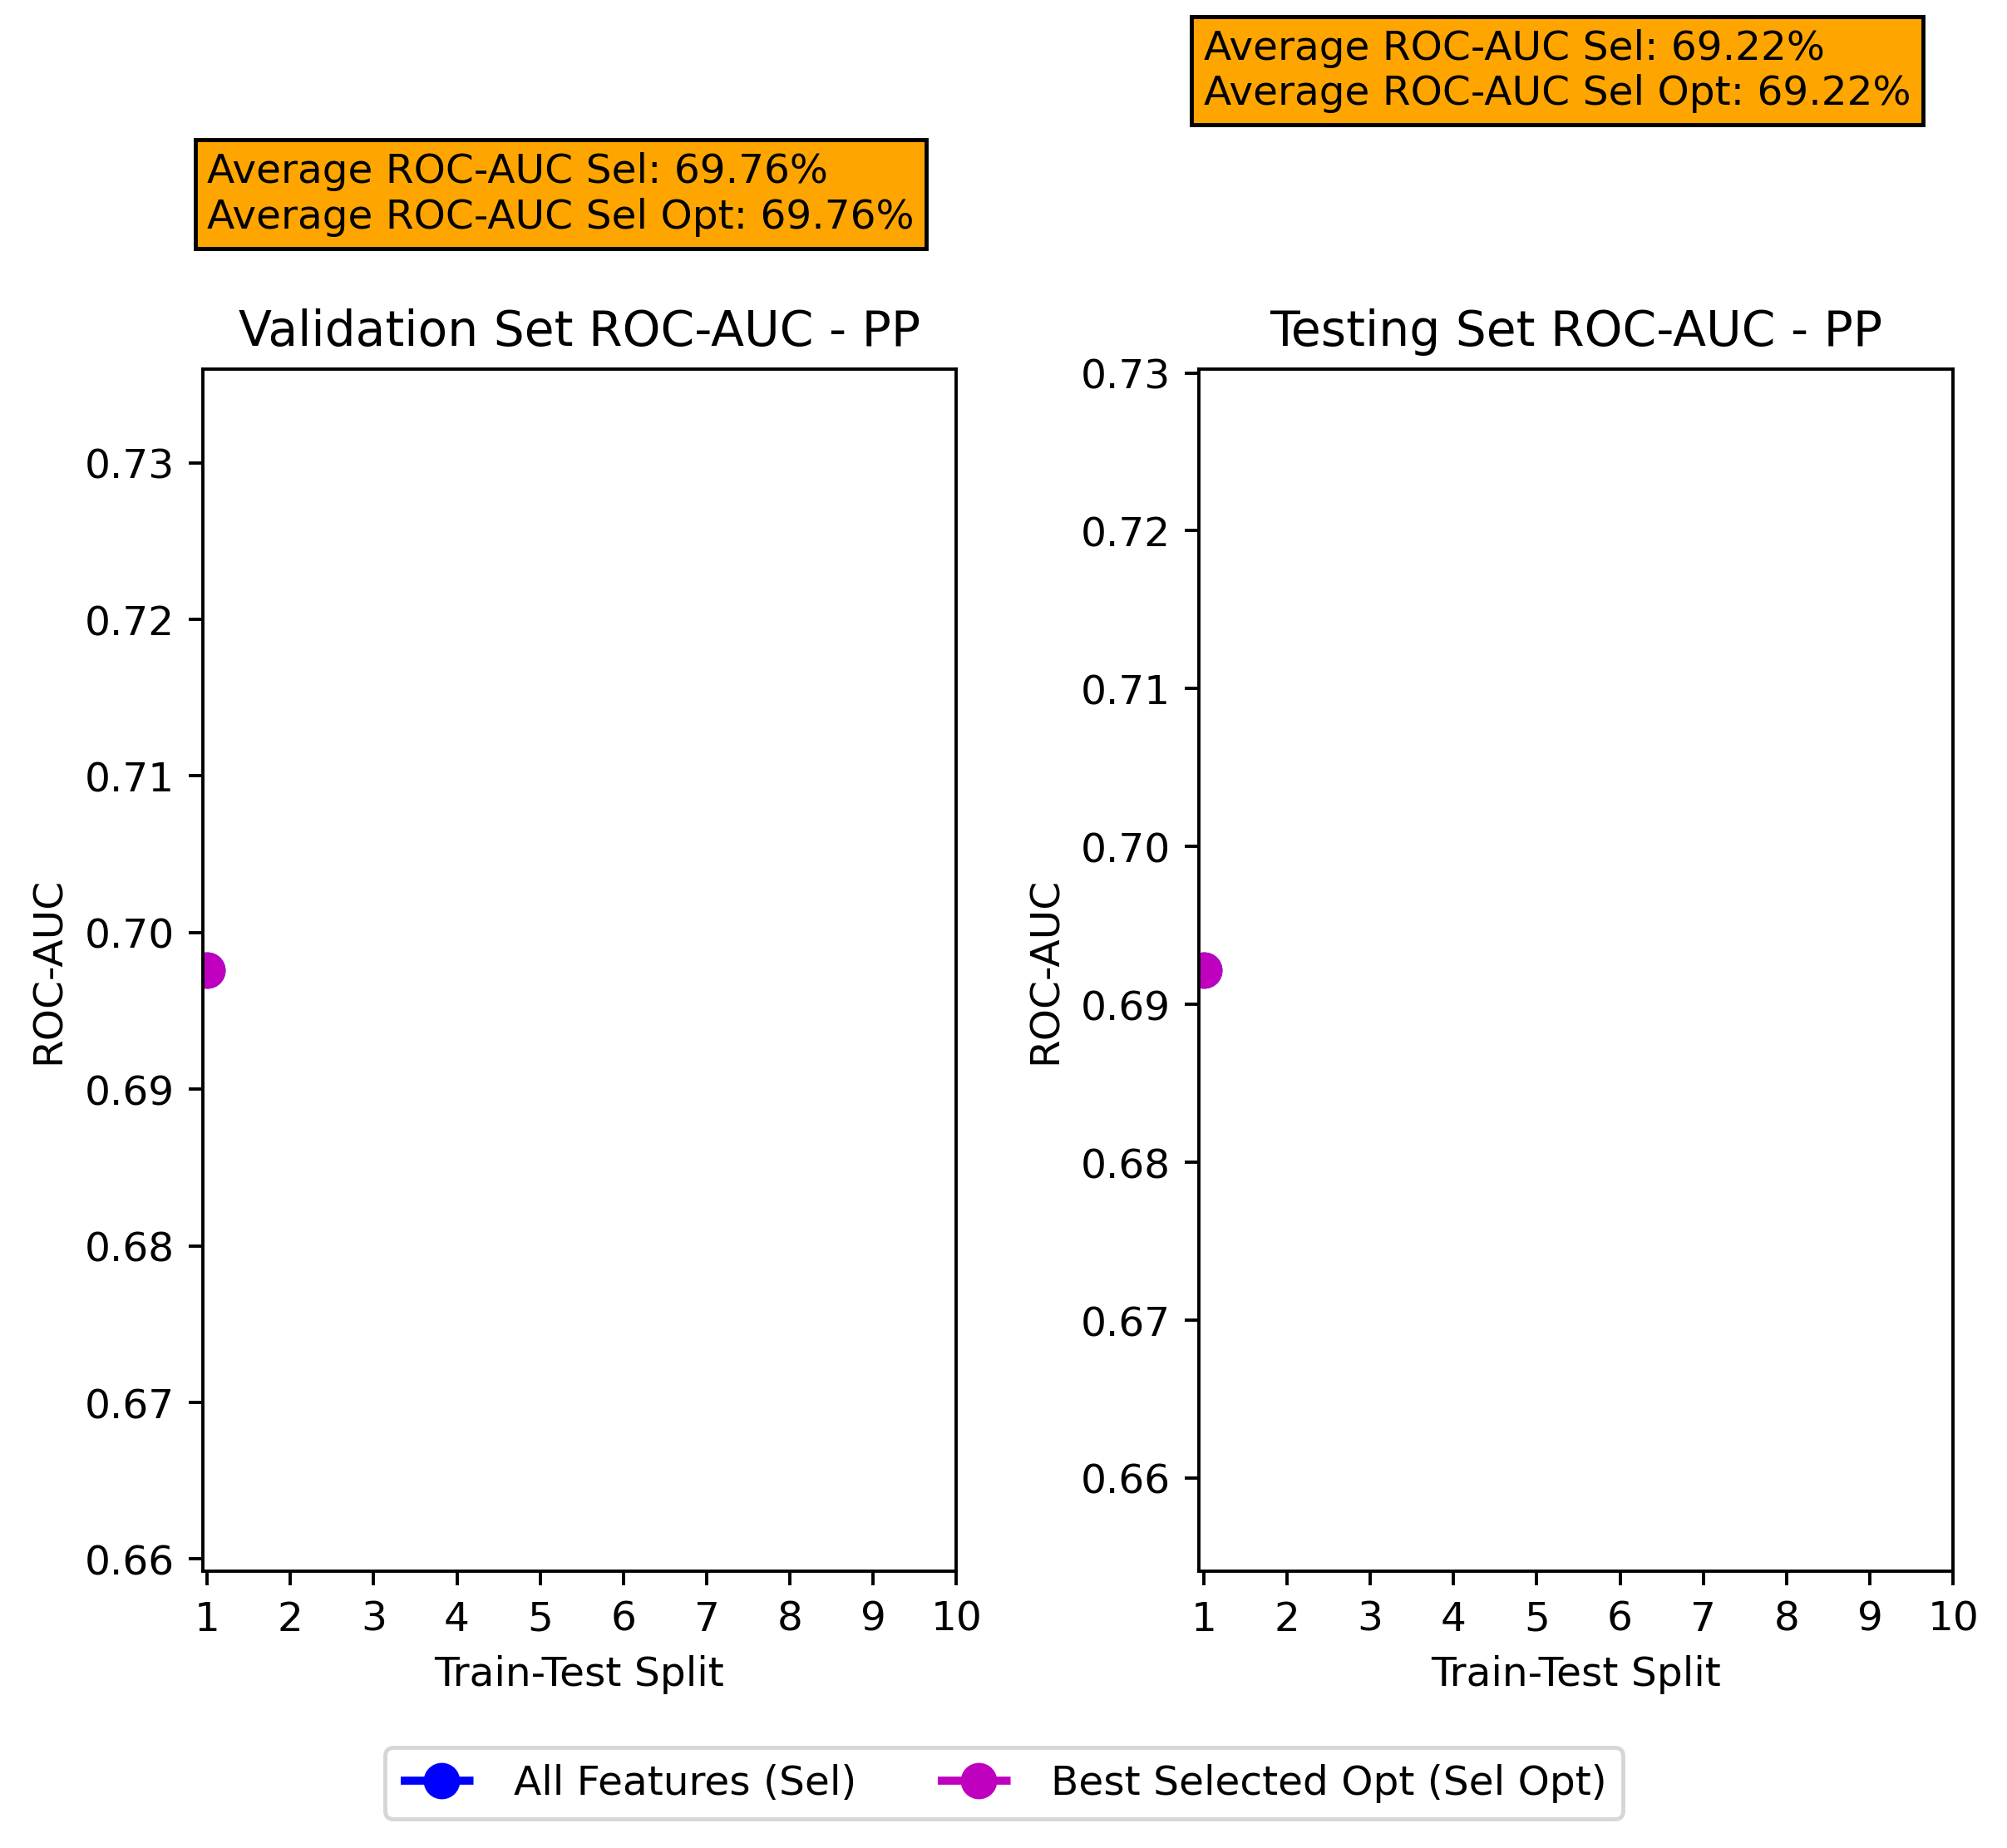

In [131]:
plt.figure(figsize=(7, 7), dpi=350)

# 1st Plot: Validation Set ROC-AUC
plt.subplot(1, 2, 1)
plt.plot(rf_val_roc_n_sel_kmer, 'b--', marker='o', markersize=8, linewidth=2)
plt.plot(rf_val_roc_n_sel_opt_kmer, 'm--', marker='o', markersize=8, linewidth=2)
plt.xlabel('Train-Test Split')
plt.ylabel('ROC-AUC')
plt.xticks(ticks=range(0, 10), labels=range(1, 11))
plt.title('Validation Set ROC-AUC - PP')
plt.text(
    0, 0.745,
    'Average ROC-AUC Sel: ' + str(np.round(np.average(rf_val_roc_n_sel_kmer) * 100, decimals=2)) + '%' +
    '\nAverage ROC-AUC Sel Opt: ' + str(np.round(np.average(rf_val_roc_n_sel_opt_kmer) * 100, decimals=2)) + '%',
    bbox=dict(boxstyle='square', fc='orange', ec='k')
)

# 2nd Plot: Testing Set ROC-AUC
plt.subplot(1, 2, 2)
plt.plot(rf_test_roc_n_sel_kmer, 'b--', marker='o', markersize=8, linewidth=2)
plt.plot(rf_test_roc_n_sel_opt_kmer, 'm--', marker='o', markersize=8, linewidth=2)
plt.xlabel('Train-Test Split')
plt.ylabel('ROC-AUC')
plt.xticks(ticks=range(0, 10), labels=range(1, 11))
plt.title('Testing Set ROC-AUC - PP')
plt.text(
    0, 0.747,
    'Average ROC-AUC Sel: ' + str(np.round(np.average(rf_test_roc_n_sel_kmer) * 100, decimals=2)) + '%' +
    '\nAverage ROC-AUC Sel Opt: ' + str(np.round(np.average(rf_test_roc_n_sel_opt_kmer) * 100, decimals=2)) + '%',
    bbox=dict(boxstyle='square', fc='orange', ec='k')
)

# Legend
plt.figlegend(
    ['All Features (Sel)', 'Best Selected Opt (Sel Opt)'],
    loc='lower center',
    bbox_to_anchor=(0.5, 0.0),
    ncol=2
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

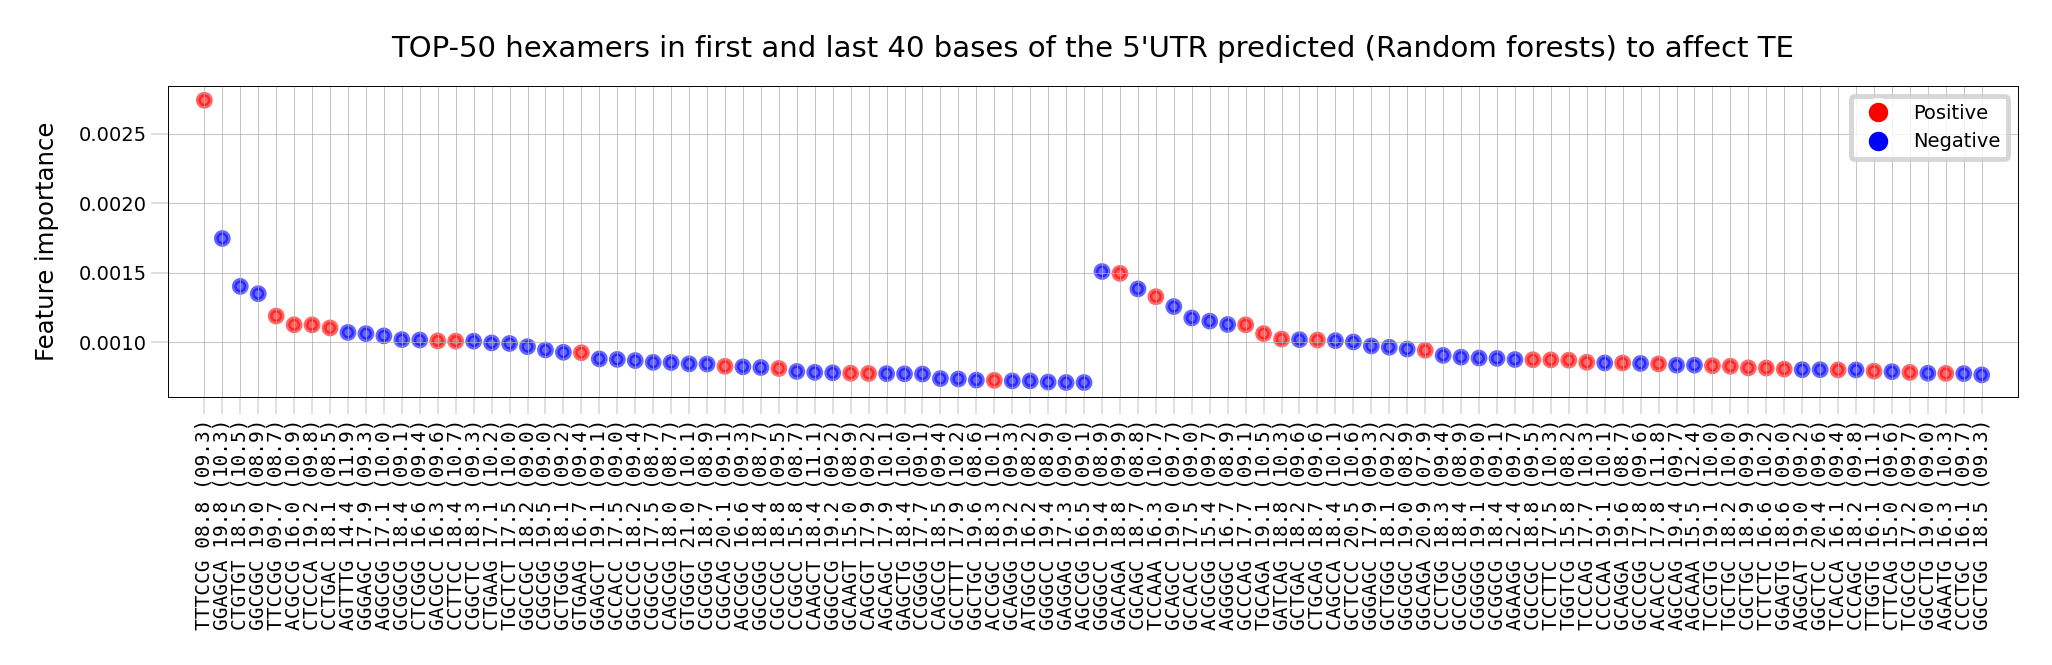

In [133]:
# Importance from model for last split
i=0

rf = eval(f'rf_5kmer_split{i}')
importances = rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

feature_names = list(eval(f'sel_feat_by_stats_5kmer_split{i}'))

forest_importances_5kmer = pd.Series(importances, index=feature_names).reset_index()
forest_importances_5kmer.columns = ['index', 'importance']
forest_importances_5kmer['kmer'] = forest_importances_5kmer['index'].apply(lambda x: x[:6])
kemrs_pos_5_1st['kmer'] = kemrs_pos_5_1st.index

# Merge kemrs_pos_5 positions with forest_importances_5kmer on 'kmer'
forest_importances_5kmer = forest_importances_5kmer.merge(kemrs_pos_5_1st, on='kmer', how='left')
forest_importances_5kmer.set_index('index', inplace=True)

# Filter rows where index has "_5_1st" or "_5_2nd"
forest_importances_5kmer_1st = forest_importances_5kmer.filter(like='_5_1st', axis=0)
forest_importances_5kmer_2nd = forest_importances_5kmer.filter(like='_5_2nd', axis=0)

# Now sort and get the top 50 entries for each
forest_importances_5kmer_1st = forest_importances_5kmer_1st.sort_values(by='importance', ascending=False).head(50)
forest_importances_5kmer_2nd = forest_importances_5kmer_2nd.sort_values(by='importance', ascending=False).head(50)

forest_importances_5kmer_TOP50 = pd.concat([forest_importances_5kmer_1st, forest_importances_5kmer_2nd], axis=0)

# Convert the DataFrame for plotting
df_5kmer = forest_importances_5kmer_TOP50.reset_index()
df_5kmer.columns = ['Feature', 'Importance', 'Kmer', 'Mean_Position', 'SE_Position']
df_5kmer['FC'] = eval(f'mannWhit_UpperVsLower_5kmer_split{i}').loc[df_5kmer['Feature'], 'FC'].values

# Modify the feature labels for the x-ticks
df_5kmer['Modified_Feature'] = df_5kmer.apply(
    lambda row: f"{row['Feature'].split('_')[0]} {format(row['Mean_Position'], '04.1f')} ({format(row['SE_Position'], '04.1f')})",
    axis=1
)

# Plotting
fig, ax = plt.subplots(dpi=350, figsize=(6, 2), tight_layout=True)

# Colors based on the condition
colors = np.where(df_5kmer['FC'] > 1, 'red', 'blue')  # 'red' for 'Positive', 'blue' for 'Negative'

# Scatter plot with custom colors
scatter = ax.scatter(df_5kmer.index, df_5kmer['Importance'], c=colors, s=6, alpha=0.6)

# Setting x-ticks and labels
ax.set_xticks(df_5kmer.index)
ax.set_xticklabels(df_5kmer['Modified_Feature'], fontsize=3, rotation=90, fontname='Monospace')

# Setting plot title and labels
ax.set_title("TOP-50 hexamers in first and last 40 bases of the 5'UTR predicted (Random forests) to affect TE", fontsize=6)
ax.set_ylabel("Feature importance", fontsize=5)
ax.tick_params(axis='both', labelsize=4, width=0.05, pad=1)
ax.grid(True, linestyle='-', linewidth=0.15)
ax.set_xlim(left=-2, right=len(df_5kmer) + 1)

# Thinner plot borders
for spine in ax.spines.values():
    spine.set_linewidth(0.2)

# Adding a legend
legend_labels = ['Positive' if fc > 1 else 'Negative' for fc in df_5kmer['FC']]
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Positive',
                          markerfacecolor='red', markersize=5),
                   Line2D([0], [0], marker='o', color='w', label='Negative',
                          markerfacecolor='blue', markersize=5)]
ax.legend(handles=legend_elements, fontsize=4)

plt.show()

In [49]:
df_5kmer_1st = df_5kmer[df_5kmer['Feature'].str.endswith('5_1st')]
df_5kmer_2nd = df_5kmer[df_5kmer['Feature'].str.endswith('5_2nd')]

# Define a function to get the top 5 scores for FC above and below 1
def get_top5(df):
    df_fc_above_1 = df[df['FC'] > 1].nlargest(5, 'Importance')
    df_fc_below_1 = df[df['FC'] < 1].nlargest(5, 'Importance')
    return pd.concat([df_fc_above_1, df_fc_below_1], axis=0)  # Concatenate along rows

# Concatenate the results for '1st' and '2nd' dataframes along columns
result = pd.concat([get_top5(df_5kmer_1st), get_top5(df_5kmer_2nd)], axis=0)
top_kmers_5 = list(result['Feature'])

# result = pd.concat([get_top5(df_5kmer_1st, 10)], axis=0)
# top_kmers_5_1st = list(result['Feature'])

In [46]:
df_5kmer_1st.to_csv('kmers/top50_kmers_5_1st.csv', index=False)
df_5kmer_2nd.to_csv('kmers/top50_kmers_5_2nd.csv', index=False)

### 3'UTR k-mer


In [108]:
# Getting the k-mers frequencies and location counts (normalized to length of the string) for the 3 and 5 prime strings
X_n_kemrs_3_1st = generate_kmers_byRange(X_3prime_s, frm = 0, to = 40, k_i=6, label='3_1st') # first 40
X_n_kemrs_3_2nd = generate_kmers_byRange(X_3prime_s, frm = 40, to = 80, k_i=6, label='3_2nd') # 2nd 40
X_n_kemrs_3_3rd = generate_kmers_byRange(X_3prime_s, frm = -80, to = -40, k_i=6, label='3_3rd') # 3rd 40
X_n_kemrs_3_4th = generate_kmers_byRange(X_3prime_s, frm = -40, to = None, k_i=6, label='3_4th') # 4th 40

X_n_kemrs_3utr = pd.concat([X_n_kemrs_3_1st, X_n_kemrs_3_2nd, X_n_kemrs_3_3rd, X_n_kemrs_3_4th], axis=1)

del X_n_kemrs_3_1st, X_n_kemrs_3_2nd, X_n_kemrs_3_3rd, X_n_kemrs_3_4th

Number of empty substrings: 0 out of 6262 total sequences
Number of empty substrings: 196 out of 6262 total sequences
Number of empty substrings: 196 out of 6262 total sequences
Number of empty substrings: 0 out of 6262 total sequences


In [109]:
# Getting kmers mean and SE positions 
kemrs_pos_3_1st = kmer_positions(X_3prime_s, frm = 0, to = 40, k_i=6) # 1st 40
kemrs_pos_3_2nd = kmer_positions(X_3prime_s, frm = 40, to = 80, k_i=6) # 2nd 40
kemrs_pos_3_3rd = kmer_positions(X_3prime_s, frm = -80, to = -40, k_i=6) # 3rd 40
kemrs_pos_3_4th = kmer_positions(X_3prime_s, frm = -40, to = None, k_i=6) # 4th 40

/var/folders/qq/l5jkdczn20l5krgkqd7kk3v00000gp/T/ipykernel_11180/3307172842.py:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  kmer_positions_stringency['mean_position'].replace({np.nan: None}, inplace=True)


In [139]:
# Defining lists to store metrics
rf_train_acc_n_ref_kmer = []
rf_train_roc_n_ref_kmer = []
rf_train_f1_n_ref_kmer = []
rf_test_acc_n_ref_kmer = []
rf_test_roc_n_ref_kmer = []
rf_test_f1_n_ref_kmer = []
rf_val_acc_n_ref_kmer = []
rf_val_roc_n_ref_kmer = []
rf_val_f1_n_ref_kmer = []

rf_train_acc_n_sel_kmer = []
rf_train_roc_n_sel_kmer = []
rf_train_f1_n_sel_kmer = []
rf_test_acc_n_sel_kmer = []
rf_test_roc_n_sel_kmer = []
rf_test_f1_n_sel_kmer = []
rf_val_acc_n_sel_kmer = []
rf_val_roc_n_sel_kmer = []
rf_val_f1_n_sel_kmer = []


rf_train_acc_n_sel_opt_kmer = []
rf_train_roc_n_sel_opt_kmer = []
rf_train_f1_n_sel_opt_kmer = []
rf_test_acc_n_sel_opt_kmer = []
rf_test_roc_n_sel_opt_kmer = []
rf_test_f1_n_sel_opt_kmer = []
rf_val_acc_n_sel_opt_kmer = []
rf_val_roc_n_sel_opt_kmer = []
rf_val_f1_n_sel_opt_kmer = []

model_hyper_param = []
fdr_and_stats_eq_n = []
corr_coeff_train = []
corr_coeff_test = []

for n_split in range(1): #range(N_SPLITS)
    
    # Spliting data set into train val and test sets
    #-----------------------------------------------
    rnd_seed = RANDOM_SEEDS[n_split]

    #kmers-total    
    X_n_kemrs_3prime_train, X_new, y_train, y_new = train_test_split(X_n_kemrs_3utr, y_categories, test_size=0.4 ,shuffle=True, stratify=y_categories, random_state=rnd_seed)
    X_n_kemrs_3prime_test, X_n_kemrs_3prime_val, y_test, y_val = train_test_split(X_new, y_new, test_size=0.5 ,shuffle=True, stratify=y_new, random_state=rnd_seed)

    X_n_kemrs_3prime_train, X_new, y_train_num, y_new_num = train_test_split(X_n_kemrs_3utr, y, test_size=0.4 ,shuffle=True, stratify=y_categories, random_state=rnd_seed)
    X_n_kemrs_3prime_test, X_n_kemrs_3prime_val, y_test_num, y_val_num = train_test_split(X_new, y_new_num, test_size=0.5 ,shuffle=True, stratify=y_new, random_state=rnd_seed)
    
    # Main input
    print(f'\nPreprocessing split #{n_split}...\n')
    X_train_n = X_n_kemrs_3prime_train

    X_val_n = X_n_kemrs_3prime_val

    X_test_n = X_n_kemrs_3prime_test
    

    feat_col = X_train_n.columns
    
    # Scaling the numerical features 
    X_train_n_scaled, X_val_n_scaled, X_test_n_scaled = scale_numerics(X_train_n, X_val_n, X_test_n, scaler_type='standard')
    
    # Imputting NaN
    imputer = KNNImputer(n_neighbors=4, weights="uniform")
    X_train_n_scaled = imputer.fit_transform(X_train_n_scaled)
    X_val_n_scaled = imputer.transform(X_val_n_scaled)
    X_test_n_scaled = imputer.transform(X_test_n_scaled)
    X_train_n = imputer.fit_transform(X_train_n)
    
    # 1)
    #-----------------------------------------------------    
    # Make reference ML model estimations on the numeric targets
    print(f"Initial evaluation for random split #{n_split}:\n")
    
    # Create an RF model
    rf = RandomForestClassifier(random_state=rnd_seed, n_jobs=-1) #class_weight='balanced', n_estimators=200, max_depth = None
    print("Reference Accuracies for Numerics")
    acc_train, acc_val, acc_test, roc_train, roc_val, roc_test, f1_train, f1_val, f1_test = acc_roc_f1_estimation(X_train=X_train_n_scaled, y_train=y_train,
                                                                                                                  X_val=X_val_n_scaled, y_val=y_val,
                                                                                                                  X_test=X_test_n_scaled, y_test=y_test,model=rf)
    
    rf_train_acc_n_ref_kmer.append(acc_train)
    rf_val_acc_n_ref_kmer.append(acc_val)
    rf_test_acc_n_ref_kmer.append(acc_test)
    rf_train_roc_n_ref_kmer.append(roc_train)
    rf_val_roc_n_ref_kmer.append(roc_val)
    rf_test_roc_n_ref_kmer.append(roc_test)
    rf_train_f1_n_ref_kmer.append(f1_train)
    rf_val_f1_n_ref_kmer.append(f1_val)
    rf_test_f1_n_ref_kmer.append(f1_test)
    #----------------------------------------------------- 
    # END 1)
    
    # 2)
    #----------------------------------------------------- 
    # Selecting numerical features with statistics
    X_train_n_scaled_sel, X_val_n_scaled_sel, X_test_n_scaled_sel, sel_feat_by_stats, sel_feat_by_stats_pval, mannWhit_UpperVsLower = feat_sel_by_stats(X_train_n, X_train_n_scaled,
    X_val_n_scaled,
    X_test_n_scaled,
    y_train, feat_col,
    5e-01)

    # # Selecting numerical features with model
    # X_train_n_scaled_sel, X_val_n_scaled_sel, X_test_n_scaled_sel, sel_feat_by_stats, selected_features_roc, sel_feat_by_stats_pval, mannWhit_UpperVsLower = feat_sel_model_num(X_train_n,
    #                                                                                                                                                                             X_train_n_scaled,
    #                                                                                                                                                                             X_val_n_scaled,
    #                                                                                                                                                                             X_test_n_scaled,
    #                                                                                                                                                                             y_train,
    #                                                                                                                                                                             y_val,
    #                                                                                                                                                                             feat_col,
    #                                                                                                                                                                             0.7)

    fdr_and_stats_eq = np.array_equal(fdrcorrection(sel_feat_by_stats_pval,
                                                        alpha=0.05,
                                                        method='indep',
                                                        is_sorted='False')[0], 
                                      (np.array(sel_feat_by_stats_pval) < 0.05))

    fdr_and_stats_eq_n.append(fdr_and_stats_eq)    
    
    print(f'Before feature selection we got {X_train_n_scaled.shape[1]} features')
    print(f'After feature selection by stat we got {X_train_n_scaled_sel.shape[1]} features')

    # Evaluation of selected numerical features with statistics
    rf = RandomForestClassifier(random_state=rnd_seed, n_jobs=-1) #class_weight='balanced', n_estimators=200, max_depth = None
    print()
    print("Accuracies for Numerics - Selected Features from statistics")
    acc_train, acc_val, acc_test, roc_train, roc_val, roc_test, f1_train, f1_val, f1_test = acc_roc_f1_estimation(X_train=X_train_n_scaled_sel,
                                                                                                                  y_train=y_train,
                                                                                                                  X_val=X_val_n_scaled_sel, y_val=y_val,
                                                                                                                  X_test=X_test_n_scaled_sel, y_test=y_test,
                                                                                                                  model=rf)
    rf_train_acc_n_sel_kmer.append(acc_train)
    rf_val_acc_n_sel_kmer.append(acc_val)
    rf_test_acc_n_sel_kmer.append(acc_test)
    rf_train_roc_n_sel_kmer.append(roc_train)
    rf_val_roc_n_sel_kmer.append(roc_val)
    rf_test_roc_n_sel_kmer.append(roc_test)
    rf_train_f1_n_sel_kmer.append(f1_train)
    rf_val_f1_n_sel_kmer.append(f1_val)
    rf_test_f1_n_sel_kmer.append(f1_test)

    # MHPT
    rf = RandomForestClassifier(random_state=rnd_seed, n_jobs=-1)
    
    n_est = hyperparameter_tunining(X_train=X_train_n_scaled_sel, 
                                    y_train=y_train, 
                                    model=rf)

    model_hyper_param.append([n_est])
    rf = RandomForestClassifier(n_estimators=n_est, random_state=rnd_seed, n_jobs=-1)
    acc_train, acc_val, acc_test, roc_train, roc_val, roc_test, f1_train, f1_val, f1_test = acc_roc_f1_estimation(X_train=X_train_n_scaled_sel,
                                                                                                                  y_train=y_train,
                                                                                                                  X_val=X_val_n_scaled_sel, y_val=y_val,
                                                                                                                  X_test=X_test_n_scaled_sel, y_test=y_test,
                                                                                                                  model=rf)


    rf_train_acc_n_sel_opt_kmer.append(acc_train)
    rf_val_acc_n_sel_opt_kmer.append(acc_val)
    rf_test_acc_n_sel_opt_kmer.append(acc_test)
    rf_train_roc_n_sel_opt_kmer.append(roc_train)
    rf_val_roc_n_sel_opt_kmer.append(roc_val)
    rf_test_roc_n_sel_opt_kmer.append(roc_test)
    rf_train_f1_n_sel_opt_kmer.append(f1_train)
    rf_val_f1_n_sel_opt_kmer.append(f1_val)
    rf_test_f1_n_sel_opt_kmer.append(f1_test)


    # # Regression
    # corr_coeff_train_, corr_coeff_test_ = xgb_reg(X_train_=X_train_n_scaled_sel, X_test_=X_test_n_scaled_sel,
    #                                               y_train_num=y_train_num, y_test_num=y_test_num)
    
    # corr_coeff_train.append(corr_coeff_train_)

    # corr_coeff_test.append(corr_coeff_test_)
    # # End Regression
    
    # saving rf model for each iteration
    globals()[f'rf_3kmer_split{n_split}'] = rf
    globals()[f'sel_feat_by_stats_3kmer_split{n_split}'] = sel_feat_by_stats
    globals()[f'sel_feat_by_stats_pval_3kmer_split{n_split}'] = sel_feat_by_stats_pval # when using feat_sel_by_stats()
    # globals()[f'selected_features_pval_3kmer_split{n_split}'] = selected_features_pval # when using feat_sel_model_num()
    globals()[f'mannWhit_UpperVsLower_3kmer_split{n_split}'] = mannWhit_UpperVsLower
    
    
    #----------------------------------------------------- 
    # END 2)
     
del X_n_kemrs_3prime_train, X_new, y_train, y_new, X_n_kemrs_3prime_test, X_n_kemrs_3prime_val, y_test, y_val
del X_train_n, X_val_n, X_test_n
del X_train_n_scaled, X_val_n_scaled, X_test_n_scaled 
del X_train_n_scaled_sel, X_val_n_scaled_sel, X_test_n_scaled_sel, sel_feat_by_stats, sel_feat_by_stats_pval, mannWhit_UpperVsLower


Preprocessing split #0...

Initial evaluation for random split #0:

Reference Accuracies for Numerics
Before feature selection we got 16384 features
After feature selection by stat we got 11231 features

Accuracies for Numerics - Selected Features from statistics


In [141]:
#Roc-AUC
print("Train Ref Roc n: ", np.average(rf_train_roc_n_ref_kmer))  
print("Val Ref Roc n: ", np.average(rf_val_roc_n_ref_kmer)) 
print("Test Ref Roc n: ", np.average(rf_test_roc_n_ref_kmer)) 
print('----------------------------------')
print("Train Sel Roc n: ", np.average(rf_train_roc_n_sel_kmer))   
print("Val Sel Roc n: ", np.average(rf_val_roc_n_sel_kmer))
print("Test Sel Roc n: ", np.average(rf_test_roc_n_sel_kmer)) 
print('----------------------------------')
print("Train Sel Opt Roc n: ", np.average(rf_train_roc_n_sel_opt_kmer))   
print("Val Sel Opt Roc n: ", np.average(rf_val_roc_n_sel_opt_kmer))
print("Test Sel Opt Roc n: ", np.average(rf_test_roc_n_sel_opt_kmer)) 

Train Ref Roc n:  0.9912754234322575
Val Ref Roc n:  0.7884078663125792
Test Ref Roc n:  0.7872660399378034
----------------------------------
Train Sel Roc n:  0.9913225588454869
Val Sel Roc n:  0.7963261007278636
Test Sel Roc n:  0.7886533835533008
----------------------------------
Train Sel Opt Roc n:  0.9915598582023595
Val Sel Opt Roc n:  0.7937840496969025
Test Sel Opt Roc n:  0.7917976604844389


In [ ]:
plt.figure(figsize=(7, 7), dpi=350)

# 1st Plot: Validation Set ROC-AUC
plt.subplot(1, 2, 1)
plt.plot(rf_val_roc_n_sel_kmer, 'b--', marker='o', markersize=8, linewidth=2)
plt.plot(rf_val_roc_n_sel_opt_kmer, 'm--', marker='o', markersize=8, linewidth=2)
plt.xlabel('Train-Test Split')
plt.ylabel('ROC-AUC')
plt.xticks(ticks=range(0, 10), labels=range(1, 11))
plt.title('Validation Set ROC-AUC - PP')
plt.text(
    0, 0.745,
    'Average ROC-AUC Sel: ' + str(np.round(np.average(rf_val_roc_n_sel_kmer) * 100, decimals=2)) + '%' +
    '\nAverage ROC-AUC Sel Opt: ' + str(np.round(np.average(rf_val_roc_n_sel_opt_kmer) * 100, decimals=2)) + '%',
    bbox=dict(boxstyle='square', fc='orange', ec='k')
)

# 2nd Plot: Testing Set ROC-AUC
plt.subplot(1, 2, 2)
plt.plot(rf_test_roc_n_sel_kmer, 'b--', marker='o', markersize=8, linewidth=2)
plt.plot(rf_test_roc_n_sel_opt_kmer, 'm--', marker='o', markersize=8, linewidth=2)
plt.xlabel('Train-Test Split')
plt.ylabel('ROC-AUC')
plt.xticks(ticks=range(0, 10), labels=range(1, 11))
plt.title('Testing Set ROC-AUC - PP')
plt.text(
    0, 0.747,
    'Average ROC-AUC Sel: ' + str(np.round(np.average(rf_test_roc_n_sel_kmer) * 100, decimals=2)) + '%' +
    '\nAverage ROC-AUC Sel Opt: ' + str(np.round(np.average(rf_test_roc_n_sel_opt_kmer) * 100, decimals=2)) + '%',
    bbox=dict(boxstyle='square', fc='orange', ec='k')
)

# Legend
plt.figlegend(
    ['All Features (Sel)', 'Best Selected Opt (Sel Opt)'],
    loc='lower center',
    bbox_to_anchor=(0.5, 0.0),
    ncol=2
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

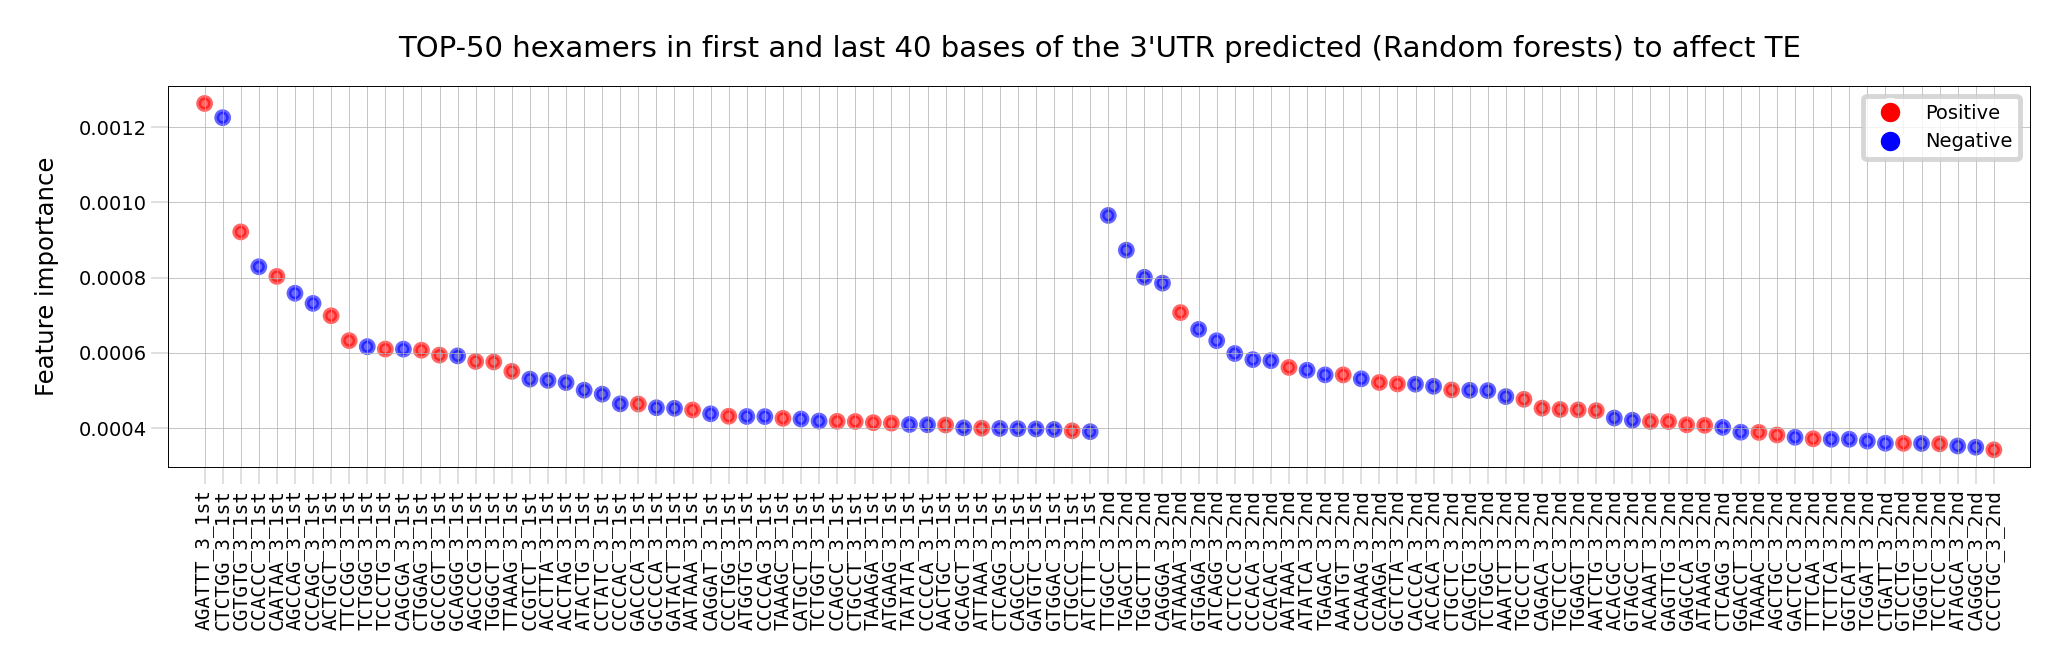

In [145]:
# Importance from model for last split
i=0

rf = eval(f'rf_3kmer_split{i}')
importances = rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

feature_names = list(eval(f'sel_feat_by_stats_3kmer_split{i}'))

forest_importances = pd.Series(importances, index=feature_names)

# # Split the series into two series: one ending with "_3" and the other ending with "_5"
# forest_importances_5 = forest_importances.filter(regex='_5$')
# forest_importances_5 = forest_importances_5.sort_values(ascending=False).head(50)

# forest_importancesTOP50 = forest_importances_5

forest_importances_3_1st = forest_importances.filter(regex='3_1st').squeeze()
forest_importances_3_2nd = forest_importances.filter(regex='3_2nd').squeeze()

# Now sort and get the top 50 entries for each
forest_importances_3_1st = forest_importances_3_1st.sort_values(ascending=False).head(50)
forest_importances_3_2nd = forest_importances_3_2nd.sort_values(ascending=False).head(50)

forest_importancesTOP50 = pd.concat([forest_importances_3_1st, forest_importances_3_2nd],axis=0)

# Convert the Series to DataFrame for plotting
df_3kmer = forest_importancesTOP50.reset_index()
df_3kmer.columns = ['Feature', 'Score']
df_3kmer['FC'] = eval(f'mannWhit_UpperVsLower_3kmer_split{i}').loc[df_3kmer['Feature'], 'FC'].values

# Plotting
fig, ax = plt.subplots(dpi=350, figsize=(6, 2), tight_layout=True)

# Colors based on the condition
colors = np.where(df_3kmer['FC'] > 1, 'red', 'blue')  # 'red' for 'Positive', 'blue' for 'Negative'

# Scatter plot with custom colors
scatter = ax.scatter(df_3kmer.index, df_3kmer['Score'], c=colors, s=6, alpha=0.6)

# Setting x-ticks and labels
ax.set_xticks(df_3kmer.index)
ax.set_xticklabels(df_3kmer['Feature'], fontsize=3, rotation=90, fontname='Monospace')

# Setting plot title and labels
ax.set_title("TOP-50 hexamers in first and last 40 bases of the 3'UTR predicted (Random forests) to affect TE", fontsize=6)
ax.set_ylabel("Feature importance", fontsize=5)
ax.tick_params(axis='both', labelsize=4, width=0.05, pad=1)
ax.grid(True, linestyle='-', linewidth=0.15)
ax.set_xlim(left=-2, right=len(df_3kmer) + 1)

# Thinner plot borders
for spine in ax.spines.values():
    spine.set_linewidth(0.2)

# Adding a legend
legend_labels = ['Positive' if fc > 1 else 'Negative' for fc in df_3kmer['FC']]
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Positive',
                          markerfacecolor='red', markersize=5),
                   Line2D([0], [0], marker='o', color='w', label='Negative',
                          markerfacecolor='blue', markersize=5)]
ax.legend(handles=legend_elements, fontsize=4)

plt.show()

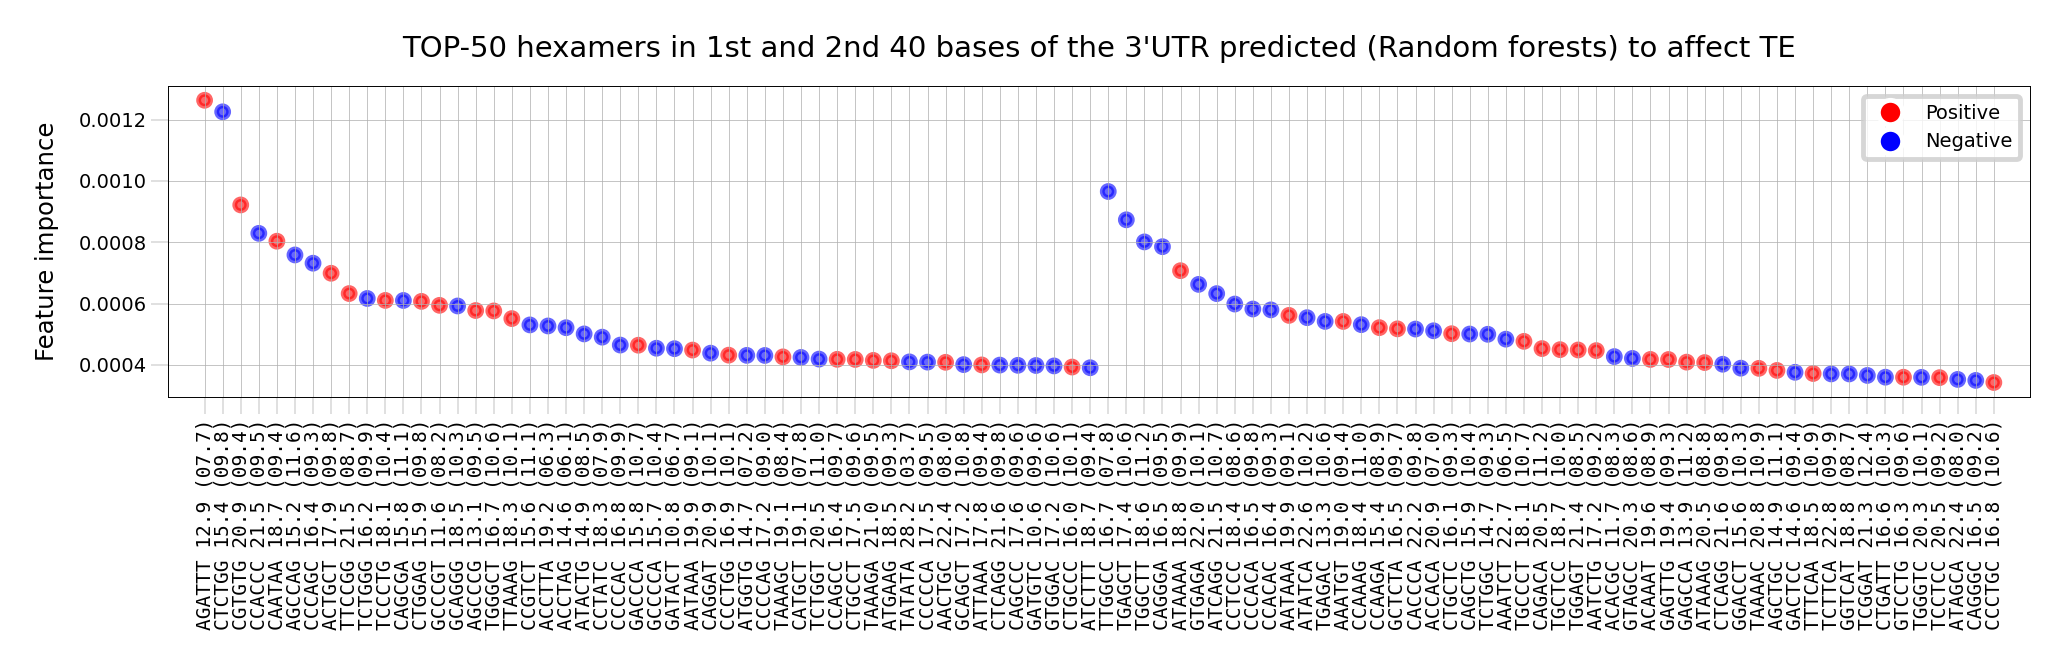

In [147]:
# Importance from model for last split
i=0

rf = eval(f'rf_3kmer_split{i}')
importances = rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

feature_names = list(eval(f'sel_feat_by_stats_3kmer_split{i}'))

forest_importances_3kmer = pd.Series(importances, index=feature_names).reset_index()
forest_importances_3kmer.columns = ['index', 'importance']
forest_importances_3kmer['kmer'] = forest_importances_3kmer['index'].apply(lambda x: x[:6])
kemrs_pos_3_1st['kmer'] = kemrs_pos_3_1st.index

# Merge kemrs_pos_3 positions with forest_importances_3kmer on 'kmer'
forest_importances_3kmer = forest_importances_3kmer.merge(kemrs_pos_3_1st, on='kmer', how='left')
forest_importances_3kmer.set_index('index', inplace=True)

# Filter rows where index has "_3_1st" or "_3_2nd"
forest_importances_3kmer_1st = forest_importances_3kmer.filter(like='_3_1st', axis=0)
forest_importances_3kmer_2nd = forest_importances_3kmer.filter(like='_3_2nd', axis=0)

# Now sort and get the top 50 entries for each
forest_importances_3kmer_1st = forest_importances_3kmer_1st.sort_values(by='importance', ascending=False).head(50)
forest_importances_3kmer_2nd = forest_importances_3kmer_2nd.sort_values(by='importance', ascending=False).head(50)

forest_importances_3kmer_TOP50 = pd.concat([forest_importances_3kmer_1st, forest_importances_3kmer_2nd], axis=0)

# Convert the DataFrame for plotting
df_3kmer = forest_importances_3kmer_TOP50.reset_index()
df_3kmer.columns = ['Feature', 'Importance', 'Kmer', 'Mean_Position', 'SE_Position']
df_3kmer['FC'] = eval(f'mannWhit_UpperVsLower_3kmer_split{i}').loc[df_3kmer['Feature'], 'FC'].values

# Modify the feature labels for the x-ticks
df_3kmer['Modified_Feature'] = df_3kmer.apply(
    lambda row: f"{row['Feature'].split('_')[0]} {format(row['Mean_Position'], '04.1f')} ({format(row['SE_Position'], '04.1f')})",
    axis=1
)

# Plotting
fig, ax = plt.subplots(dpi=350, figsize=(6, 2), tight_layout=True)

# Colors based on the condition
colors = np.where(df_3kmer['FC'] > 1, 'red', 'blue')  # 'red' for 'Positive', 'blue' for 'Negative'

# Scatter plot with custom colors
scatter = ax.scatter(df_3kmer.index, df_3kmer['Importance'], c=colors, s=6, alpha=0.6)

# Setting x-ticks and labels
ax.set_xticks(df_3kmer.index)
ax.set_xticklabels(df_3kmer['Modified_Feature'], fontsize=3, rotation=90, fontname='Monospace')

# Setting plot title and labels
ax.set_title("TOP-50 hexamers in 1st and 2nd 40 bases of the 3'UTR predicted (Random forests) to affect TE", fontsize=6)
ax.set_ylabel("Feature importance", fontsize=5)
ax.tick_params(axis='both', labelsize=4, width=0.05, pad=1)
ax.grid(True, linestyle='-', linewidth=0.15)
ax.set_xlim(left=-2, right=len(df_3kmer) + 1)

# Thinner plot borders
for spine in ax.spines.values():
    spine.set_linewidth(0.2)

# Adding a legend
legend_labels = ['Positive' if fc > 1 else 'Negative' for fc in df_3kmer['FC']]
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Positive',
                          markerfacecolor='red', markersize=5),
                   Line2D([0], [0], marker='o', color='w', label='Negative',
                          markerfacecolor='blue', markersize=5)]
ax.legend(handles=legend_elements, fontsize=4)
#plt.savefig('/Users/arielo/Desktop/utr_ai_desktop/plots/kmer_3utr_1st_2nd.pdf', dpi=350, bbox_inches='tight')
plt.show()

In [57]:
df_3kmer_1st = df_3kmer[df_3kmer['Feature'].str.endswith('3_1st')]
df_3kmer_2nd = df_3kmer[df_3kmer['Feature'].str.endswith('3_2nd')]

# Define a function to get the top 5 scores for FC above and below 1
def get_top5(df):
    df_fc_above_1 = df[df['FC'] > 1].nlargest(5, 'Importance')
    df_fc_below_1 = df[df['FC'] < 1].nlargest(5, 'Importance')
    return pd.concat([df_fc_above_1, df_fc_below_1], axis=0)  # Concatenate along rows

# Concatenate the results for '1st' and '2nd' dataframes along columns
result = pd.concat([get_top5(df_3kmer_1st), get_top5(df_3kmer_2nd)], axis=0)
top_kmers_3_1st2nd = list(result['Feature'])

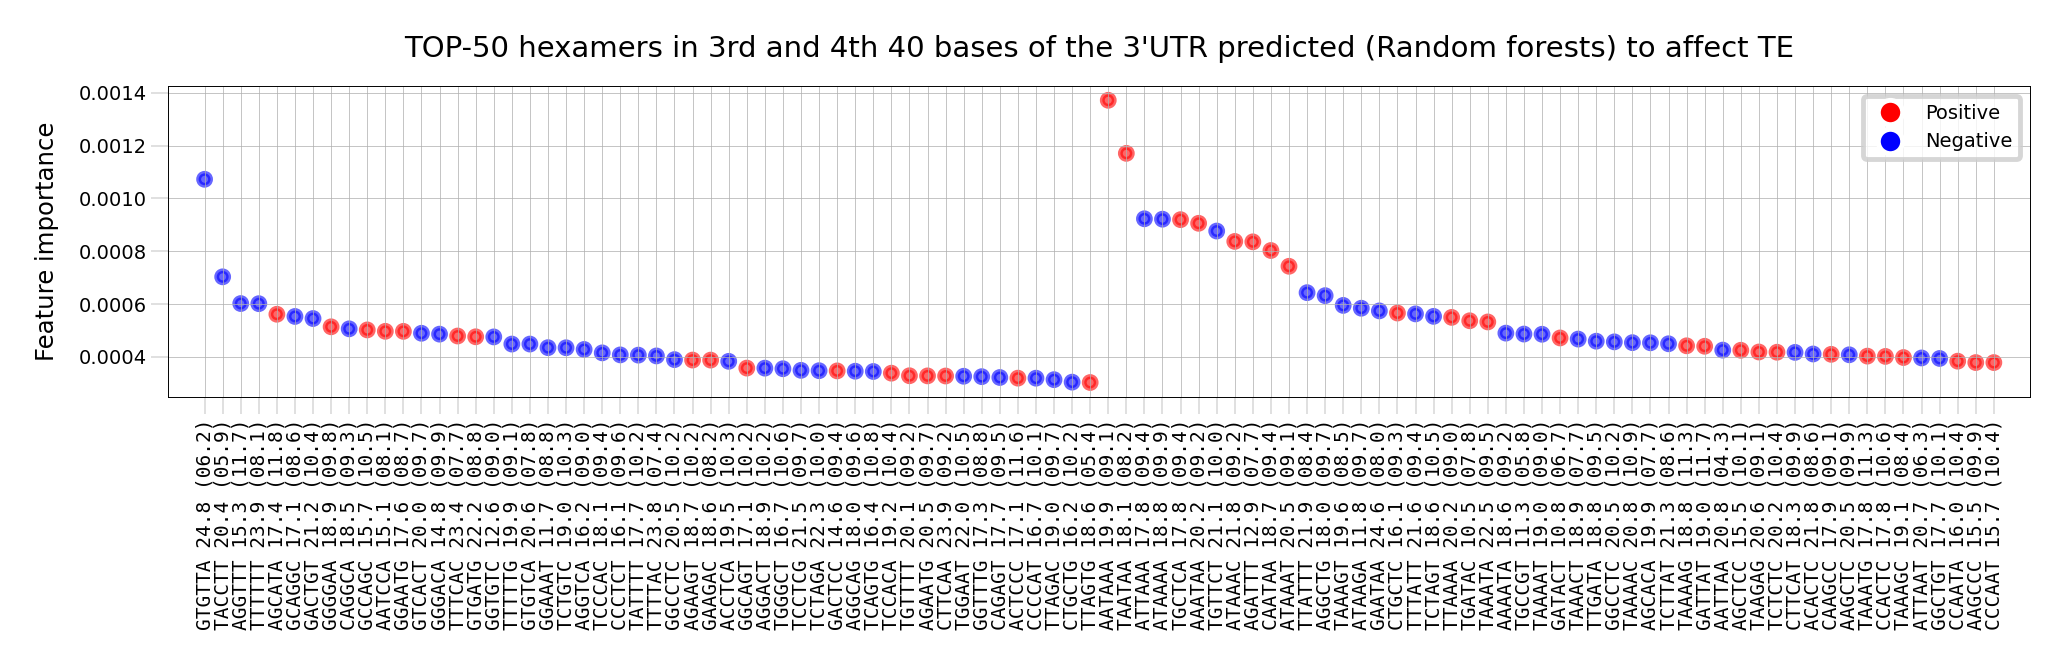

In [149]:
# Importance from model for last split
i=0

rf = eval(f'rf_3kmer_split{i}')
importances = rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

feature_names = list(eval(f'sel_feat_by_stats_3kmer_split{i}'))

forest_importances_3kmer = pd.Series(importances, index=feature_names).reset_index()
forest_importances_3kmer.columns = ['index', 'importance']
forest_importances_3kmer['kmer'] = forest_importances_3kmer['index'].apply(lambda x: x[:6])
kemrs_pos_3_1st['kmer'] = kemrs_pos_3_1st.index

# Merge kemrs_pos_3 positions with forest_importances_3kmer on 'kmer'
forest_importances_3kmer = forest_importances_3kmer.merge(kemrs_pos_3_1st, on='kmer', how='left')
forest_importances_3kmer.set_index('index', inplace=True)

# Filter rows where index has "_3_1st" or "_3_2nd"
forest_importances_3kmer_1st = forest_importances_3kmer.filter(like='_3_3rd', axis=0)
forest_importances_3kmer_2nd = forest_importances_3kmer.filter(like='_3_4th', axis=0)

# Now sort and get the top 50 entries for each
forest_importances_3kmer_1st = forest_importances_3kmer_1st.sort_values(by='importance', ascending=False).head(50)
forest_importances_3kmer_2nd = forest_importances_3kmer_2nd.sort_values(by='importance', ascending=False).head(50)

forest_importances_3kmer_TOP50 = pd.concat([forest_importances_3kmer_1st, forest_importances_3kmer_2nd], axis=0)

# Convert the DataFrame for plotting
df_3kmer = forest_importances_3kmer_TOP50.reset_index()
df_3kmer.columns = ['Feature', 'Importance', 'Kmer', 'Mean_Position', 'SE_Position']
df_3kmer['FC'] = eval(f'mannWhit_UpperVsLower_3kmer_split{i}').loc[df_3kmer['Feature'], 'FC'].values

# Modify the feature labels for the x-ticks
df_3kmer['Modified_Feature'] = df_3kmer.apply(
    lambda row: f"{row['Feature'].split('_')[0]} {format(row['Mean_Position'], '04.1f')} ({format(row['SE_Position'], '04.1f')})",
    axis=1
)

# Plotting
fig, ax = plt.subplots(dpi=350, figsize=(6, 2), tight_layout=True)

# Colors based on the condition
colors = np.where(df_3kmer['FC'] > 1, 'red', 'blue')  # 'red' for 'Positive', 'blue' for 'Negative'

# Scatter plot with custom colors
scatter = ax.scatter(df_3kmer.index, df_3kmer['Importance'], c=colors, s=6, alpha=0.6)

# Setting x-ticks and labels
ax.set_xticks(df_3kmer.index)
ax.set_xticklabels(df_3kmer['Modified_Feature'], fontsize=3, rotation=90, fontname='Monospace')

# Setting plot title and labels
ax.set_title("TOP-50 hexamers in 3rd and 4th 40 bases of the 3'UTR predicted (Random forests) to affect TE", fontsize=6)
ax.set_ylabel("Feature importance", fontsize=5)
ax.tick_params(axis='both', labelsize=4, width=0.05, pad=1)
ax.grid(True, linestyle='-', linewidth=0.15)
ax.set_xlim(left=-2, right=len(df_3kmer) + 1)

# Thinner plot borders
for spine in ax.spines.values():
    spine.set_linewidth(0.2)

# Adding a legend
legend_labels = ['Positive' if fc > 1 else 'Negative' for fc in df_3kmer['FC']]
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Positive',
                          markerfacecolor='red', markersize=5),
                   Line2D([0], [0], marker='o', color='w', label='Negative',
                          markerfacecolor='blue', markersize=5)]
ax.legend(handles=legend_elements, fontsize=4)
#plt.savefig('/Users/arielo/Desktop/utr_ai_desktop/plots/kmer_3utr_3rd_4th.pdf', dpi=650, bbox_inches='tight')
plt.show()

In [57]:
df_3kmer_3rd = df_3kmer[df_3kmer['Feature'].str.endswith('3_3rd')]
df_3kmer_4th = df_3kmer[df_3kmer['Feature'].str.endswith('3_4th')]

# Define a function to get the top 5 scores for FC above and below 1
def get_top5(df):
    df_fc_above_1 = df[df['FC'] > 1].nlargest(5, 'Importance')
    df_fc_below_1 = df[df['FC'] < 1].nlargest(5, 'Importance')
    return pd.concat([df_fc_above_1, df_fc_below_1], axis=0)  # Concatenate along rows

# Concatenate the results for '1st' and '2nd' dataframes along columns
result = pd.concat([get_top5(df_3kmer_3rd), get_top5(df_3kmer_4th)], axis=0)
top_kmers_3_3rd4th = list(result['Feature'])

# result = pd.concat([get_top5(df_3kmer_4th,10)], axis=0)
# top_kmers_3_4th = list(result['Feature'])

In [58]:
df_3kmer_1st.to_csv('kmers/top50_kmers_3_1st.csv', index=False)
df_3kmer_2nd.to_csv('kmers/top50_kmers_3_2nd.csv', index=False)
df_3kmer_3rd.to_csv('kmers/top50_kmers_3_3rd.csv', index=False)
df_3kmer_4th.to_csv('kmers/top50_kmers_3_4th.csv', index=False)

In [46]:
import pandas as pd

file_names = ['1st', '2nd', '3rd', '4th']
dfs = {}

for name in file_names:
    dfs[name] = pd.read_csv(f'kmers/top50_kmers_3_{name}.csv')

# Access the DataFrames as needed, for example:
df_3kmer_1st = dfs['1st']
df_3kmer_2nd = dfs['2nd']
df_3kmer_3rd = dfs['3rd']
df_3kmer_4th = dfs['4th']


### 5'UTR & 3'UTR


In [159]:
# Defining lists to store metrics
rf_train_acc_n_ref_kmer = []
rf_train_roc_n_ref_kmer = []
rf_train_f1_n_ref_kmer = []
rf_test_acc_n_ref_kmer = []
rf_test_roc_n_ref_kmer = []
rf_test_f1_n_ref_kmer = []
rf_val_acc_n_ref_kmer = []
rf_val_roc_n_ref_kmer = []
rf_val_f1_n_ref_kmer = []

rf_train_acc_n_sel_kmer = []
rf_train_roc_n_sel_kmer = []
rf_train_f1_n_sel_kmer = []
rf_test_acc_n_sel_kmer = []
rf_test_roc_n_sel_kmer = []
rf_test_f1_n_sel_kmer = []
rf_val_acc_n_sel_kmer = []
rf_val_roc_n_sel_kmer = []
rf_val_f1_n_sel_kmer = []

rf_train_acc_n_sel_opt_kmer = []
rf_train_roc_n_sel_opt_kmer = []
rf_train_f1_n_sel_opt_kmer = []
rf_test_acc_n_sel_opt_kmer = []
rf_test_roc_n_sel_opt_kmer = []
rf_test_f1_n_sel_opt_kmer = []
rf_val_acc_n_sel_opt_kmer = []
rf_val_roc_n_sel_opt_kmer = []
rf_val_f1_n_sel_opt_kmer = []

model_hyper_param = []
fdr_and_stats_eq_n = []
corr_coeff_train = []
corr_coeff_test = []

for n_split in [0]: #range(N_SPLITS) 
    
    # Spliting data set into train val and test sets
    #-----------------------------------------------
    rnd_seed = RANDOM_SEEDS[n_split]

    X_n_kemrs_5_3_utr = pd.concat((X_n_kemrs_5utr,X_n_kemrs_3utr), axis=1)

    #kmers-total    
    X_n_kemrs_5_3_prime_train, X_new, y_train, y_new = train_test_split(X_n_kemrs_5_3_utr, y_categories, test_size=0.4 ,shuffle=True, stratify=y_categories, random_state=rnd_seed)
    X_n_kemrs_5_3_prime_test, X_n_kemrs_5_3_prime_val, y_test, y_val = train_test_split(X_new, y_new, test_size=0.5 ,shuffle=True, stratify=y_new, random_state=rnd_seed)

    X_n_kemrs_5_3_prime_train, X_new, y_train_num, y_new_num = train_test_split(X_n_kemrs_5_3_utr, y, test_size=0.4 ,shuffle=True, stratify=y_categories, random_state=rnd_seed)
    X_n_kemrs_5_3_prime_test, X_n_kemrs_5_3_prime_val, y_test_num, y_val_num = train_test_split(X_new, y_new_num, test_size=0.5 ,shuffle=True, stratify=y_new, random_state=rnd_seed)
    
    # Main input
    print(f'\nPreprocessing split #{n_split}...\n')
    X_train_n = X_n_kemrs_5_3_prime_train

    X_val_n = X_n_kemrs_5_3_prime_val

    X_test_n = X_n_kemrs_5_3_prime_test

    feat_col = X_train_n.columns
    
    # Scaling the numerical features 
    X_train_n_scaled, X_val_n_scaled, X_test_n_scaled = scale_numerics(X_train_n, X_val_n, X_test_n, scaler_type='standard')
    
    # Imputting NaN
    imputer = KNNImputer(n_neighbors=4, weights="uniform")
    X_train_n_scaled = imputer.fit_transform(X_train_n_scaled)
    X_val_n_scaled = imputer.transform(X_val_n_scaled)
    X_test_n_scaled = imputer.transform(X_test_n_scaled)
    X_train_n = imputer.fit_transform(X_train_n)
    
    # 1)
    #-----------------------------------------------------    
    # Make reference ML model estimations on the numeric targets
    print(f"Initial evaluation for random split #{n_split}:\n")
    
    # Create an RF model
    rf = RandomForestClassifier(random_state=rnd_seed, n_jobs=-1) #class_weight='balanced', n_estimators=200, max_depth = None
    print("Reference Accuracies for Numerics")
    acc_train, acc_val, acc_test, roc_train, roc_val, roc_test, f1_train, f1_val, f1_test = acc_roc_f1_estimation(X_train=X_train_n_scaled, y_train=y_train,
                                                                                                                  X_val=X_val_n_scaled, y_val=y_val,
                                                                                                                  X_test=X_test_n_scaled, y_test=y_test,model=rf)
    
    rf_train_acc_n_ref_kmer.append(acc_train)
    rf_val_acc_n_ref_kmer.append(acc_val)
    rf_test_acc_n_ref_kmer.append(acc_test)
    rf_train_roc_n_ref_kmer.append(roc_train)
    rf_val_roc_n_ref_kmer.append(roc_val)
    rf_test_roc_n_ref_kmer.append(roc_test)
    rf_train_f1_n_ref_kmer.append(f1_train)
    rf_val_f1_n_ref_kmer.append(f1_val)
    rf_test_f1_n_ref_kmer.append(f1_test)
    #----------------------------------------------------- 
    # END 1)
    
    # 2)
    #----------------------------------------------------- 
    # Selecting numerical features with statistics
    X_train_n_scaled_sel, X_val_n_scaled_sel, X_test_n_scaled_sel, sel_feat_by_stats, sel_feat_by_stats_pval, mannWhit_UpperVsLower = feat_sel_by_stats(X_train_n, X_train_n_scaled,
    X_val_n_scaled,
    X_test_n_scaled,
    y_train, feat_col,
    5e-01)
    
    fdr_and_stats_eq = np.array_equal(fdrcorrection(sel_feat_by_stats_pval,
                                                        alpha=0.05,
                                                        method='indep',
                                                        is_sorted='False')[0], 
                                      (np.array(sel_feat_by_stats_pval) < 0.05))

    fdr_and_stats_eq_n.append(fdr_and_stats_eq)
    
    print(f'Before feature selection we got {X_train_n_scaled.shape[1]} features')
    print(f'After feature selection by stat we got {X_train_n_scaled_sel.shape[1]} features')

    # Evaluation of selected numerical features with statistics
    rf = RandomForestClassifier(random_state=rnd_seed) #, n_jobs=-1, class_weight='balanced', n_estimators=200, max_depth = None
    print()
    print("Accuracies for Numerics - Selected Features from statistics")
    acc_train, acc_val, acc_test, roc_train, roc_val, roc_test, f1_train, f1_val, f1_test = acc_roc_f1_estimation(X_train=X_train_n_scaled_sel,
                                                                                                                  y_train=y_train,
                                                                                                                  X_val=X_val_n_scaled_sel, y_val=y_val,
                                                                                                                  X_test=X_test_n_scaled_sel, y_test=y_test,
                                                                                                                  model=rf)
    rf_train_acc_n_sel_kmer.append(acc_train)
    rf_val_acc_n_sel_kmer.append(acc_val)
    rf_test_acc_n_sel_kmer.append(acc_test)
    rf_train_roc_n_sel_kmer.append(roc_train)
    rf_val_roc_n_sel_kmer.append(roc_val)
    rf_test_roc_n_sel_kmer.append(roc_test)
    rf_train_f1_n_sel_kmer.append(f1_train)
    rf_val_f1_n_sel_kmer.append(f1_val)
    rf_test_f1_n_sel_kmer.append(f1_test)

    # MHPT
    rf = RandomForestClassifier(random_state=rnd_seed) #, n_jobs=-1
    
    n_est = hyperparameter_tunining(X_train=X_train_n_scaled_sel, 
                                    y_train=y_train, 
                                    model=rf)

    model_hyper_param.append([n_est])
    rf = RandomForestClassifier(n_estimators=n_est, random_state=rnd_seed) #, n_jobs=-1
    acc_train, acc_val, acc_test, roc_train, roc_val, roc_test, f1_train, f1_val, f1_test = acc_roc_f1_estimation(X_train=X_train_n_scaled_sel,
                                                                                                                  y_train=y_train,
                                                                                                                  X_val=X_val_n_scaled_sel, y_val=y_val,
                                                                                                                  X_test=X_test_n_scaled_sel, y_test=y_test,
                                                                                                                  model=rf)


    rf_train_acc_n_sel_opt_kmer.append(acc_train)
    rf_val_acc_n_sel_opt_kmer.append(acc_val)
    rf_test_acc_n_sel_opt_kmer.append(acc_test)
    rf_train_roc_n_sel_opt_kmer.append(roc_train)
    rf_val_roc_n_sel_opt_kmer.append(roc_val)
    rf_test_roc_n_sel_opt_kmer.append(roc_test)
    rf_train_f1_n_sel_opt_kmer.append(f1_train)
    rf_val_f1_n_sel_opt_kmer.append(f1_val)
    rf_test_f1_n_sel_opt_kmer.append(f1_test)


    # # Regression
    # y_train_num_scaled, y_train_num_pred, y_test_num_scaled, y_test_num_pred, corr_coeff_train_, corr_coeff_test_ = xgb_reg(X_train_=X_train_n_scaled_sel,
    #                                                                                                                         X_test_=X_test_n_scaled_sel,
    #                                                                                                                         y_train_num=y_train_num,
    #                                                                                                                         y_test_num=y_test_num)
    
    # #corr_coeff_train_, corr_coeff_test_ = xgb_reg(X_train_=X_train_n_scaled_sel, X_test_=X_test_n_scaled_sel,
    # #                                             y_train_num=y_train_num, y_test_num=y_test_num)
    
    # corr_coeff_train.append(corr_coeff_train_)

    # corr_coeff_test.append(corr_coeff_test_)
    # # End Regression
    
    # saving rf model for each iteration
    globals()[f'rf_5_3_kmer_split{n_split}'] = rf
    globals()[f'sel_feat_by_stats_5_3_kmer_split{n_split}'] = sel_feat_by_stats
    globals()[f'sel_feat_by_stats_pval_5_3_kmer_split{n_split}'] = sel_feat_by_stats_pval
    globals()[f'mannWhit_UpperVsLower_5_3_kmer_split{n_split}'] = mannWhit_UpperVsLower
    
    # globals()[f'y_train_num_scaled_split{n_split}'] = y_train_num_scaled
    # globals()[f'y_train_num_pred_split{n_split}'] = y_train_num_pred
    # globals()[f'y_test_num_scaled_split{n_split}'] = y_test_num_scaled
    # globals()[f'y_test_num_pred_split{n_split}'] = y_test_num_pred
    # globals()[f'corr_coeff_train__split{n_split}'] = corr_coeff_train_
    # globals()[f'corr_coeff_test___split{n_split}'] = corr_coeff_test_
    
    #----------------------------------------------------- 
    # END 2)
     
# del X_n_kemrs_5_3_prime_train, X_new, y_train, y_new, X_n_kemrs_5_3_prime_test, X_n_kemrs_5_3_prime_val, y_test, y_val
# del X_train_n, X_val_n, X_test_n
# del X_train_n_scaled, X_val_n_scaled, X_test_n_scaled
# del X_train_n_scaled_sel, X_val_n_scaled_sel, X_test_n_scaled_sel, sel_feat_by_stats, sel_feat_by_stats_pval, mannWhit_UpperVsLower


Preprocessing split #0...

Initial evaluation for random split #0:

Reference Accuracies for Numerics
Before feature selection we got 24576 features
After feature selection by stat we got 16267 features

Accuracies for Numerics - Selected Features from statistics


In [162]:
#Roc-AUC
print("Train Ref Roc n: ", np.average(rf_train_roc_n_ref_kmer))  
print("Val Ref Roc n: ", np.average(rf_val_roc_n_ref_kmer)) 
print("Test Ref Roc n: ", np.average(rf_test_roc_n_ref_kmer)) 
print('----------------------------------')
print("Train Sel Roc n: ", np.average(rf_train_roc_n_sel_kmer))   
print("Val Sel Roc n: ", np.average(rf_val_roc_n_sel_kmer))
print("Test Sel Roc n: ", np.average(rf_test_roc_n_sel_kmer)) 
print('----------------------------------')
print("Train Sel Opt Roc n: ", np.average(rf_train_roc_n_sel_opt_kmer))   
print("Val Sel Opt Roc n: ", np.average(rf_val_roc_n_sel_opt_kmer))
print("Test Sel Opt Roc n: ", np.average(rf_test_roc_n_sel_opt_kmer)) 

Train Ref Roc n:  0.9999092932864428
Val Ref Roc n:  0.7992358492598258
Test Ref Roc n:  0.7933466198491358
----------------------------------
Train Sel Roc n:  0.9999113730561158
Val Sel Roc n:  0.7971819585180536
Test Sel Roc n:  0.7927805394223343
----------------------------------
Train Sel Opt Roc n:  0.9999113730561158
Val Sel Opt Roc n:  0.7971819585180536
Test Sel Opt Roc n:  0.7927805394223343


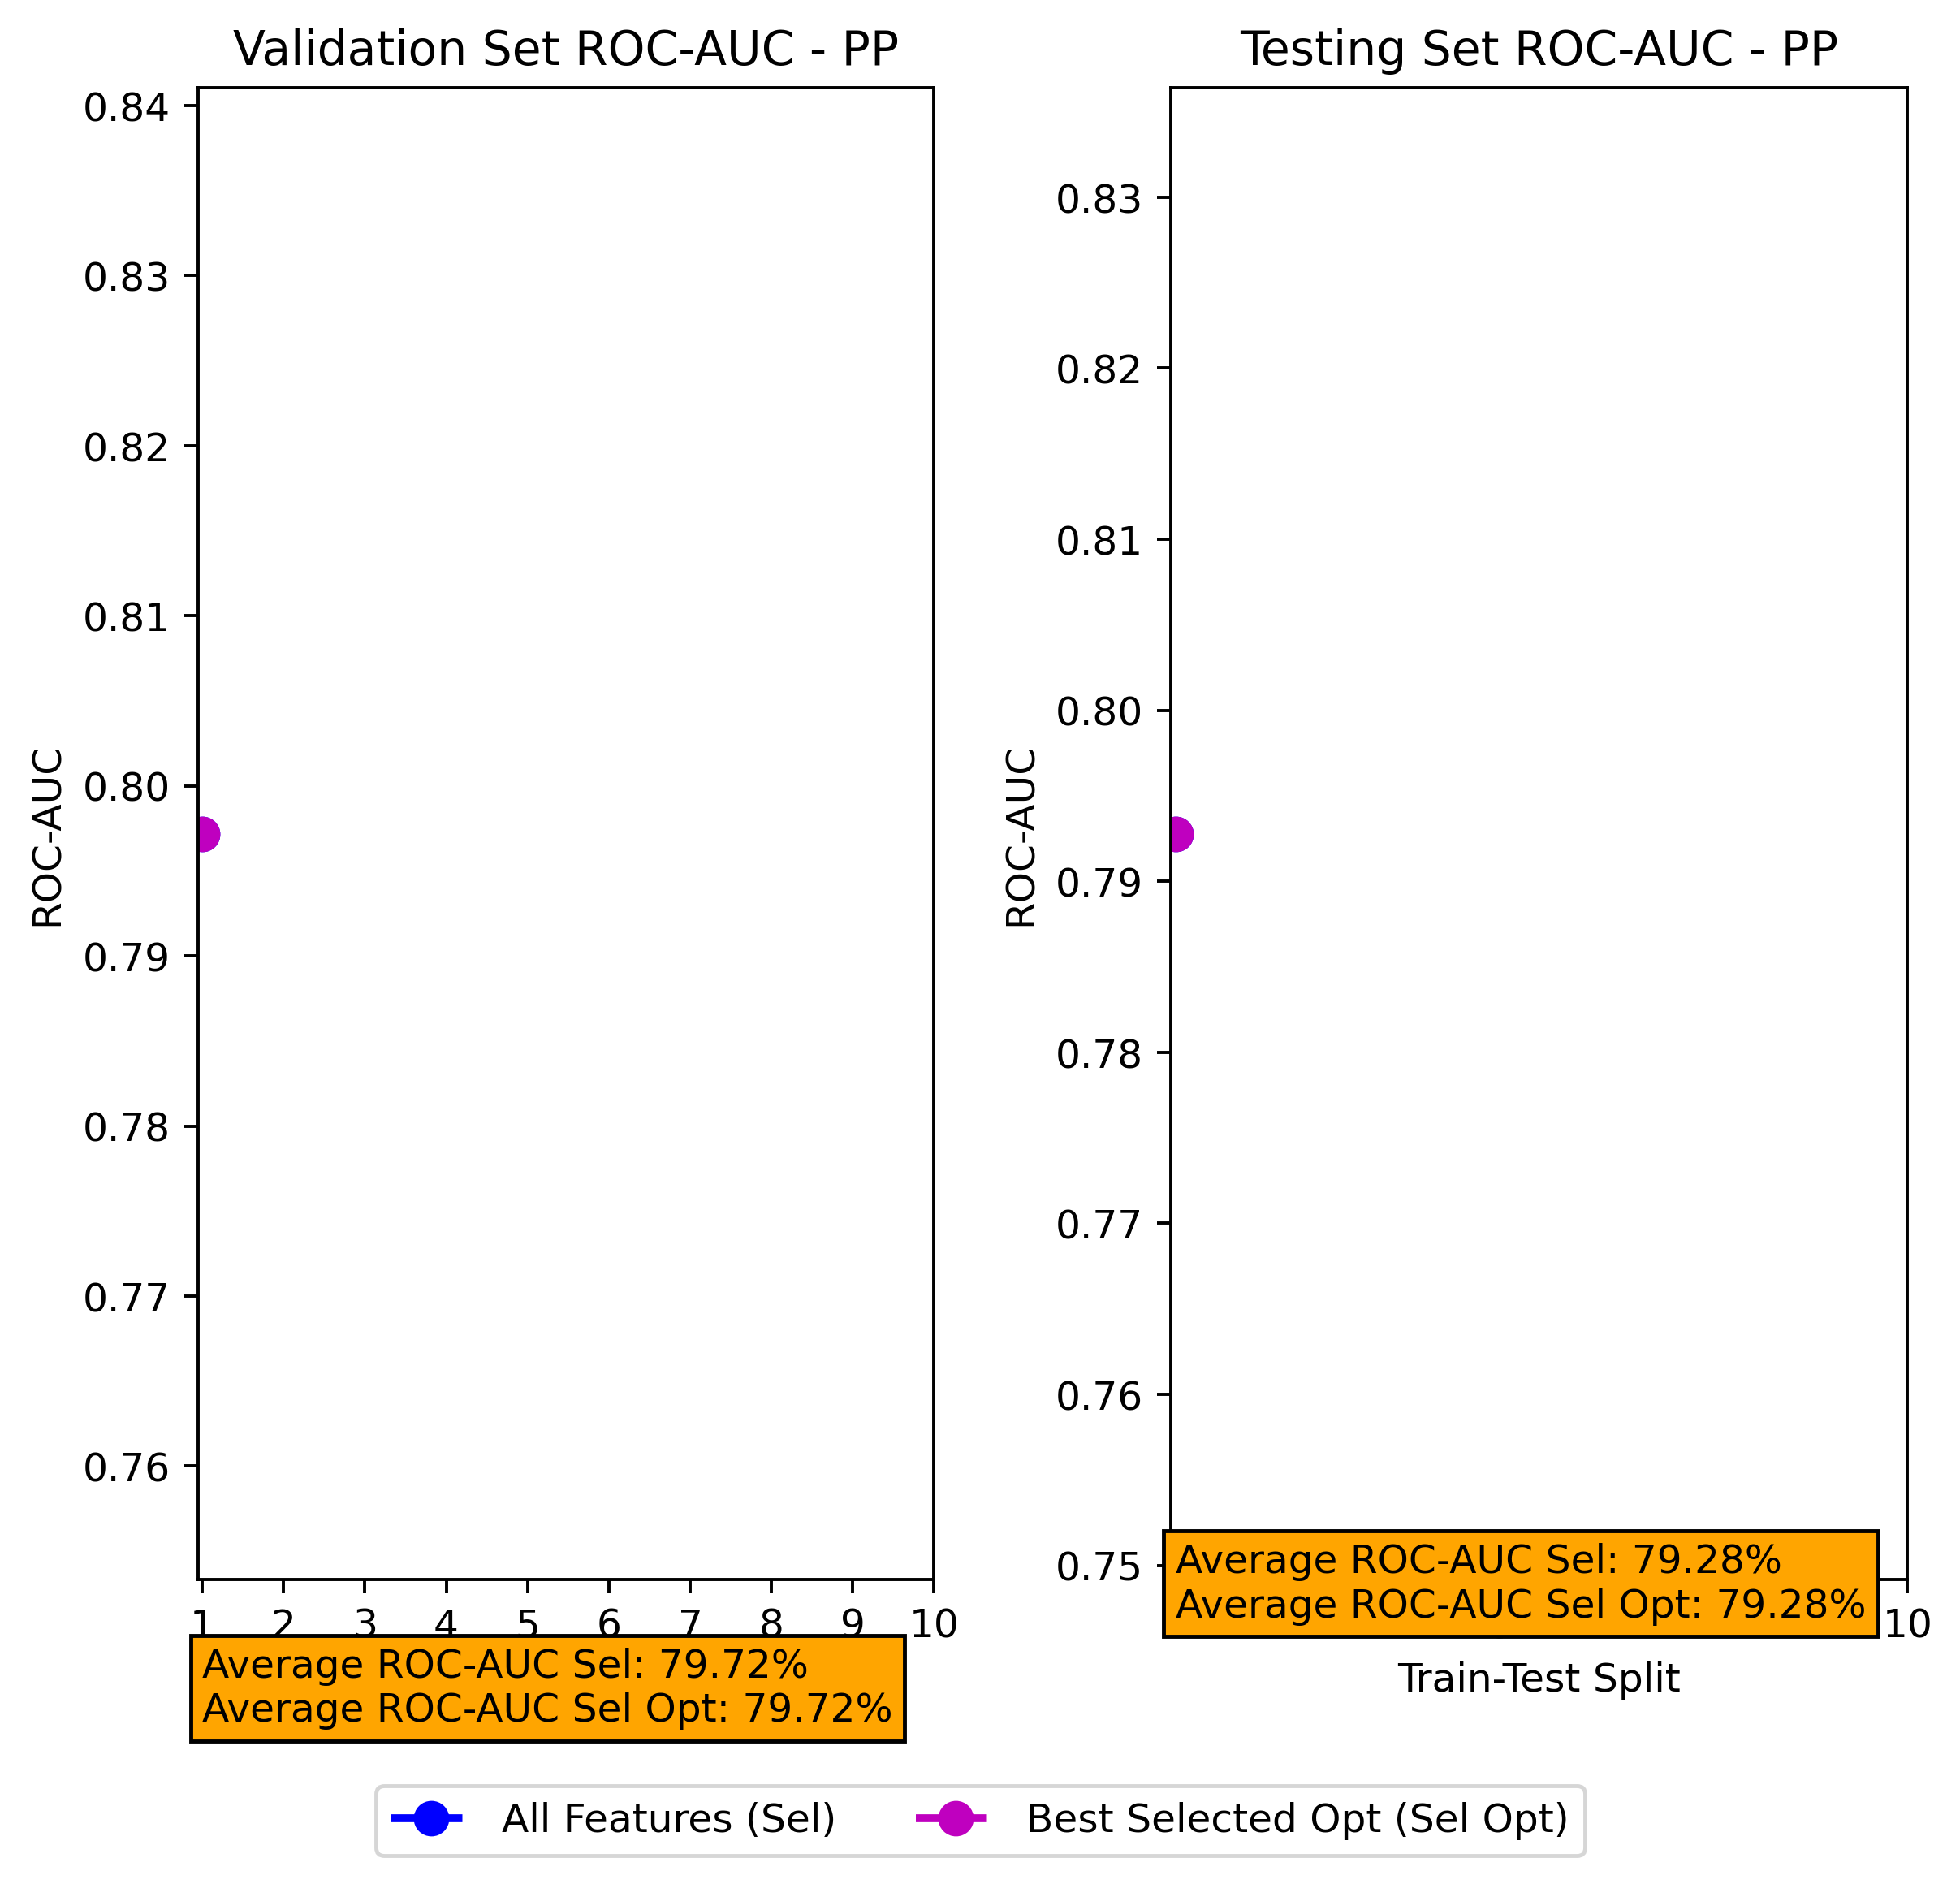

In [164]:
plt.figure(figsize=(7, 7), dpi=350)

# 1st Plot: Validation Set ROC-AUC
plt.subplot(1, 2, 1)
plt.plot(rf_val_roc_n_sel_kmer, 'b--', marker='o', markersize=8, linewidth=2)
plt.plot(rf_val_roc_n_sel_opt_kmer, 'm--', marker='o', markersize=8, linewidth=2)
plt.xlabel('Train-Test Split')
plt.ylabel('ROC-AUC')
plt.xticks(ticks=range(0, 10), labels=range(1, 11))
plt.title('Validation Set ROC-AUC - PP')
plt.text(
    0, 0.745,
    'Average ROC-AUC Sel: ' + str(np.round(np.average(rf_val_roc_n_sel_kmer) * 100, decimals=2)) + '%' +
    '\nAverage ROC-AUC Sel Opt: ' + str(np.round(np.average(rf_val_roc_n_sel_opt_kmer) * 100, decimals=2)) + '%',
    bbox=dict(boxstyle='square', fc='orange', ec='k')
)

# 2nd Plot: Testing Set ROC-AUC
plt.subplot(1, 2, 2)
plt.plot(rf_test_roc_n_sel_kmer, 'b--', marker='o', markersize=8, linewidth=2)
plt.plot(rf_test_roc_n_sel_opt_kmer, 'm--', marker='o', markersize=8, linewidth=2)
plt.xlabel('Train-Test Split')
plt.ylabel('ROC-AUC')
plt.xticks(ticks=range(0, 10), labels=range(1, 11))
plt.title('Testing Set ROC-AUC - PP')
plt.text(
    0, 0.747,
    'Average ROC-AUC Sel: ' + str(np.round(np.average(rf_test_roc_n_sel_kmer) * 100, decimals=2)) + '%' +
    '\nAverage ROC-AUC Sel Opt: ' + str(np.round(np.average(rf_test_roc_n_sel_opt_kmer) * 100, decimals=2)) + '%',
    bbox=dict(boxstyle='square', fc='orange', ec='k')
)

# Legend
plt.figlegend(
    ['All Features (Sel)', 'Best Selected Opt (Sel Opt)'],
    loc='lower center',
    bbox_to_anchor=(0.5, 0.0),
    ncol=2
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

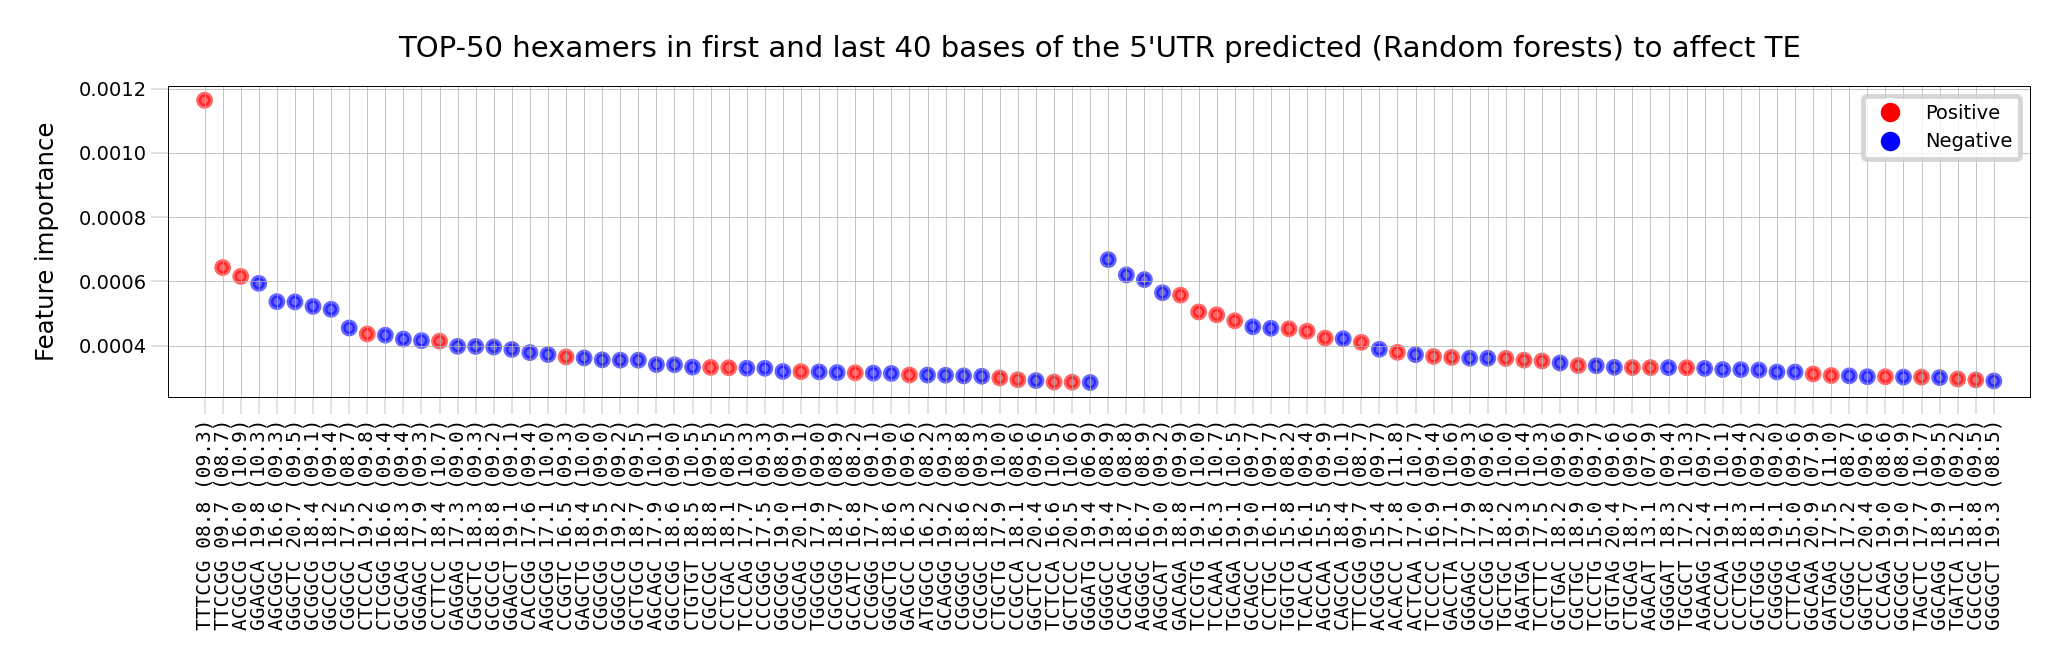

In [172]:
# Importance from model for last split
i=0

rf = eval(f'rf_5_3_kmer_split{i}')
importances = rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

feature_names = list(eval(f'sel_feat_by_stats_5_3_kmer_split{i}'))

forest_importances_5_3_kmer = pd.Series(importances, index=feature_names).reset_index()
forest_importances_5_3_kmer.columns = ['index', 'importance']
forest_importances_5_3_kmer['kmer'] = forest_importances_5_3_kmer['index'].apply(lambda x: x[:6])
kemrs_pos_5_1st['kmer'] = kemrs_pos_5_1st.index

# Merge kemrs_pos_5 positions with forest_importances_5kmer on 'kmer'
forest_importances_5_3_kmer = forest_importances_5_3_kmer.merge(kemrs_pos_5_1st, on='kmer', how='left')
forest_importances_5_3_kmer.set_index('index', inplace=True)

# Filter rows where index has "_5_1st" or "_5_2nd"
forest_importances_5_3_kmer_1st = forest_importances_5_3_kmer.filter(like='_5_1st', axis=0)
forest_importances_5_3_kmer_2nd = forest_importances_5_3_kmer.filter(like='_5_2nd', axis=0)

# Now sort and get the top 50 entries for each
forest_importances_5_3_kmer_1st = forest_importances_5_3_kmer_1st.sort_values(by='importance', ascending=False).head(50)
forest_importances_5_3_kmer_2nd = forest_importances_5_3_kmer_2nd.sort_values(by='importance', ascending=False).head(50)

forest_importances_5_3_kmer_TOP50 = pd.concat([forest_importances_5_3_kmer_1st, forest_importances_5_3_kmer_2nd], axis=0)

# Convert the DataFrame for plotting
df_5_3_kmer = forest_importances_5_3_kmer_TOP50.reset_index()
df_5_3_kmer.columns = ['Feature', 'Importance', 'Kmer', 'Mean_Position', 'SE_Position']
df_5_3_kmer['FC'] = eval(f'mannWhit_UpperVsLower_5_3_kmer_split{i}').loc[df_5_3_kmer['Feature'], 'FC'].values

# Modify the feature labels for the x-ticks
df_5_3_kmer['Modified_Feature'] = df_5_3_kmer.apply(
    lambda row: f"{row['Feature'].split('_')[0]} {format(row['Mean_Position'], '04.1f')} ({format(row['SE_Position'], '04.1f')})",
    axis=1
)

# Plotting
fig, ax = plt.subplots(dpi=350, figsize=(6, 2), tight_layout=True)

# Colors based on the condition
colors = np.where(df_5_3_kmer['FC'] > 1, 'red', 'blue')  # 'red' for 'Positive', 'blue' for 'Negative'

# Scatter plot with custom colors
scatter = ax.scatter(df_5_3_kmer.index, df_5_3_kmer['Importance'], c=colors, s=6, alpha=0.6)

# Setting x-ticks and labels
ax.set_xticks(df_5_3_kmer.index)
ax.set_xticklabels(df_5_3_kmer['Modified_Feature'], fontsize=3, rotation=90, fontname='Monospace')

# Setting plot title and labels
ax.set_title("TOP-50 hexamers in first and last 40 bases of the 5'UTR predicted (Random forests) to affect TE", fontsize=6)
ax.set_ylabel("Feature importance", fontsize=5)
ax.tick_params(axis='both', labelsize=4, width=0.05, pad=1)
ax.grid(True, linestyle='-', linewidth=0.15)
ax.set_xlim(left=-2, right=len(df_5_3_kmer) + 1)

# Thinner plot borders
for spine in ax.spines.values():
    spine.set_linewidth(0.2)

# Adding a legend
legend_labels = ['Positive' if fc > 1 else 'Negative' for fc in df_5_3_kmer['FC']]
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Positive',
                          markerfacecolor='red', markersize=5),
                   Line2D([0], [0], marker='o', color='w', label='Negative',
                          markerfacecolor='blue', markersize=5)]
ax.legend(handles=legend_elements, fontsize=4)

plt.show()

In [174]:
df_5kmer_1st = df_5_3_kmer[df_5_3_kmer['Feature'].str.endswith('5_1st')]
df_5kmer_2nd = df_5_3_kmer[df_5_3_kmer['Feature'].str.endswith('5_2nd')]

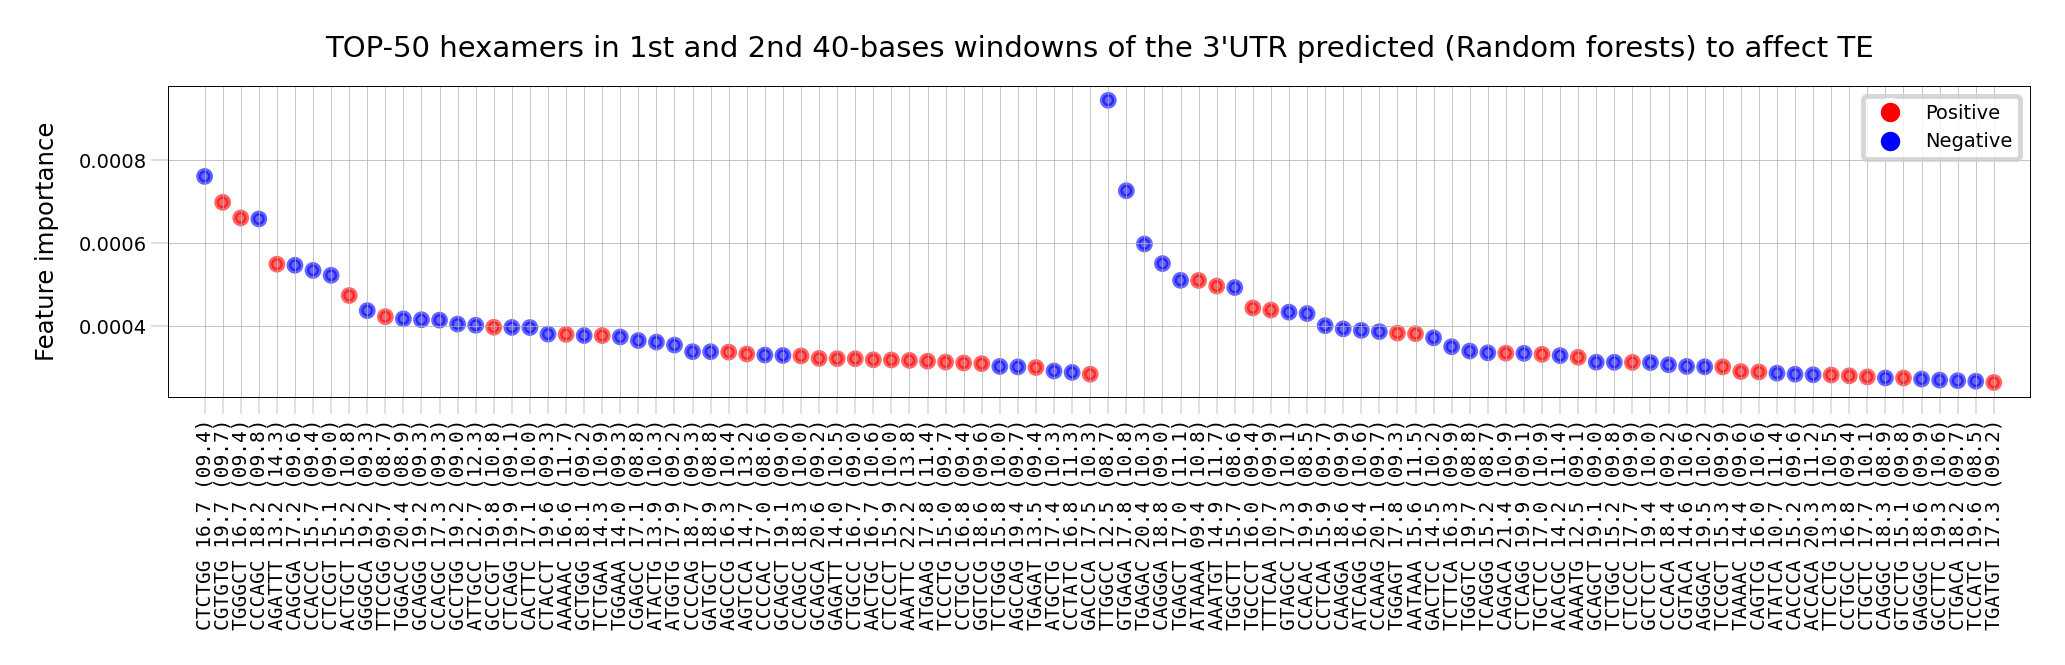

In [176]:
# Importance from model for last split
i=0

rf = eval(f'rf_5_3_kmer_split{i}')
importances = rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

feature_names = list(eval(f'sel_feat_by_stats_5_3_kmer_split{i}'))

forest_importances_5_3_kmer = pd.Series(importances, index=feature_names).reset_index()
forest_importances_5_3_kmer.columns = ['index', 'importance']
forest_importances_5_3_kmer['kmer'] = forest_importances_5_3_kmer['index'].apply(lambda x: x[:6])
kemrs_pos_5_1st['kmer'] = kemrs_pos_5_1st.index

# Merge kemrs_pos_5 positions with forest_importances_5kmer on 'kmer'
forest_importances_5_3_kmer = forest_importances_5_3_kmer.merge(kemrs_pos_5_1st, on='kmer', how='left')
forest_importances_5_3_kmer.set_index('index', inplace=True)

# Filter rows where index has "_5_1st" or "_5_2nd"
forest_importances_5_3_kmer_1st = forest_importances_5_3_kmer.filter(like='_3_1st', axis=0)
forest_importances_5_3_kmer_2nd = forest_importances_5_3_kmer.filter(like='_3_2nd', axis=0)

# Now sort and get the top 50 entries for each
forest_importances_5_3_kmer_1st = forest_importances_5_3_kmer_1st.sort_values(by='importance', ascending=False).head(50)
forest_importances_5_3_kmer_2nd = forest_importances_5_3_kmer_2nd.sort_values(by='importance', ascending=False).head(50)

forest_importances_5_3_kmer_TOP50 = pd.concat([forest_importances_5_3_kmer_1st, forest_importances_5_3_kmer_2nd], axis=0)

# Convert the DataFrame for plotting
df_5_3_kmer = forest_importances_5_3_kmer_TOP50.reset_index()
df_5_3_kmer.columns = ['Feature', 'Importance', 'Kmer', 'Mean_Position', 'SE_Position']
df_5_3_kmer['FC'] = eval(f'mannWhit_UpperVsLower_5_3_kmer_split{i}').loc[df_5_3_kmer['Feature'], 'FC'].values

# Modify the feature labels for the x-ticks
df_5_3_kmer['Modified_Feature'] = df_5_3_kmer.apply(
    lambda row: f"{row['Feature'].split('_')[0]} {format(row['Mean_Position'], '04.1f')} ({format(row['SE_Position'], '04.1f')})",
    axis=1
)

# Plotting
fig, ax = plt.subplots(dpi=350, figsize=(6, 2), tight_layout=True)

# Colors based on the condition
colors = np.where(df_5_3_kmer['FC'] > 1, 'red', 'blue')  # 'red' for 'Positive', 'blue' for 'Negative'

# Scatter plot with custom colors
scatter = ax.scatter(df_5_3_kmer.index, df_5_3_kmer['Importance'], c=colors, s=6, alpha=0.6)

# Setting x-ticks and labels
ax.set_xticks(df_5_3_kmer.index)
ax.set_xticklabels(df_5_3_kmer['Modified_Feature'], fontsize=3, rotation=90, fontname='Monospace')

# Setting plot title and labels
ax.set_title("TOP-50 hexamers in 1st and 2nd 40-bases windowns of the 3'UTR predicted (Random forests) to affect TE", fontsize=6)
ax.set_ylabel("Feature importance", fontsize=5)
ax.tick_params(axis='both', labelsize=4, width=0.05, pad=1)
ax.grid(True, linestyle='-', linewidth=0.15)
ax.set_xlim(left=-2, right=len(df_5_3_kmer) + 1)

# Thinner plot borders
for spine in ax.spines.values():
    spine.set_linewidth(0.2)

# Adding a legend
legend_labels = ['Positive' if fc > 1 else 'Negative' for fc in df_5_3_kmer['FC']]
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Positive',
                          markerfacecolor='red', markersize=5),
                   Line2D([0], [0], marker='o', color='w', label='Negative',
                          markerfacecolor='blue', markersize=5)]
ax.legend(handles=legend_elements, fontsize=4)

plt.show()

In [177]:
df_3kmer_1st = df_5_3_kmer[df_5_3_kmer['Feature'].str.endswith('3_1st')]
df_3kmer_2nd = df_5_3_kmer[df_5_3_kmer['Feature'].str.endswith('3_2nd')]

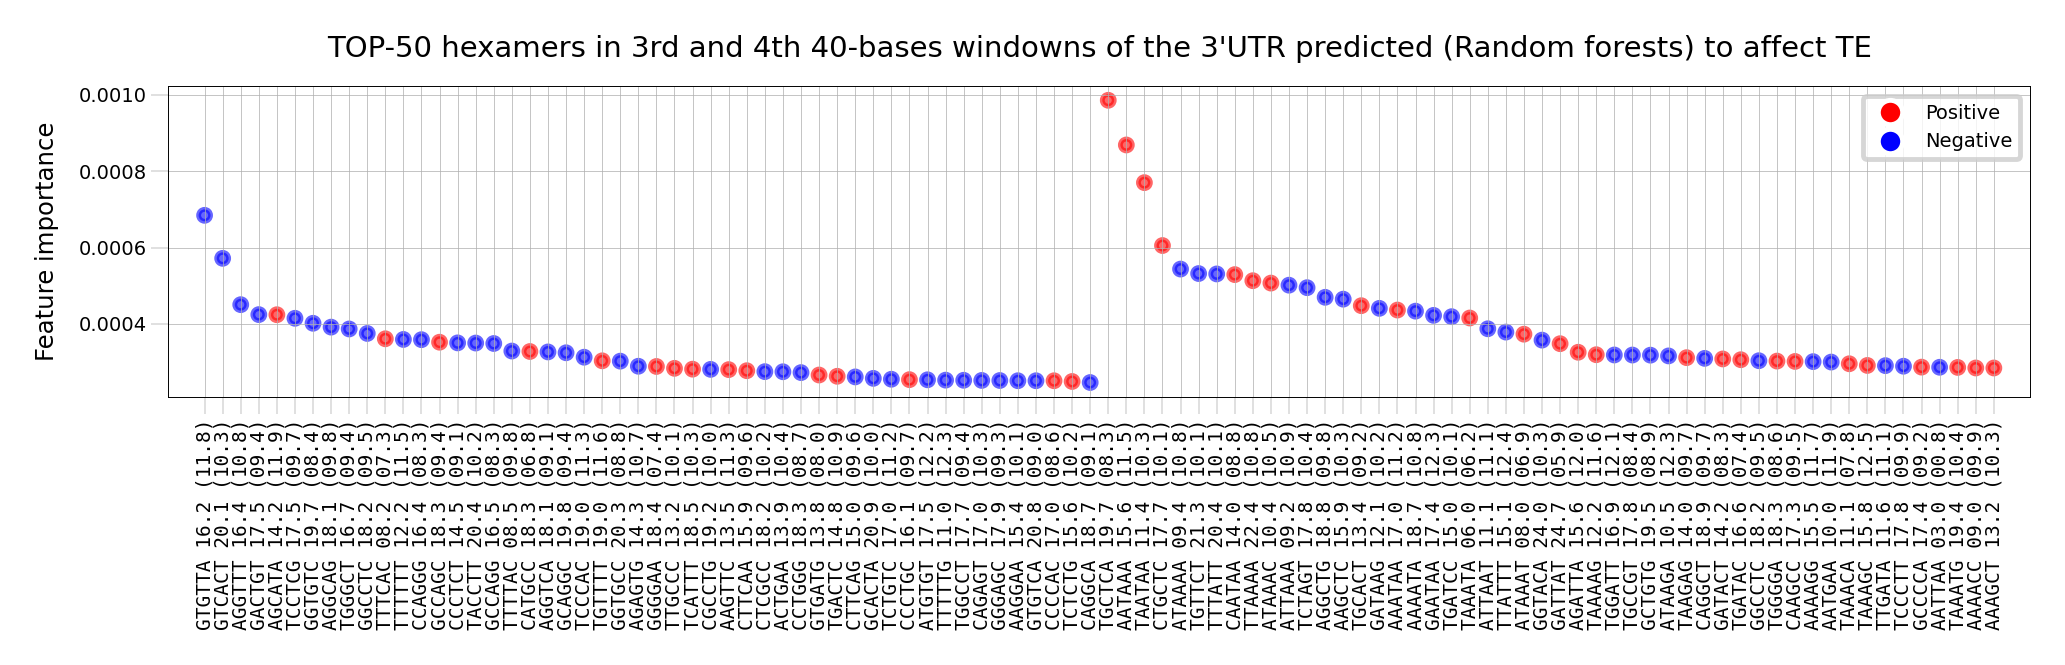

In [178]:
# Importance from model for last split
i=0

rf = eval(f'rf_5_3_kmer_split{i}')
importances = rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

feature_names = list(eval(f'sel_feat_by_stats_5_3_kmer_split{i}'))

forest_importances_5_3_kmer = pd.Series(importances, index=feature_names).reset_index()
forest_importances_5_3_kmer.columns = ['index', 'importance']
forest_importances_5_3_kmer['kmer'] = forest_importances_5_3_kmer['index'].apply(lambda x: x[:6])
kemrs_pos_5_1st['kmer'] = kemrs_pos_5_1st.index

# Merge kemrs_pos_5 positions with forest_importances_5kmer on 'kmer'
forest_importances_5_3_kmer = forest_importances_5_3_kmer.merge(kemrs_pos_5_1st, on='kmer', how='left')
forest_importances_5_3_kmer.set_index('index', inplace=True)

forest_importances_5_3_kmer_3rd = forest_importances_5_3_kmer.filter(like='_3_3rd', axis=0)
forest_importances_5_3_kmer_4th = forest_importances_5_3_kmer.filter(like='_3_4th', axis=0)

# Now sort and get the top 50 entries for each
forest_importances_5_3_kmer_3rd = forest_importances_5_3_kmer_3rd.sort_values(by='importance', ascending=False).head(50)
forest_importances_5_3_kmer_4th = forest_importances_5_3_kmer_4th.sort_values(by='importance', ascending=False).head(50)

forest_importances_5_3_kmer_TOP50 = pd.concat([forest_importances_5_3_kmer_3rd, forest_importances_5_3_kmer_4th], axis=0)

# Convert the DataFrame for plotting
df_5_3_kmer = forest_importances_5_3_kmer_TOP50.reset_index()
df_5_3_kmer.columns = ['Feature', 'Importance', 'Kmer', 'Mean_Position', 'SE_Position']
df_5_3_kmer['FC'] = eval(f'mannWhit_UpperVsLower_5_3_kmer_split{i}').loc[df_5_3_kmer['Feature'], 'FC'].values

# Modify the feature labels for the x-ticks
df_5_3_kmer['Modified_Feature'] = df_5_3_kmer.apply(
    lambda row: f"{row['Feature'].split('_')[0]} {format(row['Mean_Position'], '04.1f')} ({format(row['SE_Position'], '04.1f')})",
    axis=1
)

# Plotting
fig, ax = plt.subplots(dpi=350, figsize=(6, 2), tight_layout=True)

# Colors based on the condition
colors = np.where(df_5_3_kmer['FC'] > 1, 'red', 'blue')  # 'red' for 'Positive', 'blue' for 'Negative'

# Scatter plot with custom colors
scatter = ax.scatter(df_5_3_kmer.index, df_5_3_kmer['Importance'], c=colors, s=6, alpha=0.6)

# Setting x-ticks and labels
ax.set_xticks(df_5_3_kmer.index)
ax.set_xticklabels(df_5_3_kmer['Modified_Feature'], fontsize=3, rotation=90, fontname='Monospace')

# Setting plot title and labels
ax.set_title("TOP-50 hexamers in 3rd and 4th 40-bases windowns of the 3'UTR predicted (Random forests) to affect TE", fontsize=6)
ax.set_ylabel("Feature importance", fontsize=5)
ax.tick_params(axis='both', labelsize=4, width=0.05, pad=1)
ax.grid(True, linestyle='-', linewidth=0.15)
ax.set_xlim(left=-2, right=len(df_5_3_kmer) + 1)

# Thinner plot borders
for spine in ax.spines.values():
    spine.set_linewidth(0.2)

# Adding a legend
legend_labels = ['Positive' if fc > 1 else 'Negative' for fc in df_5_3_kmer['FC']]
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Positive',
                          markerfacecolor='red', markersize=5),
                   Line2D([0], [0], marker='o', color='w', label='Negative',
                          markerfacecolor='blue', markersize=5)]
ax.legend(handles=legend_elements, fontsize=4)

plt.show()

In [182]:
df_3kmer_3rd = df_5_3_kmer[df_5_3_kmer['Feature'].str.endswith('3_3rd')]
df_3kmer_4th = df_5_3_kmer[df_5_3_kmer['Feature'].str.endswith('3_4th')]

# Define a function to get the top 5 scores for FC above and below 1
def get_top5(df):
    df_fc_above_1 = df[df['FC'] > 1].nlargest(10, 'Importance')
    df_fc_below_1 = df[df['FC'] < 1].nlargest(10, 'Importance')
    return pd.concat([df_fc_above_1, df_fc_below_1], axis=0)  # Concatenate along rows

# Concatenate the results for '1st' and '2nd' dataframes along columns
result = pd.concat([get_top5(df_5kmer_1st), get_top5(df_5kmer_2nd)], axis=0)
top_kmers_5_1st2nd = list(result['Feature'])

result = pd.concat([get_top5(df_3kmer_1st), get_top5(df_3kmer_2nd)], axis=0)
top_kmers_3_1st2nd = list(result['Feature'])

result = pd.concat([get_top5(df_3kmer_3rd), get_top5(df_3kmer_4th)], axis=0)
top_kmers_3_3rd4th = list(result['Feature'])

In [57]:
# df_5kmer_1st.to_csv('kmers/top50_kmers_5_1st.csv', index=False)
# df_5kmer_2nd.to_csv('kmers/top50_kmers_5_2nd.csv', index=False)
# df_3kmer_1st.to_csv('kmers/top50_kmers_3_1st.csv', index=False)
# df_3kmer_2nd.to_csv('kmers/top50_kmers_3_2nd.csv', index=False)
# df_3kmer_3rd.to_csv('kmers/top50_kmers_3_3rd.csv', index=False)
# df_3kmer_4th.to_csv('kmers/top50_kmers_3_4th.csv', index=False)

In [203]:
import pandas as pd

# Define file names and corresponding DataFrame keys
file_names = {
    '5_1st': 'kmers/top50_kmers_5_1st.csv',
    '5_2nd': 'kmers/top50_kmers_5_2nd.csv',
    '3_1st': 'kmers/top50_kmers_3_1st.csv',
    '3_2nd': 'kmers/top50_kmers_3_2nd.csv',
    '3_3rd': 'kmers/top50_kmers_3_3rd.csv',
    '3_4th': 'kmers/top50_kmers_3_4th.csv'
}

# Read each CSV into a dictionary of DataFrames
dfs = {key: pd.read_csv(path) for key, path in file_names.items()}

# Access the DataFrames as needed, for example:
top50_kmers_5_1st = dfs['5_1st']
top50_kmers_5_2nd = dfs['5_2nd']
top50_kmers_3_1st = dfs['3_1st']
top50_kmers_3_2nd = dfs['3_2nd']
top50_kmers_3_3rd = dfs['3_3rd']
top50_kmers_3_4th = dfs['3_4th']

top_kmers_5_1st2nd = pd.concat([top50_kmers_5_1st,top50_kmers_5_2nd], axis=0)
top_kmers_3_1st2nd = pd.concat([top50_kmers_3_1st,top50_kmers_3_2nd], axis=0)
top_kmers_3_3rd4th = pd.concat([top50_kmers_3_3rd,top50_kmers_3_4th], axis=0)

In [190]:
# Defining lists to store metrics
rf_train_acc_n_l_ref = []
rf_train_roc_n_l_ref = []
rf_train_f1_n_l_ref = []
rf_test_acc_n_l_ref = []
rf_test_roc_n_l_ref = []
rf_test_f1_n_l_ref = []
rf_val_acc_n_l_ref = []
rf_val_roc_n_l_ref = []
rf_val_f1_n_l_ref = []

rf_train_acc_n_l_sel = []
rf_train_roc_n_l_sel = []
rf_train_f1_n_l_sel = []
rf_test_acc_n_l_sel = []
rf_test_roc_n_l_sel = []
rf_test_f1_n_l_sel = []
rf_val_acc_n_l_sel = []
rf_val_roc_n_l_sel = []
rf_val_f1_n_l_sel = []

rf_train_acc_n_l_sel_opt = []
rf_train_roc_n_l_sel_opt = []
rf_train_f1_n_l_sel_opt = []
rf_test_acc_n_l_sel_opt = []
rf_test_roc_n_l_sel_opt = []
rf_test_f1_n_l_sel_opt = []
rf_val_acc_n_l_sel_opt = []
rf_val_roc_n_l_sel_opt = []
rf_val_f1_n_l_sel_opt = []

model_hyper_param = []
fdr_and_stats_eq_n = []
corr_coeff_train = []
corr_coeff_test = []

for n_split in range(0): #N_SPLITS
    
    # Spliting data set into train val and test sets
    #-----------------------------------------------
    rnd_seed = RANDOM_SEEDS[n_split]

    # numeric features
    X_train_n, X_new, y_train, y_new = train_test_split(X_n, y_categories, test_size=0.4 ,shuffle=True, stratify=y_categories, random_state=rnd_seed)
    X_test_n, X_val_n, y_test, y_val = train_test_split(X_new, y_new, test_size=0.5 ,shuffle=True, stratify=y_new, random_state=rnd_seed)

    X_train_n, X_new, y_train_num, y_new_num = train_test_split(X_n, y, test_size=0.4 ,shuffle=True, stratify=y_categories, random_state=rnd_seed)
    X_test_n, X_val_n, y_test_num, y_val_num = train_test_split(X_new, y_new_num, test_size=0.5 ,shuffle=True, stratify=y_new, random_state=rnd_seed)
    
    # # labled features
    # X_train_l, X_new, y_train, y_new = train_test_split(X_l, y_categories, test_size=0.4 ,shuffle=True, stratify=y_categories, random_state=rnd_seed)
    # X_test_l, X_val_l, y_test, y_val = train_test_split(X_new, y_new, test_size=0.5 ,shuffle=True, stratify=y_new, random_state=rnd_seed)

    # X_train_l, X_new, y_train_num, y_new_num = train_test_split(X_l, y, test_size=0.4 ,shuffle=True, stratify=y_categories, random_state=rnd_seed)
    # X_test_l, X_val_l, y_test_num, y_val_num = train_test_split(X_new, y_new_num, test_size=0.5 ,shuffle=True, stratify=y_new, random_state=rnd_seed)    
    
    #X_train_one_hot, X_new, y_train, y_new = train_test_split(X_one_hot, y_categories, test_size=0.4 ,shuffle=True, stratify=y_categories, random_state=rnd_seed)
    #X_test_one_hot, X_val_one_hot, y_test, y_val = train_test_split(X_new, y_new, test_size=0.5 ,shuffle=True, stratify=y_new, random_state=rnd_seed)
    
    #X_train_one_hot = X_train_one_hot.astype(int)
    #X_val_one_hot = X_val_one_hot.astype(int)
    #X_test_one_hot = X_test_one_hot.astype(int)

    
    feat_col = X_train_n.columns
    
    # Scaling the numerical features 
    X_train_n_scaled, X_val_n_scaled, X_test_n_scaled = scale_numerics(X_train_n, X_val_n, X_test_n, scaler_type='standard')
    
    # Imputting NaN
    imputer = KNNImputer(n_neighbors=4, weights="uniform")
    X_train_n_scaled = imputer.fit_transform(X_train_n_scaled)
    X_val_n_scaled = imputer.transform(X_val_n_scaled)
    X_test_n_scaled = imputer.transform(X_test_n_scaled)
    X_train_n = imputer.fit_transform(X_train_n)
    
    # Final numeric + labeld input dataset
    #X_train_n_l_scaled = np.concatenate((X_train_n_scaled, X_train_one_hot), axis=1)
    #X_val_n_l_scaled = np.concatenate((X_val_n_scaled, X_val_one_hot), axis=1)
    #X_test_n_l_scaled = np.concatenate((X_test_n_scaled, X_test_one_hot), axis=1)

    X_train_n_l_scaled = np.concatenate((X_train_n_scaled, X_train_l), axis=1)
    X_val_n_l_scaled = np.concatenate((X_val_n_scaled, X_val_l), axis=1)
    X_test_n_l_scaled = np.concatenate((X_test_n_scaled, X_test_l), axis=1)
    
    # 1)
    #-----------------------------------------------------    
    # Make reference ML model estimations on the numeric targets
    print(f"Initial evaluation for random split #{n_split}:\n")
    
    # Create an RF model
    rf = RandomForestClassifier(random_state=rnd_seed, n_jobs=-1) #class_weight='balanced', n_estimators=200, max_depth = None
    print("Reference Accuracies for Numerics")
    acc_train, acc_val, acc_test, roc_train, roc_val, roc_test, f1_train, f1_val, f1_test = acc_roc_f1_estimation(X_train=X_train_n_l_scaled, y_train=y_train,
                                                                                                                  X_val=X_val_n_l_scaled, y_val=y_val,
                                                                                                                  X_test=X_test_n_l_scaled, y_test=y_test,model=rf)
    
    rf_train_acc_n_l_ref.append(acc_train)
    rf_val_acc_n_l_ref.append(acc_val)
    rf_test_acc_n_l_ref.append(acc_test)
    rf_train_roc_n_l_ref.append(roc_train)
    rf_val_roc_n_l_ref.append(roc_val)
    rf_test_roc_n_l_ref.append(roc_test)
    rf_train_f1_n_l_ref.append(f1_train)
    rf_val_f1_n_l_ref.append(f1_val)
    rf_test_f1_n_l_ref.append(f1_test)
    #----------------------------------------------------- 
    # END 1)
    
    # 2)
    #----------------------------------------------------- 
    # Selecting numerical features with statistics
    X_train_n_l_scaled_sel, X_val_n_l_scaled_sel, X_test_n_l_scaled_sel, sel_feat_by_stats, sel_feat_by_stats_pval, mannWhit_UpperVsLower = feat_sel_by_stats(X_train_n, X_train_n_l_scaled,
    X_val_n_l_scaled,
    X_test_n_l_scaled,
    y_train, feat_col,
    5e-01)

    fdr_and_stats_eq = np.array_equal(fdrcorrection(sel_feat_by_stats_pval,
                                                        alpha=0.05,
                                                        method='indep',
                                                        is_sorted='False')[0], 
                                      (np.array(sel_feat_by_stats_pval) < 0.05))

    fdr_and_stats_eq_n.append(fdr_and_stats_eq)
    
    print(f'Before feature selection we got {X_train_n_l_scaled.shape[1]} features')
    print(f'After feature selection by stat we got {X_train_n_l_scaled_sel.shape[1]} features')

    # Evaluation of selected numerical features with statistics
    rf = RandomForestClassifier(random_state=rnd_seed, n_jobs=-1) #class_weight='balanced', n_estimators=200, max_depth = None
    print()
    print("Accuracies for Numerics - Selected Features from statistics")
    acc_train, acc_val, acc_test, roc_train, roc_val, roc_test, f1_train, f1_val, f1_test  = acc_roc_f1_estimation(X_train=X_train_n_l_scaled_sel,
                                                                                                                  y_train=y_train,
                                                                                                                  X_val=X_val_n_l_scaled_sel, y_val=y_val,
                                                                                                                  X_test=X_test_n_l_scaled_sel, y_test=y_test,
                                                                                                                  model=rf)
    rf_train_acc_n_l_sel.append(acc_train)
    rf_val_acc_n_l_sel.append(acc_val)
    rf_test_acc_n_l_sel.append(acc_test)
    rf_train_roc_n_l_sel.append(roc_train)
    rf_val_roc_n_l_sel.append(roc_val)
    rf_test_roc_n_l_sel.append(roc_test)
    rf_train_f1_n_l_sel.append(f1_train)
    rf_val_f1_n_l_sel.append(f1_val)
    rf_test_f1_n_l_sel.append(f1_test)

    # MHPT
    rf = RandomForestClassifier(random_state=rnd_seed, n_jobs=-1)
    
    n_est = hyperparameter_tunining(X_train=X_train_n_l_scaled_sel, 
                                    y_train=y_train, 
                                    model=rf)

    model_hyper_param.append([n_est])
    rf = RandomForestClassifier(n_estimators=n_est, random_state=rnd_seed, n_jobs=-1)
    acc_train, acc_val, acc_test, roc_train, roc_val, roc_test, f1_train, f1_val, f1_test = acc_roc_f1_estimation(X_train=X_train_n_l_scaled_sel,
                                                                                                                  y_train=y_train,
                                                                                                                  X_val=X_val_n_l_scaled_sel, y_val=y_val,
                                                                                                                  X_test=X_test_n_l_scaled_sel, y_test=y_test,
                                                                                                                  model=rf)


    rf_train_acc_n_l_sel_opt.append(acc_train)
    rf_val_acc_n_l_sel_opt.append(acc_val)
    rf_test_acc_n_l_sel_opt.append(acc_test)
    rf_train_roc_n_l_sel_opt.append(roc_train)
    rf_val_roc_n_l_sel_opt.append(roc_val)
    rf_test_roc_n_l_sel_opt.append(roc_test)
    rf_train_f1_n_l_sel_opt.append(f1_train)
    rf_val_f1_n_l_sel_opt.append(f1_val)
    rf_test_f1_n_l_sel_opt.append(f1_test)


    # # Regression
    # corr_coeff_train_, corr_coeff_test_ = xgb_reg(X_train_=X_train_n_l_scaled_sel, X_test_=X_test_n_l_scaled_sel,
    #                                               y_train_num=y_train_num, y_test_num=y_test_num)
    
    # corr_coeff_train.append(corr_coeff_train_)

    # corr_coeff_test.append(corr_coeff_test_)
    # # End Regression    
    
    
    # saving rf model for each iteration
    globals()[f'rf_reg_split{n_split}'] = rf
    # globals()[f'class_val_ref{n_split}'] = class_val_ref
    # globals()[f'class_test_ref{n_split}'] = class_test_ref
    # globals()[f'class_val_sel{n_split}'] = class_val_sel
    # globals()[f'class_test_sel{n_split}'] = class_test_sel
    globals()[f'sel_feat_by_stats_reg_split{n_split}'] = sel_feat_by_stats
    globals()[f'sel_feat_by_stats_pval_reg_split{n_split}'] = sel_feat_by_stats_pval
    globals()[f'mannWhit_UpperVsLower_reg_split{n_split}'] = mannWhit_UpperVsLower
    
    


In [ ]:
#Roc-AUC
print("Train Ref Roc n: ", np.average(rf_train_roc_n_l_ref))  
print("Val Ref Roc n: ", np.average(rf_val_roc_n_l_ref)) 
print("Test Ref Roc n: ", np.average(rf_test_roc_n_l_ref)) 
print('----------------------------------')
print("Train Sel Roc n: ", np.average(rf_train_roc_n_l_sel))   
print("Val Sel Roc n: ", np.average(rf_val_roc_n_l_sel))
print("Test Sel Roc n: ", np.average(rf_test_roc_n_l_sel)) 
print('----------------------------------')
print("Train Sel Opt Roc n: ", np.average(rf_train_roc_n_l_sel_opt))   
print("Val Sel Opt Roc n: ", np.average(rf_val_roc_n_l_sel_opt))
print("Test Sel Opt Roc n: ", np.average(rf_test_roc_n_l_sel_opt)) 

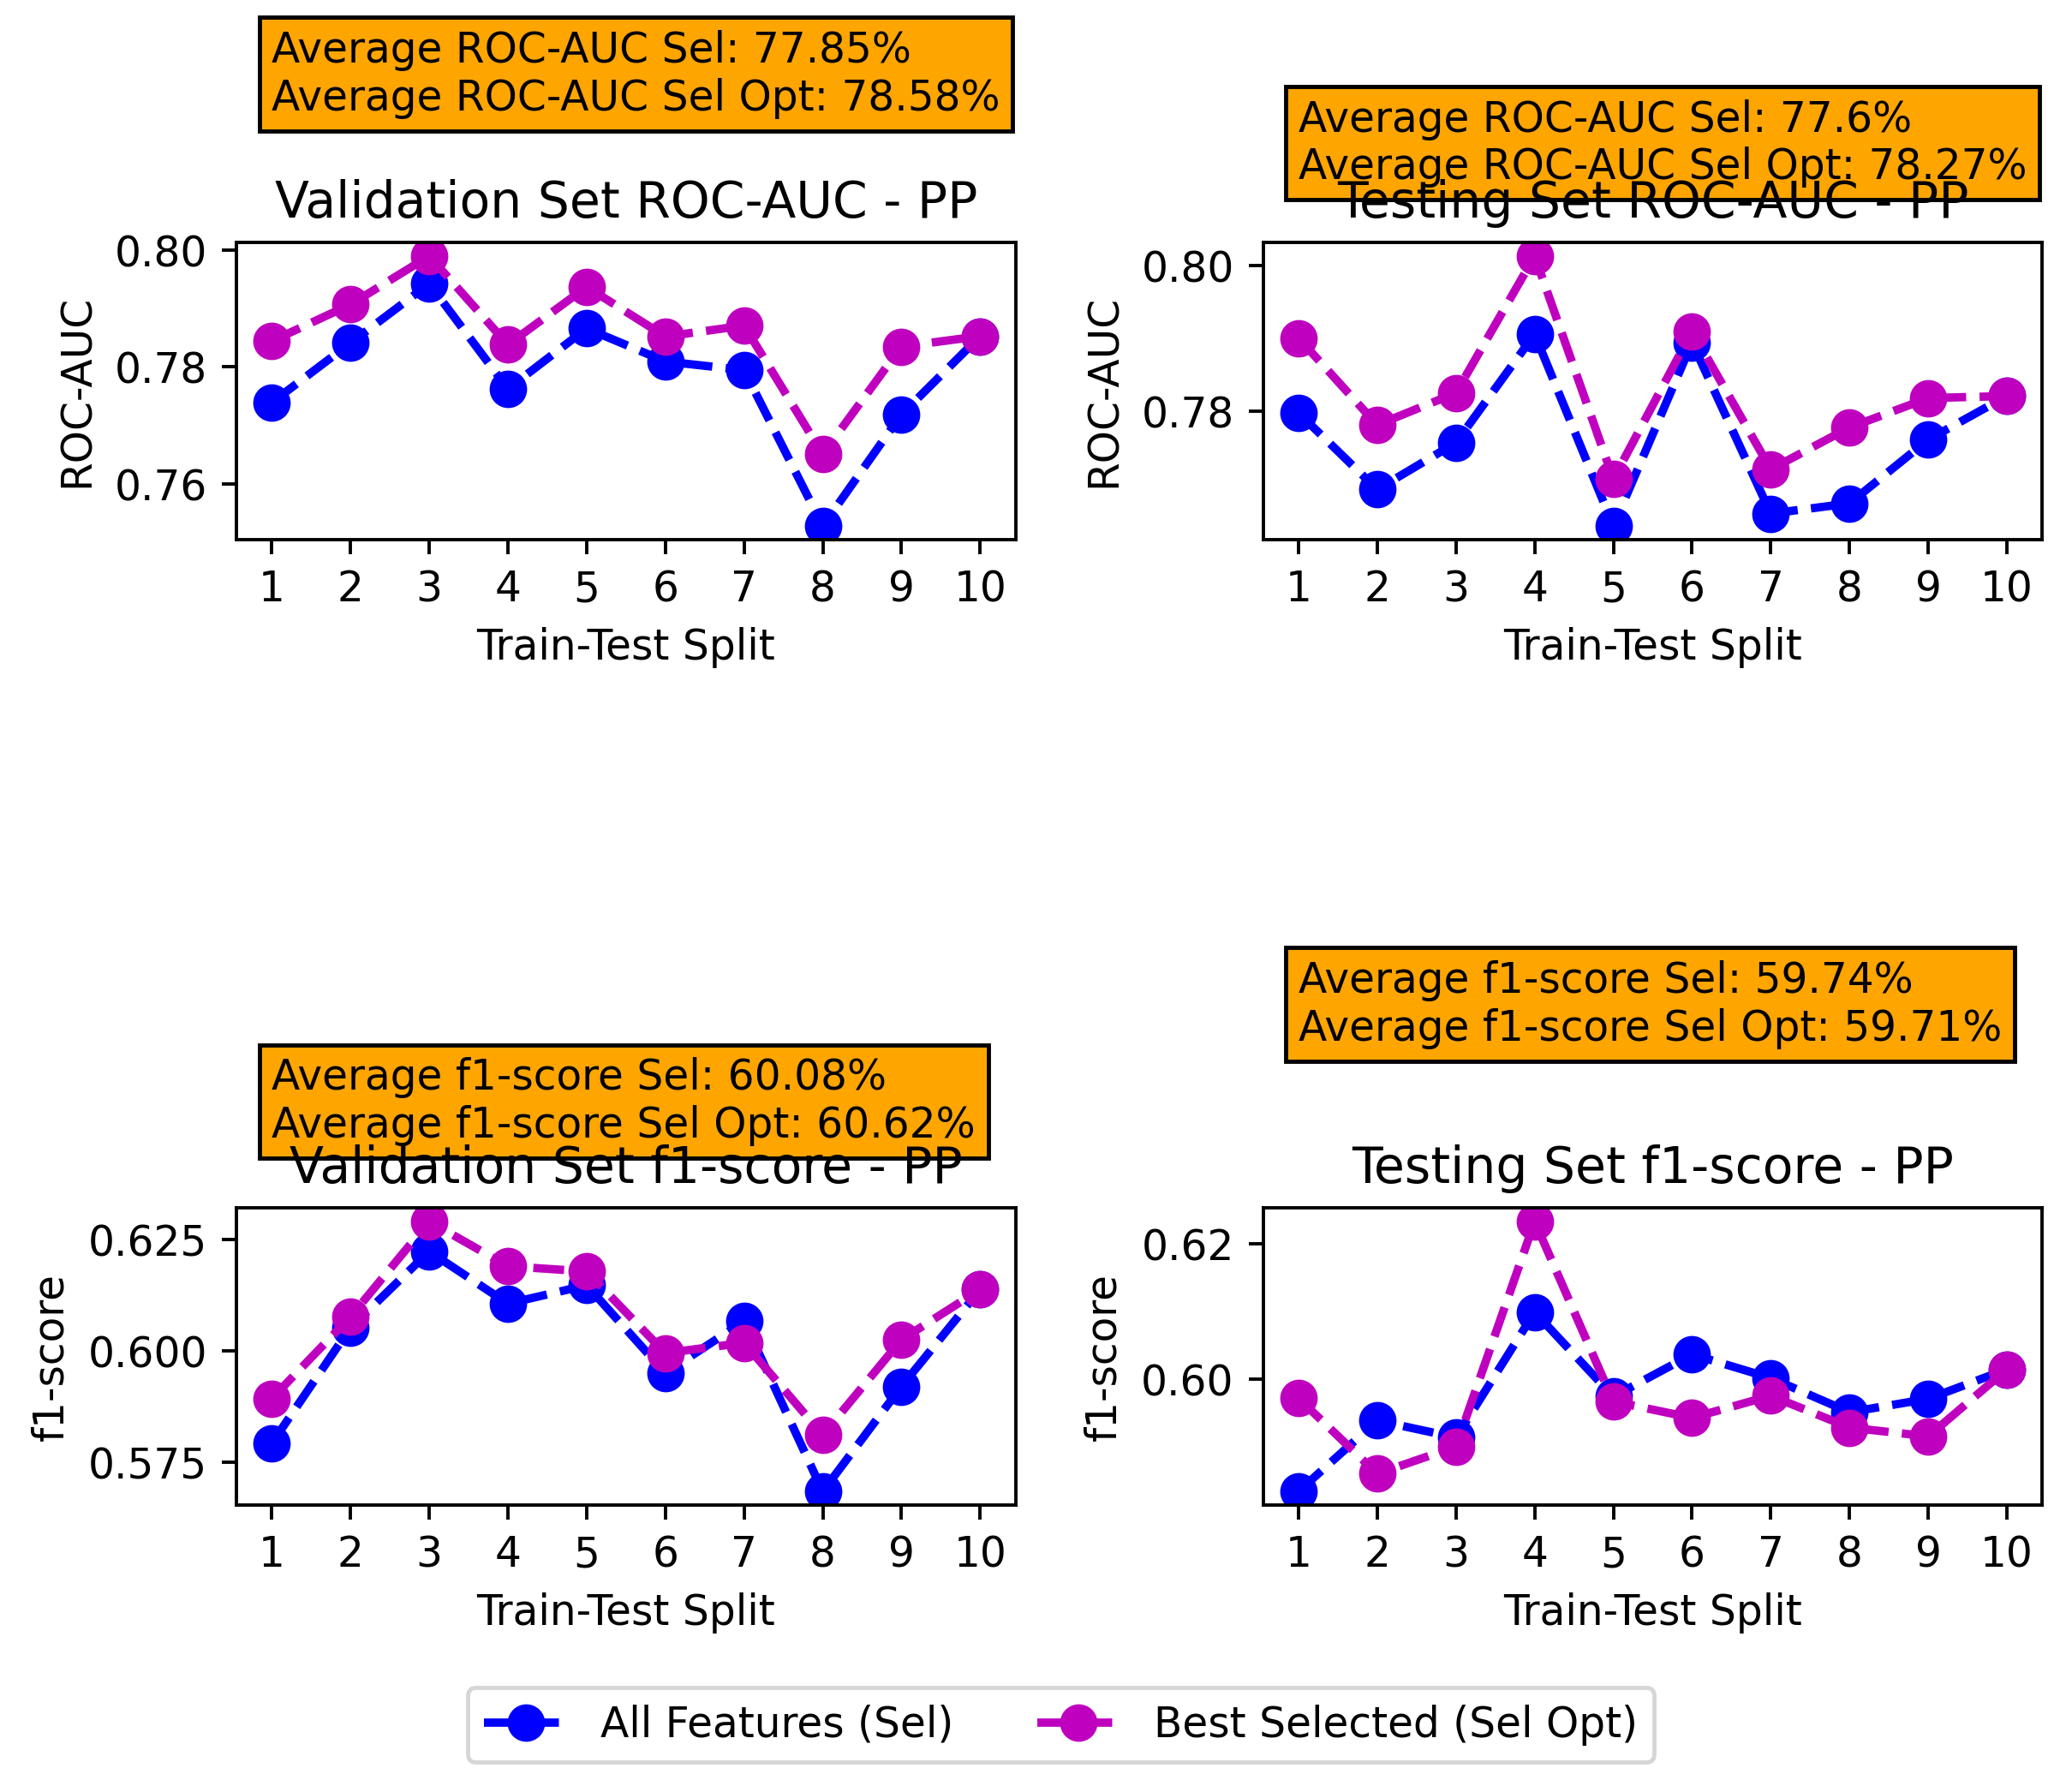

In [61]:
plt.figure(figsize=(7, 7), dpi=350)  # Adjust the figure size for better spacing

# 1st Plot: Validation Set ROC-AUC
plt.subplot(2, 2, 1)
plt.plot(rf_val_roc_n_l_sel, 'b--', marker='o', markersize=8, linewidth=2)
plt.plot(rf_val_roc_n_l_sel_opt, 'm--', marker='o', markersize=8, linewidth=2)
plt.xlabel('Train-Test Split')
plt.ylabel('ROC-AUC')
plt.xticks(ticks=range(0, 10), labels=range(1, 11))
plt.title('Validation Set ROC-AUC - PP')
plt.text(0, 0.824, 'Average ROC-AUC Sel: ' + str(np.round(np.average(rf_val_roc_n_l_sel) * 100, decimals=2)) + '%' +
         '\nAverage ROC-AUC Sel Opt: ' + str(np.round(np.average(rf_val_roc_n_l_sel_opt) * 100, decimals=2)) + '%',
         bbox=dict(boxstyle='square', fc='orange', ec='k'))

# 2nd Plot: Testing Set ROC-AUC
plt.subplot(2, 2, 2)
plt.plot(rf_test_roc_n_l_sel, 'b--', marker='o', markersize=8, linewidth=2)
plt.plot(rf_test_roc_n_l_sel_opt, 'm--', marker='o', markersize=8, linewidth=2)
plt.xlabel('Train-Test Split')
plt.ylabel('ROC-AUC')
plt.xticks(ticks=range(0, 10), labels=range(1, 11))
plt.title('Testing Set ROC-AUC - PP')
plt.text(0, 0.812, 'Average ROC-AUC Sel: ' + str(np.round(np.average(rf_test_roc_n_l_sel) * 100, decimals=2)) + '%' +
         '\nAverage ROC-AUC Sel Opt: ' + str(np.round(np.average(rf_test_roc_n_l_sel_opt) * 100, decimals=2)) + '%',
         bbox=dict(boxstyle='square', fc='orange', ec='k'))

# 3rd Plot: Validation Set f1-score
plt.subplot(2, 2, 3)
plt.plot(rf_val_f1_n_l_sel, 'b--', marker='o', markersize=8, linewidth=2)
plt.plot(rf_val_f1_n_l_sel_opt, 'm--', marker='o', markersize=8, linewidth=2)
plt.xlabel('Train-Test Split')
plt.ylabel('f1-score')
plt.xticks(ticks=range(0, 10), labels=range(1, 11))
plt.title('Validation Set f1-score - PP')
plt.text(0, 0.648, 'Average f1-score Sel: ' + str(np.round(np.average(rf_val_f1_n_l_sel) * 100, decimals=2)) + '%' +
         '\nAverage f1-score Sel Opt: ' + str(np.round(np.average(rf_val_f1_n_l_sel_opt) * 100, decimals=2)) + '%',
         bbox=dict(boxstyle='square', fc='orange', ec='k'))

# 4th Plot: Testing Set f1-score
plt.subplot(2, 2, 4)
plt.plot(rf_test_f1_n_l_sel, 'b--', marker='o', markersize=8, linewidth=2)
plt.plot(rf_test_f1_n_l_sel_opt, 'm--', marker='o', markersize=8, linewidth=2)
plt.xlabel('Train-Test Split')
plt.ylabel('f1-score')
plt.xticks(ticks=range(0, 10), labels=range(1, 11))
plt.title('Testing Set f1-score - PP')
plt.text(0, 0.650, 'Average f1-score Sel: ' + str(np.round(np.average(rf_test_f1_n_l_sel) * 100, decimals=2)) + '%' +
         '\nAverage f1-score Sel Opt: ' + str(np.round(np.average(rf_test_f1_n_l_sel_opt) * 100, decimals=2)) + '%',
         bbox=dict(boxstyle='square', fc='orange', ec='k'))

# Placing the legend outside the subplots at the bottom center
plt.figlegend(['All Features (Sel)', 'Best Selected (Sel Opt)'], loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=2)

# Adjust layout to make room for the legend without overlapping
plt.tight_layout(rect=[0, 0.05, 1, 0.95])  # Increase the bottom margin
#plt.savefig('/Users/arielo/Downloads/plot.png', dpi=350, bbox_inches='tight')
plt.show()


<Figure size 1600x1200 with 0 Axes>

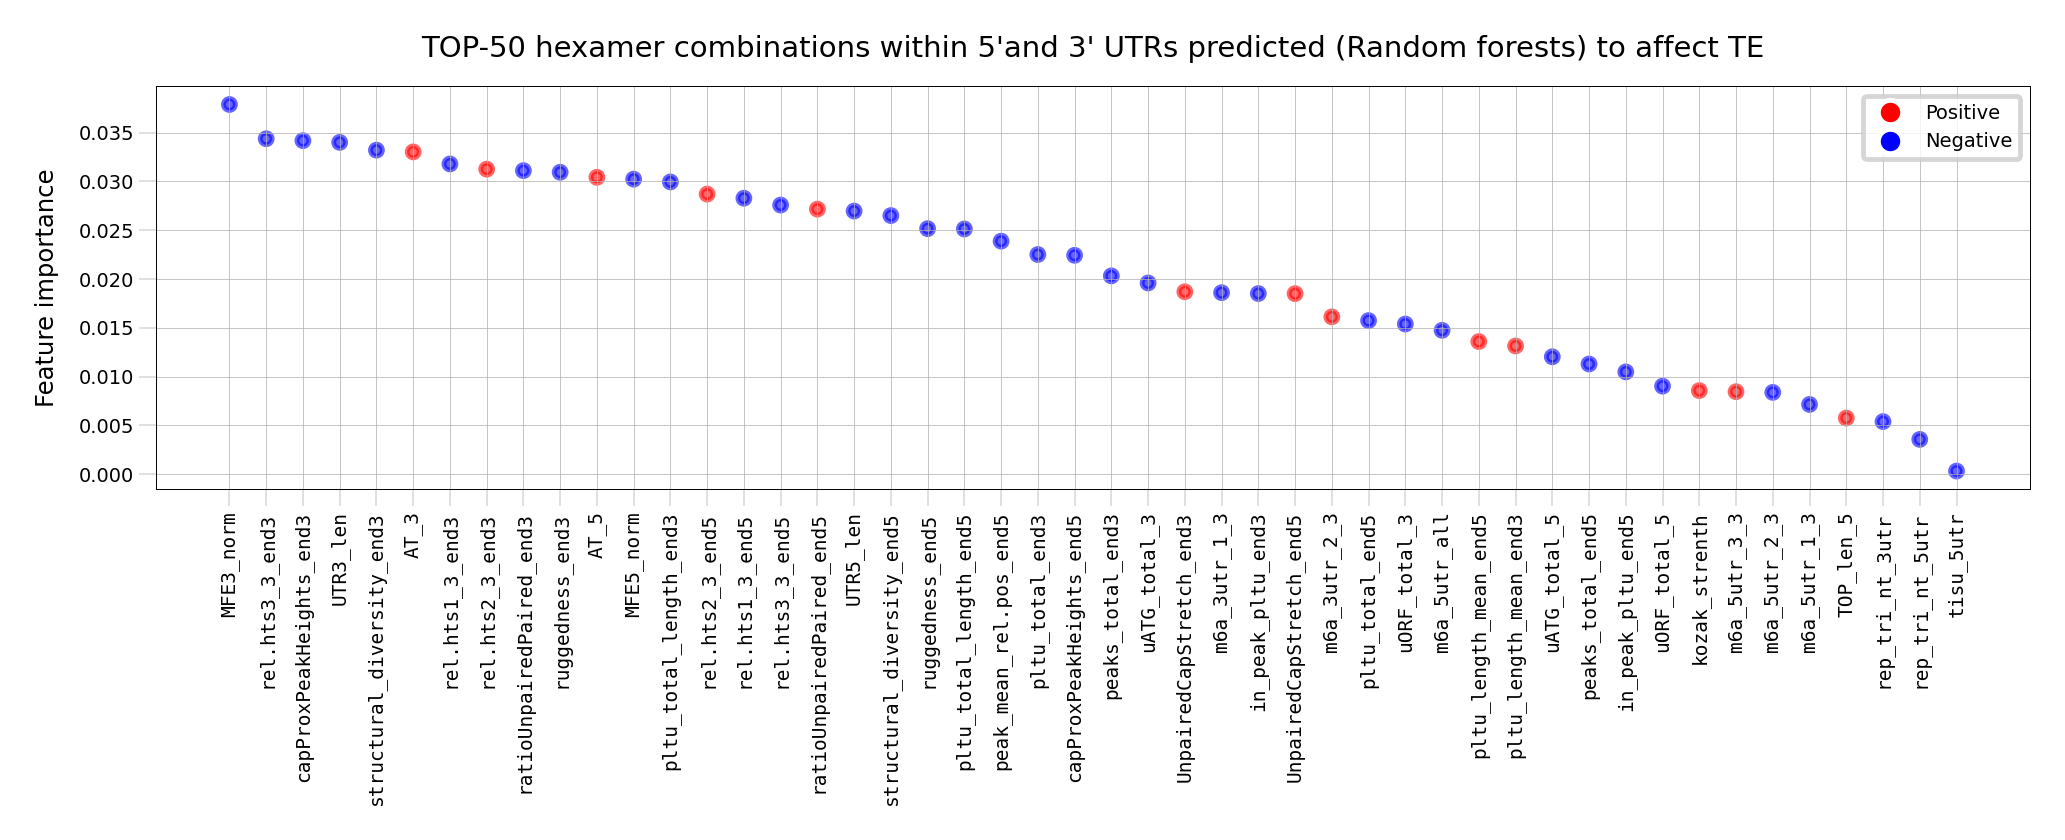

In [276]:
plt.figure(dpi=250)  # Adjust the figure size for better spacing
# Importance from model for last split
i=0

rf = eval(f'rf_reg_split{i}')
importances = rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

regulatory_feature_names = list(eval(f'sel_feat_by_stats_reg_split{i}'))

forest_importances = pd.Series(importances, index=regulatory_feature_names)
forest_importances = forest_importances.sort_values(ascending=False).head(100)

# Convert the Series to DataFrame for plotting
df = forest_importances.reset_index()
df.columns = ['Feature', 'Score']
df['FC'] = eval(f'mannWhit_UpperVsLower_reg_split{i}').loc[df['Feature'], 'FC'].values

# Plotting
fig, ax = plt.subplots(dpi=350, figsize=(6, 2.5), tight_layout=True)

# Colors based on the condition
colors = np.where(df['FC'] >  1, 'red', 'blue')  # 'red' for 'Positive', 'blue' for 'Negative'

# Scatter plot with custom colors
scatter = ax.scatter(df.index, df['Score'], c=colors, s=6, alpha=0.6)

# Setting x-ticks and labels
ax.set_xticks(df.index)
ax.set_xticklabels(df['Feature'], fontsize=3, rotation=90, fontname='Monospace')

# Setting plot title and labels
ax.set_title("TOP-50 hexamer combinations within 5'and 3' UTRs predicted (Random forests) to affect TE", fontsize=6)
ax.set_ylabel("Feature importance", fontsize=5)
ax.tick_params(axis='both', labelsize=4, width=0.05, pad=1)
ax.grid(True, linestyle='-', linewidth=0.15)
ax.set_xlim(left=-2, right=len(df) + 1)

# Thinner plot borders
for spine in ax.spines.values():
    spine.set_linewidth(0.2)

# Adding a legend
legend_labels = ['Positive' if fc > 1 else 'Negative' for fc in df['FC']]
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Positive',
                          markerfacecolor='red', markersize=5),
                   Line2D([0], [0], marker='o', color='w', label='Negative',
                          markerfacecolor='blue', markersize=5)]
ax.legend(handles=legend_elements, fontsize=4)

plt.show()

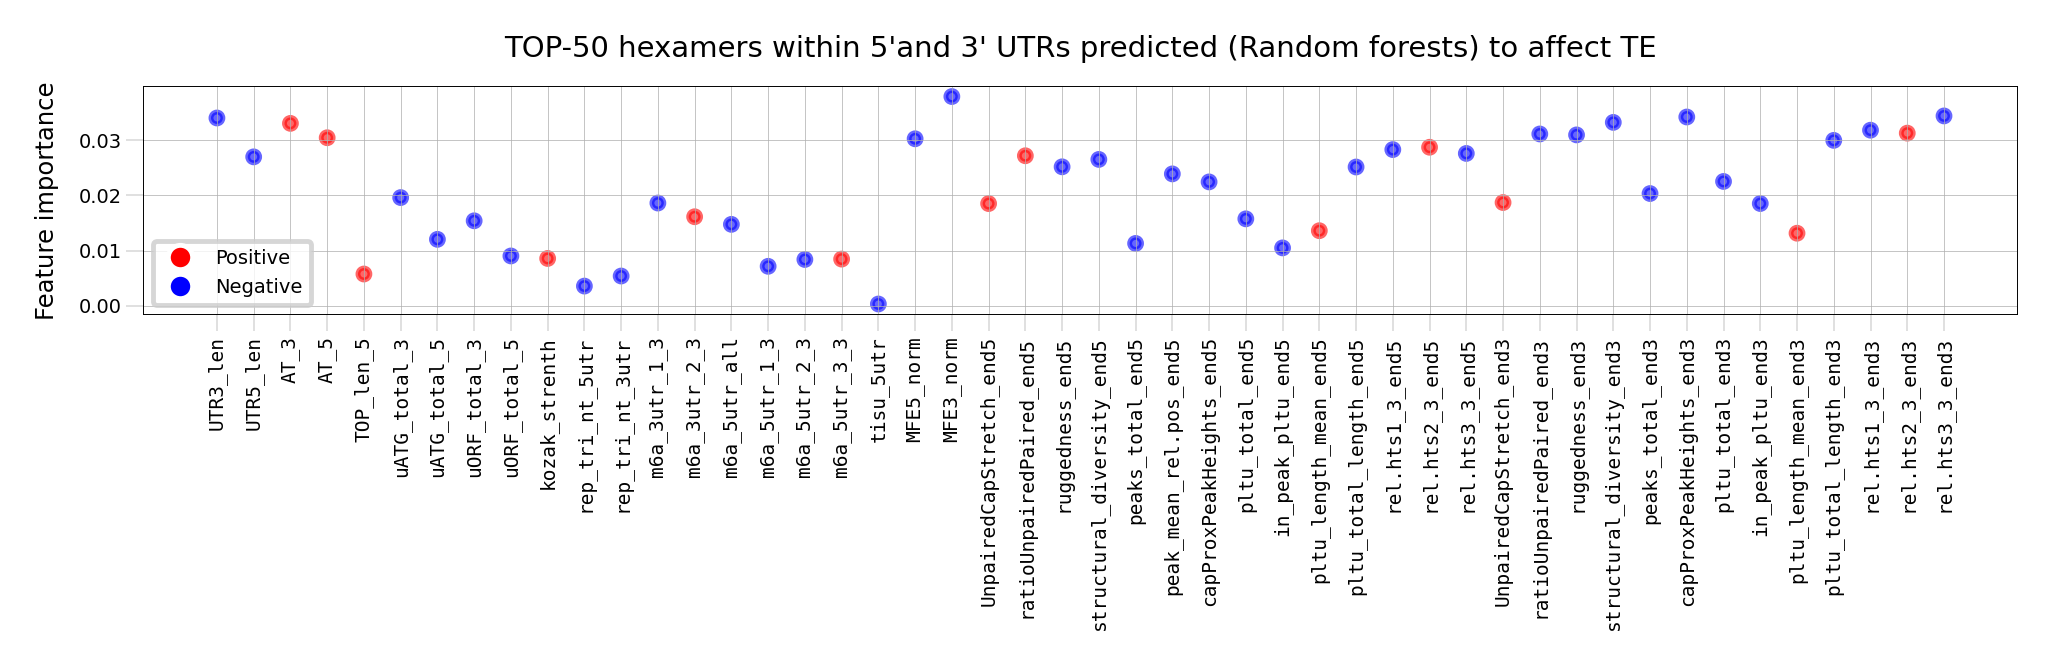

In [280]:
# Importance from model for last split
i=0

rf = eval(f'rf_reg_split{i}')
importances = rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

regulatory_feature_names = list(eval(f'sel_feat_by_stats_reg_split{i}'))

forest_importances = pd.Series(importances, index=regulatory_feature_names)

# Convert the Series to DataFrame for plotting
df = forest_importances.reset_index()
df.columns = ['Feature', 'Score']
df['FC'] = eval(f'mannWhit_UpperVsLower_reg_split{i}').loc[df['Feature'], 'FC'].values

# Plotting
fig, ax = plt.subplots(dpi=350, figsize=(6, 2), tight_layout=True)

# Colors based on the condition
colors = np.where(df['FC'] >  1, 'red', 'blue')  # 'red' for 'Positive', 'blue' for 'Negative'

# Scatter plot with custom colors
scatter = ax.scatter(df.index, df['Score'], c=colors, s=6, alpha=0.6)

# Setting x-ticks and labels
ax.set_xticks(df.index)
ax.set_xticklabels(df['Feature'], fontsize=3, rotation=90, fontname='Monospace')

# Setting plot title and labels
ax.set_title("TOP-50 hexamers within 5'and 3' UTRs predicted (Random forests) to affect TE", fontsize=6)
ax.set_ylabel("Feature importance", fontsize=5)
ax.tick_params(axis='both', labelsize=4, width=0.05, pad=1)
ax.grid(True, linestyle='-', linewidth=0.15)
ax.set_xlim(left=-2, right=len(df) + 1)

# Thinner plot borders
for spine in ax.spines.values():
    spine.set_linewidth(0.2)

# Adding a legend
legend_labels = ['Positive' if fc > 1 else 'Negative' for fc in df['FC']]
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Positive',
                          markerfacecolor='red', markersize=5),
                   Line2D([0], [0], marker='o', color='w', label='Negative',
                          markerfacecolor='blue', markersize=5)]
ax.legend(handles=legend_elements, fontsize=4)

plt.show()

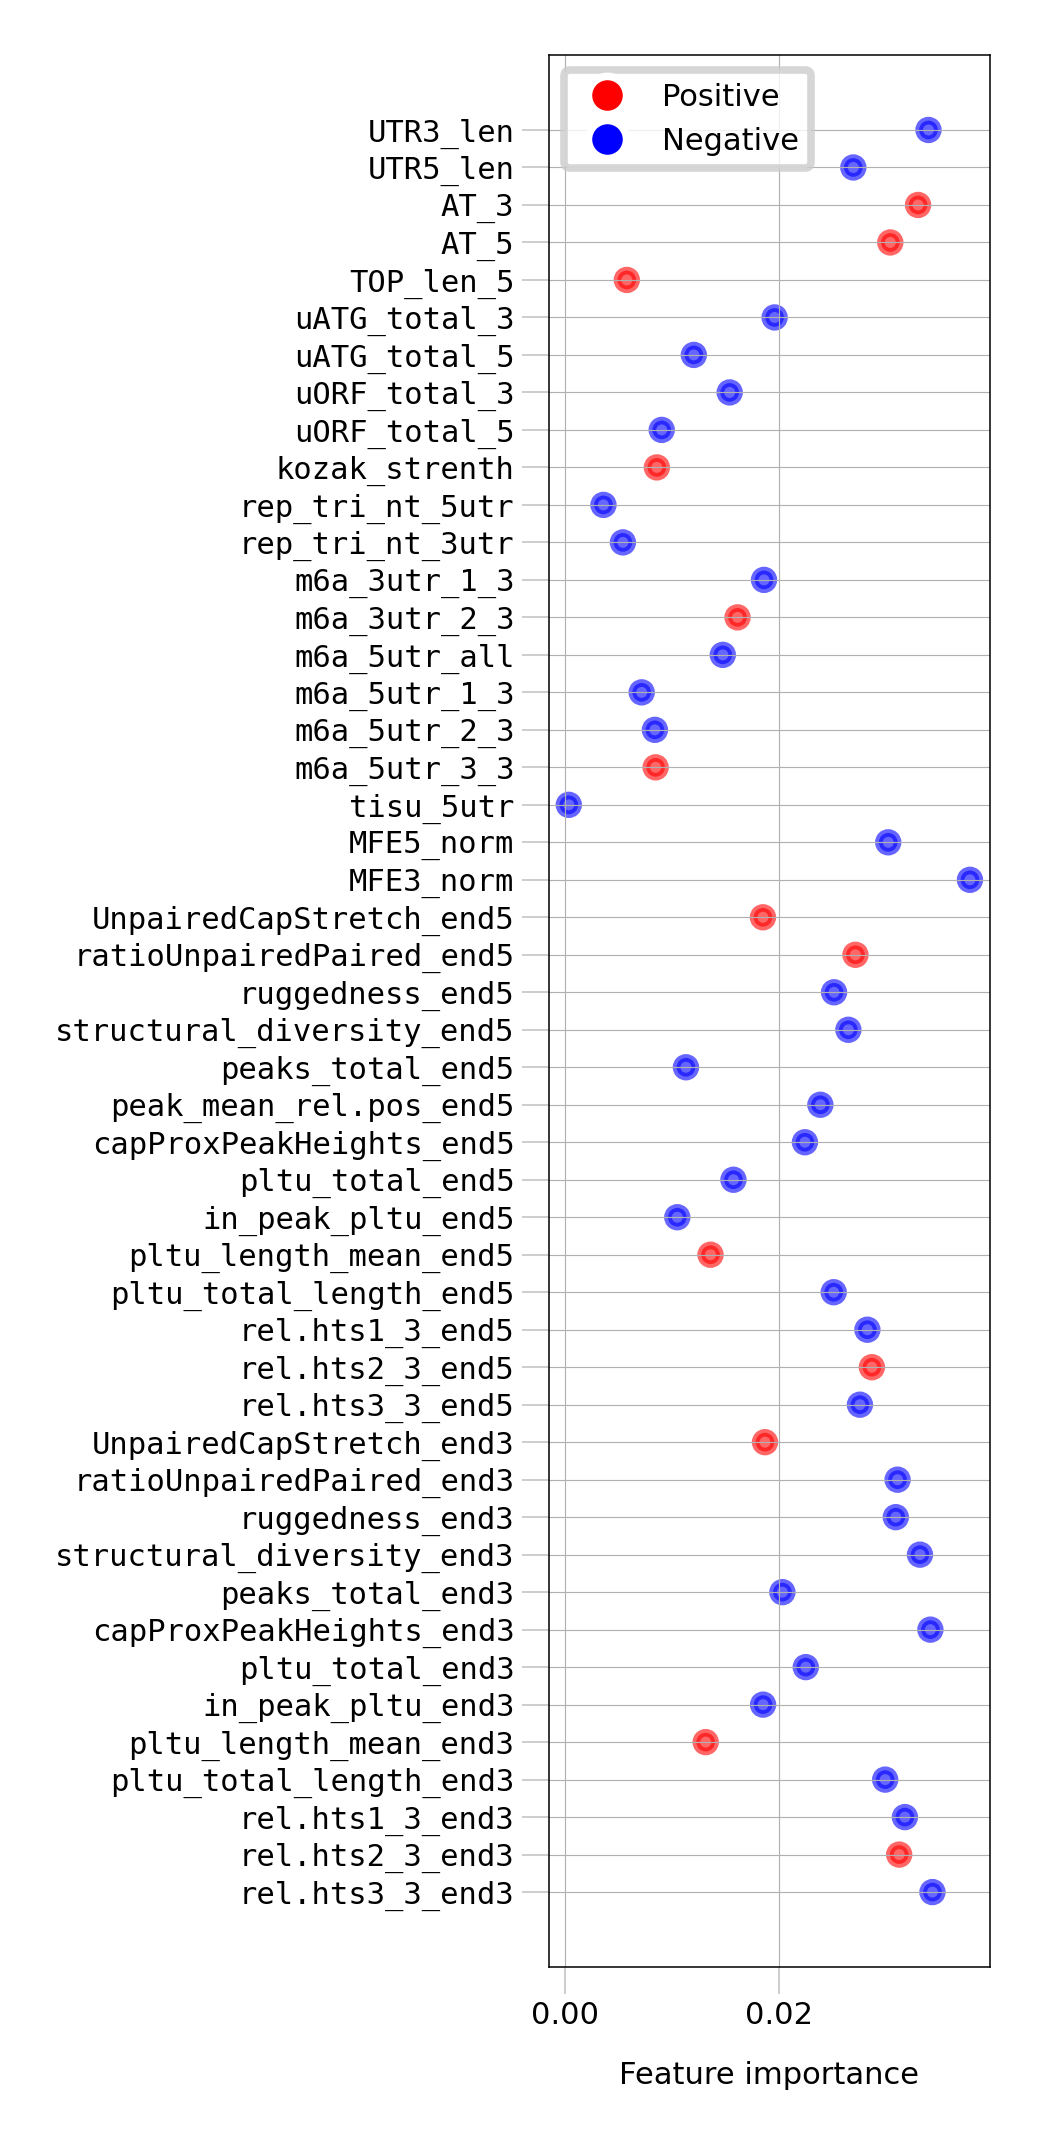

In [71]:
# Adjust the plot setup for a vertical (transposed) layout
fig, ax = plt.subplots(dpi=550, figsize=(2, 4), tight_layout=True)  # Adjusted figure size for better fit

# Colors based on the condition
colors = np.where(df['FC'] >  1, 'red', 'blue')  # 'red' for 'Positive', 'blue' for 'Negative'

# Scatter plot with custom colors (transposed)
scatter = ax.scatter(df['Score'], df.index, c=colors, s=6, alpha=0.6)

# Setting y-ticks and labels
ax.set_yticks(df.index)
ax.set_yticklabels(df['Feature'], fontsize=3, fontname='Monospace')
ax.invert_yaxis()  # Optionally invert the y-axis to have the highest importance on top

# Setting plot title and labels
# ax.set_title("TOP-50 hexamers within 5'and 3' UTRs predicted (Random forests) to affect TE", fontsize=6)
ax.set_xlabel("Feature importance", fontsize=4)
ax.tick_params(axis='both', labelsize=4, width=0.05, pad=1)
ax.grid(True, linestyle='-', linewidth=0.15)
ax.set_ylim(bottom=len(df) + 1, top=-2)  # Adjust the limits to match the inverted y-axis

# Thinner plot borders
for spine in ax.spines.values():
    spine.set_linewidth(0.2)

# Adding a legend
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Positive',
                          markerfacecolor='red', markersize=5),
                   Line2D([0], [0], marker='o', color='w', label='Negative',
                          markerfacecolor='blue', markersize=5)]
ax.legend(handles=legend_elements, fontsize=4, loc='upper left')  # Adjust legend location as needed

plt.show()

### Regulatory-features + 5'UTR & 3'UTR

In [194]:
# Defining lists to store metrics
rf_train_acc_n_l_ref = []
rf_train_roc_n_l_ref = []
rf_train_f1_n_l_ref = []
rf_test_acc_n_l_ref = []
rf_test_roc_n_l_ref = []
rf_test_f1_n_l_ref = []
rf_val_acc_n_l_ref = []
rf_val_roc_n_l_ref = []
rf_val_f1_n_l_ref = []

rf_train_acc_n_l_sel = []
rf_train_roc_n_l_sel = []
rf_train_f1_n_l_sel = []
rf_test_acc_n_l_sel = []
rf_test_roc_n_l_sel = []
rf_test_f1_n_l_sel = []
rf_val_acc_n_l_sel = []
rf_val_roc_n_l_sel = []
rf_val_f1_n_l_sel = []

rf_train_acc_n_l_sel_opt = []
rf_train_roc_n_l_sel_opt = []
rf_train_f1_n_l_sel_opt = []
rf_test_acc_n_l_sel_opt = []
rf_test_roc_n_l_sel_opt = []
rf_test_f1_n_l_sel_opt = []
rf_val_acc_n_l_sel_opt = []
rf_val_roc_n_l_sel_opt = []
rf_val_f1_n_l_sel_opt = []

model_hyper_param = []
fdr_and_stats_eq_n = []
corr_coeff_train = []
corr_coeff_test = []

for n_split in [0]: #range(N_SPLITS)
    
    # Spliting data set into train val and test sets
    #-----------------------------------------------
    rnd_seed = RANDOM_SEEDS[n_split]
    
    # numeric features
    X_train_n, X_new, y_train, y_new = train_test_split(X_n, y_categories, test_size=0.4 ,shuffle=True, stratify=y_categories, random_state=rnd_seed)
    X_test_n, X_val_n, y_test, y_val = train_test_split(X_new, y_new, test_size=0.5 ,shuffle=True, stratify=y_new, random_state=rnd_seed)

    X_train_n, X_new, y_train_num, y_new_num = train_test_split(X_n, y, test_size=0.4 ,shuffle=True, stratify=y_categories, random_state=rnd_seed)
    X_test_n, X_val_n, y_test_num, y_val_num = train_test_split(X_new, y_new_num, test_size=0.5 ,shuffle=True, stratify=y_new, random_state=rnd_seed)
    
    # # labled features
    # X_train_l, X_new, y_train, y_new = train_test_split(X_l, y_categories, test_size=0.4 ,shuffle=True, stratify=y_categories, random_state=rnd_seed)
    # X_test_l, X_val_l, y_test, y_val = train_test_split(X_new, y_new, test_size=0.5 ,shuffle=True, stratify=y_new, random_state=rnd_seed)

    # X_train_l, X_new, y_train_num, y_new_num = train_test_split(X_l, y, test_size=0.4 ,shuffle=True, stratify=y_categories, random_state=rnd_seed)
    # X_test_l, X_val_l, y_test_num, y_val_num = train_test_split(X_new, y_new_num, test_size=0.5 ,shuffle=True, stratify=y_new, random_state=rnd_seed)    
    
    #X_train_one_hot, X_new, y_train, y_new = train_test_split(X_one_hot, y_categories, test_size=0.4 ,shuffle=True, stratify=y_categories, random_state=rnd_seed)
    #X_test_one_hot, X_val_one_hot, y_test, y_val = train_test_split(X_new, y_new, test_size=0.5 ,shuffle=True, stratify=y_new, random_state=rnd_seed)
    
    #X_train_one_hot = X_train_one_hot.astype(int)
    #X_val_one_hot = X_val_one_hot.astype(int)
    #X_test_one_hot = X_test_one_hot.astype(int)

    
    feat_col_0 = X_train_n.columns

    X_n_kemrs_5_3_utr = pd.concat((X_n_kemrs_5utr,X_n_kemrs_3utr), axis=1)
    X_n_kemrs_5_3_utr = X_n_kemrs_3utr
    # X_n_kemrs_5_3_utr = X_n_kemrs_5_3_utr.loc[:, X_n_kemrs_5_3_utr.columns.str.slice(0, 6).isin(mmus_muscle_6mers)]
    
    #kmers-total    
    X_n_kemrs_5_3_prime_train, X_new, y_train, y_new = train_test_split(X_n_kemrs_5_3_utr, y_categories, test_size=0.4 ,shuffle=True, stratify=y_categories, random_state=rnd_seed)
    X_n_kemrs_5_3_prime_test, X_n_kemrs_5_3_prime_val, y_test, y_val = train_test_split(X_new, y_new, test_size=0.5 ,shuffle=True, stratify=y_new, random_state=rnd_seed)

    X_n_kemrs_5_3_prime_train, X_new, y_train_num, y_new_num = train_test_split(X_n_kemrs_5_3_utr, y, test_size=0.4 ,shuffle=True, stratify=y_categories, random_state=rnd_seed)
    X_n_kemrs_5_3_prime_test, X_n_kemrs_5_3_prime_val, y_test_num, y_val_num = train_test_split(X_new, y_new_num, test_size=0.5 ,shuffle=True, stratify=y_new, random_state=rnd_seed)
    
    # Main input
    print(f'\nPreprocessing split #{n_split}...\n')
    
    X_train_n_kmer = X_n_kemrs_5_3_prime_train

    X_val_n_kmer = X_n_kemrs_5_3_prime_val

    X_test_n_kmer = X_n_kemrs_5_3_prime_test

    feat_col_1 = X_train_n_kmer.columns

    feat_col = list(feat_col_0) + list(feat_col_1)
    # feat_col_all = list(feat_col_0) + list(feat_col_1) + list(X_train_l.columns)

    X_train_n = np.concatenate((X_train_n, X_train_n_kmer), axis=1)
    X_val_n = np.concatenate((X_val_n, X_val_n_kmer), axis=1)
    X_test_n = np.concatenate((X_test_n, X_test_n_kmer), axis=1)
    
    # Scaling the numerical features 
    np.seterr(invalid='ignore')
    X_train_n_scaled, X_val_n_scaled, X_test_n_scaled = scale_numerics(X_train_n, X_val_n, X_test_n, scaler_type='standard')
    
    # Imputting NaN
    imputer = KNNImputer(n_neighbors=4, weights="uniform")
    X_train_n_scaled = imputer.fit_transform(X_train_n_scaled)
    X_val_n_scaled = imputer.transform(X_val_n_scaled)
    X_test_n_scaled = imputer.transform(X_test_n_scaled)
    X_train_n = imputer.fit_transform(X_train_n)
    
    # Final numeric + labeld input dataset
    #X_train_n_l_scaled = np.concatenate((X_train_n_scaled, X_train_one_hot), axis=1)
    #X_val_n_l_scaled = np.concatenate((X_val_n_scaled, X_val_one_hot), axis=1)
    #X_test_n_l_scaled = np.concatenate((X_test_n_scaled, X_test_one_hot), axis=1)

    # X_train_n_l_scaled = np.concatenate((X_train_n_scaled, X_train_l), axis=1)
    # X_val_n_l_scaled = np.concatenate((X_val_n_scaled, X_val_l), axis=1)
    # X_test_n_l_scaled = np.concatenate((X_test_n_scaled, X_test_l), axis=1)

    X_train_n_l_scaled = np.copy(X_train_n_scaled)
    X_val_n_l_scaled = np.copy(X_val_n_scaled)
    X_test_n_l_scaled = np.copy(X_test_n_scaled)


    # 1)
    #-----------------------------------------------------    
    # Make reference ML model estimations on the numeric targets
    print(f"Initial evaluation for random split #{n_split}:\n")
    
    # Create an RF model
    rf = RandomForestClassifier(random_state=rnd_seed, n_jobs=-1) #class_weight='balanced', n_estimators=200, max_depth = None
    print("Reference Accuracies for Numerics")
    acc_train, acc_val, acc_test, roc_train, roc_val, roc_test, f1_train, f1_val, f1_test = acc_roc_f1_estimation(X_train=X_train_n_l_scaled, y_train=y_train,
                                                                                                                  X_val=X_val_n_l_scaled, y_val=y_val,
                                                                                                                  X_test=X_test_n_l_scaled, y_test=y_test,model=rf)
    
    rf_train_acc_n_l_ref.append(acc_train)
    rf_val_acc_n_l_ref.append(acc_val)
    rf_test_acc_n_l_ref.append(acc_test)
    rf_train_roc_n_l_ref.append(roc_train)
    rf_val_roc_n_l_ref.append(roc_val)
    rf_test_roc_n_l_ref.append(roc_test)
    rf_train_f1_n_l_ref.append(f1_train)
    rf_val_f1_n_l_ref.append(f1_val)
    rf_test_f1_n_l_ref.append(f1_test)
    #----------------------------------------------------- 
    # END 1)
    
    # 2)
    #----------------------------------------------------- 
    # Selecting numerical features with statistics
    X_train_n_l_scaled_sel, X_val_n_l_scaled_sel, X_test_n_l_scaled_sel, sel_feat_by_stats, sel_feat_by_stats_pval, mannWhit_UpperVsLower = feat_sel_by_stats(X_train_n, X_train_n_l_scaled,
    X_val_n_l_scaled,
    X_test_n_l_scaled,
    y_train, feat_col,
    5e-01)

    fdr_and_stats_eq = np.array_equal(fdrcorrection(sel_feat_by_stats_pval,
                                                        alpha=0.05,
                                                        method='indep',
                                                        is_sorted='False')[0], 
                                      (np.array(sel_feat_by_stats_pval) < 0.05))

    fdr_and_stats_eq_n.append(fdr_and_stats_eq)
    
    print(f'Before feature selection we got {X_train_n_l_scaled.shape[1]} features')
    print(f'After feature selection by stat we got {X_train_n_l_scaled_sel.shape[1]} features')

    # Evaluation of selected numerical features with statistics
    rf = RandomForestClassifier(random_state=rnd_seed) #class_weight='balanced', n_estimators=200, max_depth = None
    print()
    print("Accuracies for Numerics - Selected Features from statistics")
    acc_train, acc_val, acc_test, roc_train, roc_val, roc_test, f1_train, f1_val, f1_test  = acc_roc_f1_estimation(X_train=X_train_n_l_scaled_sel,
                                                                                                                  y_train=y_train,
                                                                                                                  X_val=X_val_n_l_scaled_sel, y_val=y_val,
                                                                                                                  X_test=X_test_n_l_scaled_sel, y_test=y_test,
                                                                                                                  model=rf)
    rf_train_acc_n_l_sel.append(acc_train)
    rf_val_acc_n_l_sel.append(acc_val)
    rf_test_acc_n_l_sel.append(acc_test)
    rf_train_roc_n_l_sel.append(roc_train)
    rf_val_roc_n_l_sel.append(roc_val)
    rf_test_roc_n_l_sel.append(roc_test)
    rf_train_f1_n_l_sel.append(f1_train)
    rf_val_f1_n_l_sel.append(f1_val)
    rf_test_f1_n_l_sel.append(f1_test)

    # MHPT
    rf = RandomForestClassifier(random_state=rnd_seed)
    
    n_est = hyperparameter_tunining(X_train=X_train_n_l_scaled_sel, 
                                    y_train=y_train, 
                                    model=rf)

    model_hyper_param.append([n_est])
    rf = RandomForestClassifier(n_estimators=n_est, random_state=rnd_seed)
    acc_train, acc_val, acc_test, roc_train, roc_val, roc_test, f1_train, f1_val, f1_test = acc_roc_f1_estimation(X_train=X_train_n_l_scaled_sel,
                                                                                                                  y_train=y_train,
                                                                                                                  X_val=X_val_n_l_scaled_sel, y_val=y_val,
                                                                                                                  X_test=X_test_n_l_scaled_sel, y_test=y_test,
                                                                                                                  model=rf)


    rf_train_acc_n_l_sel_opt.append(acc_train)
    rf_val_acc_n_l_sel_opt.append(acc_val)
    rf_test_acc_n_l_sel_opt.append(acc_test)
    rf_train_roc_n_l_sel_opt.append(roc_train)
    rf_val_roc_n_l_sel_opt.append(roc_val)
    rf_test_roc_n_l_sel_opt.append(roc_test)
    rf_train_f1_n_l_sel_opt.append(f1_train)
    rf_val_f1_n_l_sel_opt.append(f1_val)
    rf_test_f1_n_l_sel_opt.append(f1_test)


    # # Regression

    # y_train_num_scaled, y_train_num_pred, y_test_num_scaled, y_test_num_pred, corr_coeff_train_, corr_coeff_test_ = xgb_reg(X_train_=X_train_n_l_scaled_sel,
    #                                                                                                                         X_test_=X_test_n_l_scaled_sel,
    #                                                                                                                         y_train_num=y_train_num,
    #                                                                                                                         y_test_num=y_test_num)
    
    # #corr_coeff_train_, corr_coeff_test_ = xgb_reg(X_train_=X_train_n_l_scaled_sel, X_test_=X_test_n_l_scaled_sel,
    # #                                              y_train_num=y_train_num, y_test_num=y_test_num)
    
    # corr_coeff_train.append(corr_coeff_train_)

    # corr_coeff_test.append(corr_coeff_test_)
    # # End Regression    
    
    
    # saving rf model for each iteration
    globals()[f'rf_reg_kmer_split{n_split}'] = rf
    # globals()[f'class_val_ref{n_split}'] = class_val_ref
    # globals()[f'class_test_ref{n_split}'] = class_test_ref
    # globals()[f'class_val_sel{n_split}'] = class_val_sel
    # globals()[f'class_test_sel{n_split}'] = class_test_sel
    globals()[f'sel_feat_by_stats_reg_kmer_split{n_split}'] = sel_feat_by_stats
    globals()[f'sel_feat_by_stats_pval_reg_kmer_split{n_split}'] = sel_feat_by_stats_pval
    globals()[f'mannWhit_UpperVsLower_reg_kmer_split{n_split}'] = mannWhit_UpperVsLower
    
    # globals()[f'y_train_num_scaled_split{n_split}'] = y_train_num_scaled
    # globals()[f'y_train_num_pred_split{n_split}'] = y_train_num_pred
    # globals()[f'y_test_num_scaled_split{n_split}'] = y_test_num_scaled
    # globals()[f'y_test_num_pred_split{n_split}'] = y_test_num_pred
    # globals()[f'corr_coeff_train_split{n_split}'] = corr_coeff_train_
    # globals()[f'corr_coeff_test_split{n_split}'] = corr_coeff_test_

    # globals()[f'n_est{n_split}'] = n_est
    # globals()[f'model_hyper_param{n_split}'] = model_hyper_param

del X_n_kemrs_5_3_prime_train, X_new, y_train, y_new, X_n_kemrs_5_3_prime_test, X_n_kemrs_5_3_prime_val, y_test, y_val
# del X_train_n
del X_val_n, X_test_n
# del X_train_n_l_scaled
del X_val_n_l_scaled, X_test_n_l_scaled
del X_train_n_l_scaled_sel, X_val_n_l_scaled_sel, X_test_n_l_scaled_sel, sel_feat_by_stats, sel_feat_by_stats_pval, mannWhit_UpperVsLower


Preprocessing split #0...

Initial evaluation for random split #0:

Reference Accuracies for Numerics
Before feature selection we got 16436 features
After feature selection by stat we got 11279 features

Accuracies for Numerics - Selected Features from statistics


In [ ]:
# import pickle
# import os
# directory_path = '/Users/arielo/Desktop/utr_ai_desktop/RF_model_objects/Regulatory_features_5utr_3utr_(PP)'

# for n_split in range(10):
#     pickle.dump(globals()[f'rf_reg_kmer_split{n_split}'], open(os.path.join(directory_path, f'rf_reg_kmer_split{n_split}.pkl'), 'wb'))
#     pickle.dump(globals()[f'sel_feat_by_stats_reg_kmer_split{n_split}'], open(os.path.join(directory_path, f'sel_feat_by_stats_reg_kmer_split{n_split}.pkl'), 'wb'))
#     pickle.dump(globals()[f'sel_feat_by_stats_pval_reg_kmer_split{n_split}'], open(os.path.join(directory_path, f'sel_feat_by_stats_pval_reg_kmer_split{n_split}.pkl'), 'wb'))
#     pickle.dump(globals()[f'mannWhit_UpperVsLower_reg_kmer_split{n_split}'], open(os.path.join(directory_path, f'mannWhit_UpperVsLower_reg_kmer_split{n_split}.pkl'), 'wb'))
    
#     pickle.dump(globals()[f'y_train_num_scaled_split{n_split}'], open(os.path.join(directory_path, f'y_train_num_scaled_split{n_split}.pkl'), 'wb'))
#     pickle.dump(globals()[f'y_train_num_pred_split{n_split}'], open(os.path.join(directory_path, f'y_train_num_pred_split{n_split}.pkl'), 'wb'))
#     pickle.dump(globals()[f'y_test_num_scaled_split{n_split}'], open(os.path.join(directory_path, f'y_test_num_scaled_split{n_split}.pkl'), 'wb'))
#     pickle.dump(globals()[f'y_test_num_pred_split{n_split}'], open(os.path.join(directory_path, f'y_test_num_pred_split{n_split}.pkl'), 'wb'))
#     pickle.dump(globals()[f'corr_coeff_train__split{n_split}'], open(os.path.join(directory_path, f'corr_coeff_train_split{n_split}.pkl'), 'wb'))
    
#     pickle.dump(globals()[f'n_est{n_split}'], open(os.path.join(directory_path, f'n_est{n_split}.pkl'), 'wb'))
#     pickle.dump(globals()[f'model_hyper_param{n_split}'], open(os.path.join(directory_path, f'model_hyper_param{n_split}.pkl'), 'wb'))



In [ ]:
# import pickle
# import os
# # Directory where the files are stored
# # directory_path = '/Users/arielo/Desktop/utr_ai_desktop/RF_model_objects/Regulatory_features_5utr_3utr_(PP)'
# directory_path = '/Users/arielo/Desktop/utr_ai_desktop/RF_model_objects/Regulatory_features_5utr_3utr_(PP)'

# for n_split in range(10):
#     with open(os.path.join(directory_path, f'rf_reg_kmer_split{n_split}.pkl'), 'rb') as file:
#         globals()[f'rf_reg_kmer_split{n_split}'] = pickle.load(file)
#     with open(os.path.join(directory_path, f'sel_feat_by_stats_reg_kmer_split{n_split}.pkl'), 'rb') as file:
#         globals()[f'sel_feat_by_stats_reg_kmer_split{n_split}'] = pickle.load(file)
#     with open(os.path.join(directory_path, f'sel_feat_by_stats_pval_reg_kmer_split{n_split}.pkl'), 'rb') as file:
#         globals()[f'sel_feat_by_stats_pval_reg_kmer_split{n_split}'] = pickle.load(file)
#     with open(os.path.join(directory_path, f'mannWhit_UpperVsLower_reg_kmer_split{n_split}.pkl'), 'rb') as file:
#         globals()[f'mannWhit_UpperVsLower_reg_kmer_split{n_split}'] = pickle.load(file)
    
#     with open(os.path.join(directory_path, f'y_train_num_scaled_split{n_split}.pkl'), 'rb') as file:
#         globals()[f'y_train_num_scaled_split{n_split}'] = pickle.load(file)
#     with open(os.path.join(directory_path, f'y_train_num_pred_split{n_split}.pkl'), 'rb') as file:
#         globals()[f'y_train_num_pred_split{n_split}'] = pickle.load(file)
#     with open(os.path.join(directory_path, f'y_test_num_scaled_split{n_split}.pkl'), 'rb') as file:
#         globals()[f'y_test_num_scaled_split{n_split}'] = pickle.load(file)
#     with open(os.path.join(directory_path, f'y_test_num_pred_split{n_split}.pkl'), 'rb') as file:
#         globals()[f'y_test_num_pred_split{n_split}'] = pickle.load(file)
#     with open(os.path.join(directory_path, f'corr_coeff_train_split{n_split}.pkl'), 'rb') as file:
#         globals()[f'corr_coeff_train_split{n_split}'] = pickle.load(file)
#     with open(os.path.join(directory_path, f'corr_coeff_test_split{n_split}.pkl'), 'rb') as file:
#         globals()[f'corr_coeff_test_split{n_split}'] = pickle.load(file)

In [196]:
#Roc-AUC
print("Train Ref Roc n: ", np.average(rf_train_roc_n_l_ref))  
print("Val Ref Roc n: ", np.average(rf_val_roc_n_l_ref)) 
print("Test Ref Roc n: ", np.average(rf_test_roc_n_l_ref)) 
print('----------------------------------')
print("Train Sel Roc n: ", np.average(rf_train_roc_n_l_sel))   
print("Val Sel Roc n: ", np.average(rf_val_roc_n_l_sel))
print("Test Sel Roc n: ", np.average(rf_test_roc_n_l_sel)) 
print('----------------------------------')
print("Train Sel Opt Roc n: ", np.average(rf_train_roc_n_l_sel_opt))   
print("Val Sel Opt Roc n: ", np.average(rf_val_roc_n_l_sel_opt))
print("Test Sel Opt Roc n: ", np.average(rf_test_roc_n_l_sel_opt)) 

Train Ref Roc n:  0.9999273399762574
Val Ref Roc n:  0.8282382722282771
Test Ref Roc n:  0.8270698724426433
----------------------------------
Train Sel Roc n:  0.9999280955706057
Val Sel Roc n:  0.8221664679491859
Test Sel Roc n:  0.823040536632336
----------------------------------
Train Sel Opt Roc n:  0.9999505840290853
Val Sel Opt Roc n:  0.824413146287728
Test Sel Opt Roc n:  0.8243228300108537


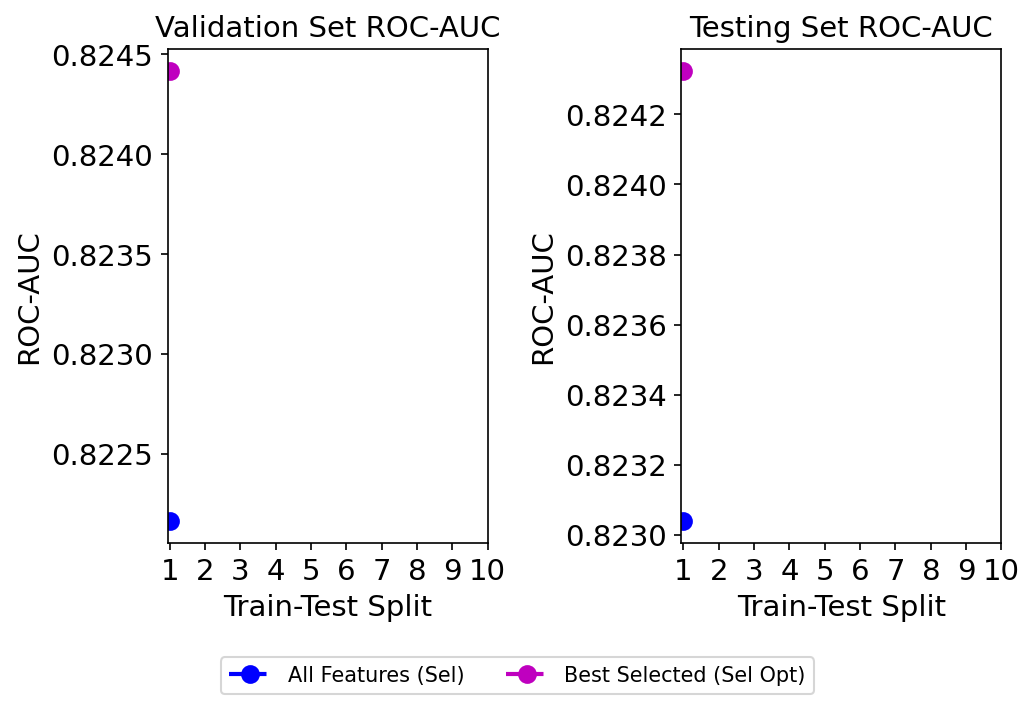

In [200]:
plt.figure(figsize=(7, 5), dpi=150)

# 1st Plot: Validation Set ROC-AUC
plt.subplot(1, 2, 1)
plt.plot(rf_val_roc_n_l_sel, 'b--', marker='o', markersize=8, linewidth=2)
plt.plot(rf_val_roc_n_l_sel_opt, 'm--', marker='o', markersize=8, linewidth=2)

plt.xlabel('Train-Test Split', fontsize=14)
plt.ylabel('ROC-AUC', fontsize=14)
plt.xticks(ticks=range(0, 10), labels=range(1, 11), fontsize=14)
plt.yticks(fontsize=14)
plt.title('Validation Set ROC-AUC', fontsize=14)


# 2nd Plot: Testing Set ROC-AUC
plt.subplot(1, 2, 2)
plt.plot(rf_test_roc_n_l_sel, 'b--', marker='o', markersize=8, linewidth=2)
plt.plot(rf_test_roc_n_l_sel_opt, 'm--', marker='o', markersize=8, linewidth=2)

plt.xlabel('Train-Test Split', fontsize=14)
plt.ylabel('ROC-AUC', fontsize=14)
plt.xticks(ticks=range(0, 10), labels=range(1, 11), fontsize=14)
plt.yticks(fontsize=14)
plt.title('Testing Set ROC-AUC', fontsize=14)


# Legend
plt.figlegend(
    ['All Features (Sel)', 'Best Selected (Sel Opt)'],
    loc='lower center',
    bbox_to_anchor=(0.5, 0.0),
    ncol=2
)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

TOP 50 6-mer selection

<Figure size 1600x1200 with 0 Axes>

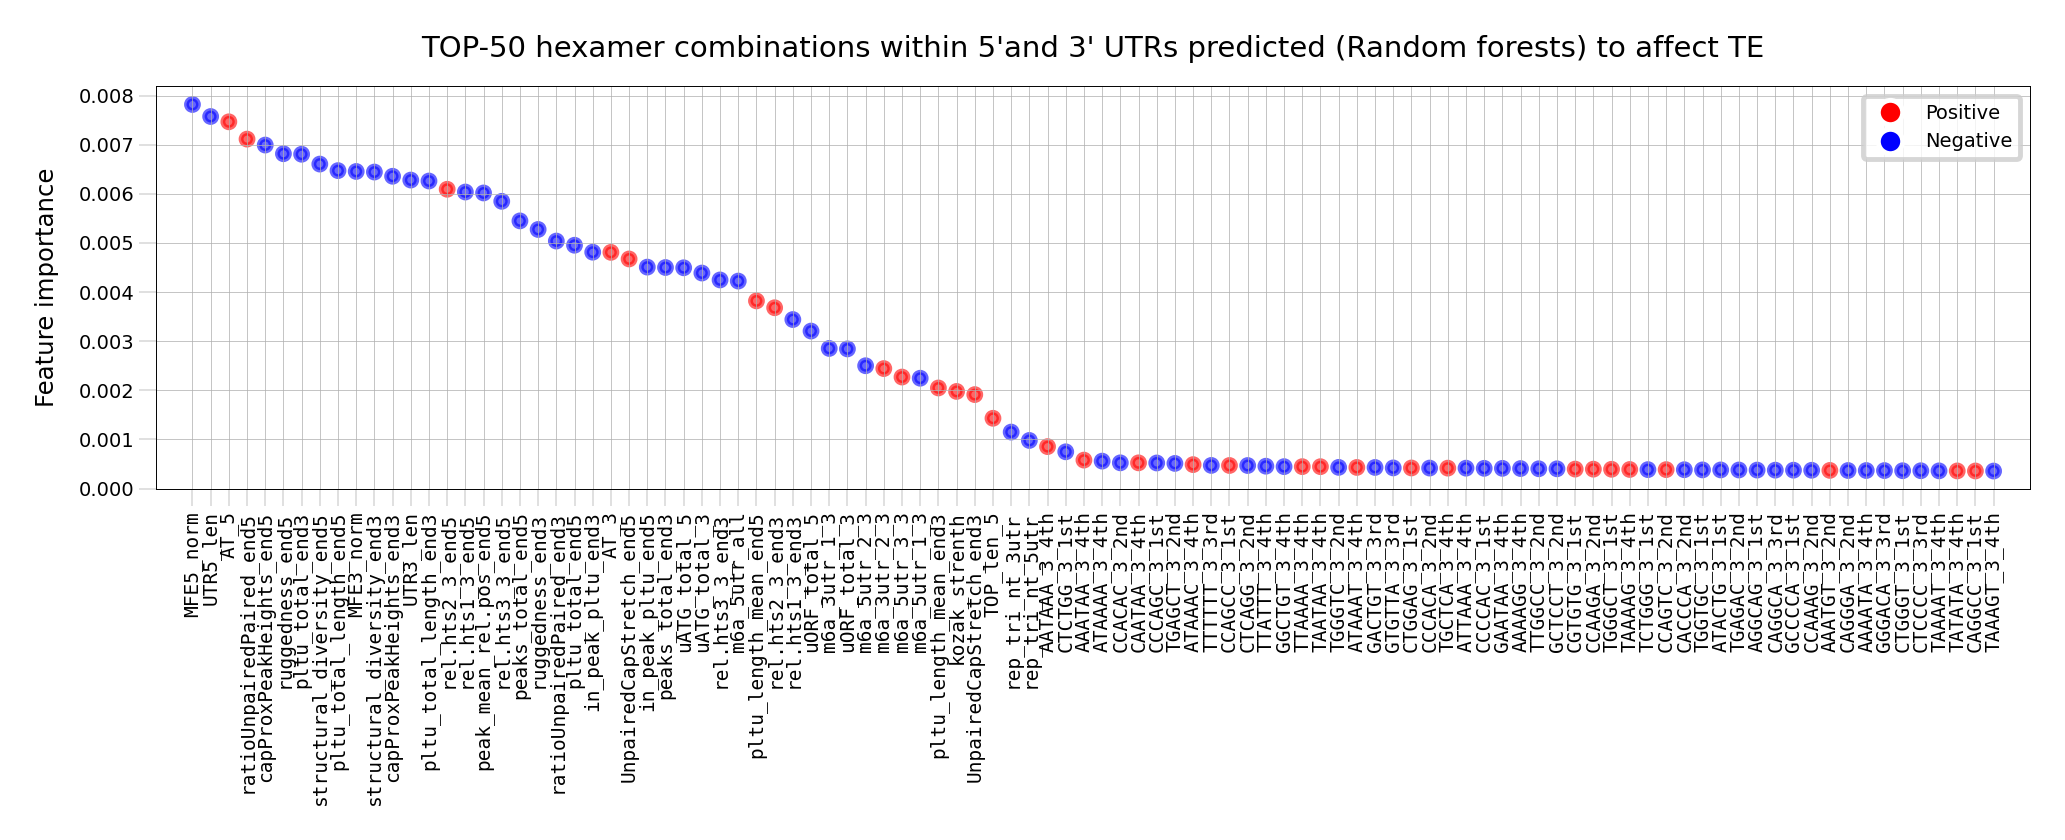

In [202]:
plt.figure(dpi=250)  # Adjust the figure size for better spacing
# Importance from model for last split
i=0

rf = eval(f'rf_reg_kmer_split{i}')
importances = rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

regulatory_feature_names = list(eval(f'sel_feat_by_stats_reg_kmer_split{i}'))

forest_importances = pd.Series(importances, index=regulatory_feature_names)
forest_importances = forest_importances.sort_values(ascending=False).head(100)

# Convert the Series to DataFrame for plotting
df = forest_importances.reset_index()
df.columns = ['Feature', 'Score']
df['FC'] = eval(f'mannWhit_UpperVsLower_reg_kmer_split{i}').loc[df['Feature'], 'FC'].values

# Plotting
fig, ax = plt.subplots(dpi=350, figsize=(6, 2.5), tight_layout=True)

# Colors based on the condition
colors = np.where(df['FC'] >  1, 'red', 'blue')  # 'red' for 'Positive', 'blue' for 'Negative'

# Scatter plot with custom colors
scatter = ax.scatter(df.index, df['Score'], c=colors, s=6, alpha=0.6)

# Setting x-ticks and labels
ax.set_xticks(df.index)
ax.set_xticklabels(df['Feature'], fontsize=3, rotation=90, fontname='Monospace')

# Setting plot title and labels
ax.set_title("TOP-50 hexamer combinations within 5'and 3' UTRs predicted (Random forests) to affect TE", fontsize=6)
ax.set_ylabel("Feature importance", fontsize=5)
ax.tick_params(axis='both', labelsize=4, width=0.05, pad=1)
ax.grid(True, linestyle='-', linewidth=0.15)
ax.set_xlim(left=-2, right=len(df) + 1)

# Thinner plot borders
for spine in ax.spines.values():
    spine.set_linewidth(0.2)

# Adding a legend
legend_labels = ['Positive' if fc > 1 else 'Negative' for fc in df['FC']]
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Positive',
                          markerfacecolor='red', markersize=5),
                   Line2D([0], [0], marker='o', color='w', label='Negative',
                          markerfacecolor='blue', markersize=5)]
ax.legend(handles=legend_elements, fontsize=4)

plt.show()

### Feat Combination

**Feature Combination: k-mer Architecture as Encoded Regulatory Logic**

In this analysis, we restrict the model to **k-mer–based sequence features only**, allowing us to interrogate how much translational behavior is encoded directly in primary nucleotide composition.

Rather than introducing explicit regulatory annotations, we let short sequence patterns (k-mers) serve as minimal regulatory units.

---

**Biological Rationale**

Short nucleotide motifs are the fundamental building blocks of post-transcriptional regulation.  
They can represent:

- Core elements of RNA-binding protein recognition sites
- Determinants of local RNA structure propensity
- Sequence contexts influencing ribosome scanning
- Signals affecting mRNA stability and decay
- Evolutionarily conserved micro-regulatory elements

Even without explicit annotation, enriched k-mers may reflect **latent regulatory grammar** embedded in the sequence.

---

**Evolutionary Perspective**

UTRs evolve under selective pressures that balance:

- Efficient translation
- Regulatory responsiveness
- Context-dependent modulation
- Cellular economy and robustness

If translational states are biologically meaningful, then selection should leave detectable imprints at the level of:

- Motif frequency
- Motif combinations
- Region-specific sequence bias

By modeling k-mers alone, we test whether translational phenotypes are associated with **evolutionarily encoded motif architectures**, rather than higher-order engineered features.

---

**Region-Specific vs Integrated Architecture**

We compare three configurations:

1. 5′UTR k-mers  
2. 3′UTR k-mers  
3. Combined 5′ + 3′ k-mers  

This allows us to evaluate whether:

- Regulatory signals are concentrated in initiation-proximal regions
- Stability-associated logic dominates in 3′UTRs
- Or whether coordinated 5′–3′ motif architecture reflects integrated regulatory programs

---

**Conceptual Framing**

If classification or regression performance emerges from k-mers alone, it suggests that:

- Translational regulation is deeply embedded in short sequence logic
- Motif grammar encodes discrete regulatory states
- Evolution has sculpted UTR composition in a non-random, functionally structured manner

This approach provides a biologically grounded baseline for understanding how much regulatory information resides directly in nucleotide patterns.

In [89]:
top50_kmers_5_1st = pd.read_csv("../kmers/top50_kmers_5_1st.csv")
top50_kmers_5_2nd = pd.read_csv("../kmers/top50_kmers_5_2nd.csv")
top50_kmers_3_1st = pd.read_csv("../kmers/top50_kmers_3_1st.csv")
top50_kmers_3_2nd = pd.read_csv("../kmers/top50_kmers_3_2nd.csv")
top50_kmers_3_3rd = pd.read_csv("../kmers/top50_kmers_3_3rd.csv")
top50_kmers_3_4th = pd.read_csv("../kmers/top50_kmers_3_4th.csv")

# top50_kmers_5_1st = pd.read_csv("/Users/arielo/Desktop/utr_ai_desktop/kmers/top50_kmers_5_1st.csv").head(10)
# top50_kmers_5_2nd = pd.read_csv("/Users/arielo/Desktop/utr_ai_desktop/kmers/top50_kmers_5_2nd.csv").head(10)
# top50_kmers_3_1st = pd.read_csv("/Users/arielo/Desktop/utr_ai_desktop/kmers/top50_kmers_3_1st.csv").head(10)
# top50_kmers_3_2nd = pd.read_csv("/Users/arielo/Desktop/utr_ai_desktop/kmers/top50_kmers_3_2nd.csv").head(10)
# top50_kmers_3_3rd = pd.read_csv("/Users/arielo/Desktop/utr_ai_desktop/kmers/top50_kmers_3_3rd.csv").head(10)
# top50_kmers_3_4th = pd.read_csv("/Users/arielo/Desktop/utr_ai_desktop/kmers/top50_kmers_3_4th.csv").head(10)

top_kmers_5_1st2nd = pd.concat([top50_kmers_5_1st, top50_kmers_5_2nd], axis=0)
top_kmers_3_1st2nd = pd.concat([top50_kmers_3_1st,top50_kmers_3_2nd], axis=0)
top_kmers_3_3rd4th = pd.concat([top50_kmers_3_3rd,top50_kmers_3_4th], axis=0)

In [ ]:
# comb_df = pd.concat([X_n[regulatory_feature_names],
#                      X_n_kemrs_5utr[top_kmers_5],
#                      X_n_kemrs_3utr[top_kmers_3_1st2nd],
#                      X_n_kemrs_3utr[top_kmers_3_3rd4th]],
#                     axis=1)
# # del X_n_kemrs_5utr
# # del X_n_kemrs_3utr

In [335]:
# comb_df = X_n[regulatory_feature_names]

In [113]:
comb_df = pd.concat([X_n_kemrs_5utr[top_kmers_5_1st2nd['Feature']],
                    X_n_kemrs_3utr[top_kmers_3_1st2nd['Feature']],
                    X_n_kemrs_3utr[top_kmers_3_3rd4th['Feature']]],
                    axis=1)
# del X_n_kemrs_5utr
# del X_n_kemrs_3utr

In [ ]:
# comb_df = pd.concat([X_n_kemrs_5utr[top_kmers_5_1st],
#                     X_n_kemrs_3utr[top_kmers_3_4th]],
#                     axis=1)

In [115]:
# Seperating X to sub dataframes by type
# For numerical features
X_n_comb = comb_df.select_dtypes(include=[np.number, 'float64', 'int64']).copy()
# # For categorical features
# X_c = comb_df.select_dtypes(include=['object', 'category']).copy()
# # X_c = X_c.drop(['TIF_name', 'seq3UTR', 'seq5UTR'], axis=1)    

# # Transfroming categorical data to labels
# X_l = label_encoder(X_c)

# # Transforming label data to one-hot-encoding
# X_one_hot, col_one_hot, num_cat  = from_label_to_one_hot(X_l)

y = DF_PP['TE3']

# TIF_len = DF[['TIF_name','TIF_len']]
# dot_bracket = DF[['MFE3_dotBracket','MFE5_dotBracket']]

# Quantile-Based Categorization of y
y_quantiles = np.quantile(y, N_QUANTILES)
# array of discrit categories of TE
# The category number starts at 0 and increases by one for each subsequent quantile range
y_categories = np.zeros_like(y)
category = 0
for n_quantile in range(1, len(y_quantiles)):
    temp_cat = (y > y_quantiles[n_quantile-1]) & (y <= y_quantiles[n_quantile]) 
    y_categories += temp_cat * category
    category+=1

The bellow cell used to make small combinations data.frame but it reconfigure in the main loop

In [ ]:
# def scale_and_multiply(data, combination, scaler):
#     # Select the subset of data for the current combination
#     subset = data[list(combination)]
    
#     # Scale the subset
#     scaled_subset = scaler.fit_transform(subset)
#     # Calculate the product of scaled values
#     product = np.prod(scaled_subset, axis=1)
    
#     return product

# # Define the feature selection based on statistical test
# def feature_selection_based_on_test(new_feature, y_train, criteria):
#     # Example with a simple test - this part should include your own statistical tests
#     stat, p_value = kruskal(new_feature[y_train == 0], new_feature[y_train == 1], new_feature[y_train == 2])
#     return p_value < criteria, p_value

# comb_n = 3
# data = X_n_comb  
# y_categories = y_categories  
# criteria = 1e-20  

# # Choose the scaler type
# scaler_type = 'minmax'
# if scaler_type == 'standard':
#     scaler = StandardScaler()
# elif scaler_type == 'minmax':
#     scaler = MinMaxScaler(feature_range=(0.01, 1))
# elif scaler_type == 'robust':
#     scaler = RobustScaler()
# else:
#     raise ValueError("Unsupported scaler type")

# # Generate combinations of columns
# combinations = list(itertools.combinations(data.columns, comb_n))

# # Use a list to collect all series
# new_features = []

# for comb in tqdm(combinations):
#     # Scale and multiply the columns in the combination
#     new_feature = scale_and_multiply(data, comb, scaler)
    
#     # Perform feature selection
#     keep_feature, p_value = feature_selection_based_on_test(new_feature, y_categories.values, criteria)
    
#     if keep_feature:
#         new_col_name = ",".join(comb)
#         new_features.append(pd.Series(new_feature, name=new_col_name))

# # Concatenate all the selected features into one DataFrame
# X_n_comb_sel = pd.concat(new_features, axis=1)

# # print(f'Selected features: {X_n_comb_sel.columns.tolist()}')
# X_n_comb_sel

In [117]:
def comb_multiply(data, combination):
    # Select the subset of data for the current combination
    subset = data[list(combination)]
    
    # Calculate the product of scaled values
    product = np.prod(subset, axis=1)
    
    return product

# Define the feature selection based on statistical test
def feature_selection_kruskal(new_feature, y_train, criteria):
    # Example with a simple test - this part should include your own statistical tests
    stat, p_value = kruskal(new_feature[y_train == 0], new_feature[y_train == 1], new_feature[y_train == 2])
    return p_value < criteria, p_value


In [119]:
# # Example DataFrame with column names
# df = pd.DataFrame(columns=["col1", "col2", "col3", ..., "col61"])  # Replace ... with other column names

# # Example NumPy array
# arr = np.random.rand(3757, 61)

# # Create a dictionary that maps column names to their indices
# column_indices = {name: index for index, name in enumerate(df.columns)}

# Modify the function to work with the array using column indices
def comb_multiply_array(array, combination, col_indices):
    # Convert column names in the combination to indices
    subset_indices = [col_indices[name] for name in combination]
    
    # Select the subset of the array for the current combination
    subset = array[:, subset_indices]
    
    # Calculate the product of scaled values
    product = np.prod(subset, axis=1)
    
    return product

# # Example usage:
# combination = ['col1', 'col5', 'col10']  # specify your actual combination
# result = comb_multiply_array(arr, combination, column_indices)

In [121]:
def comb_operate_array(array, combination, col_indices, operation=np.sum):
    # Convert column names in the combination to indices
    subset_indices = [col_indices[name] for name in combination]
    
    # Select the subset of the array for the current combination
    subset = array[:, subset_indices]
    
    # Apply the specified operation to the subset
    result = operation(subset, axis=1)
    
    return result

In [123]:
import os
## Defining lists to store metrics
rf_train_acc_n_l_ref = []
rf_train_roc_n_l_ref = []
rf_train_f1_n_l_ref = []
rf_test_acc_n_l_ref = []
rf_test_roc_n_l_ref = []
rf_test_f1_n_l_ref = []
rf_val_acc_n_l_ref = []
rf_val_roc_n_l_ref = []
rf_val_f1_n_l_ref = []

rf_train_acc_n_l_sel = []
rf_train_roc_n_l_sel = []
rf_train_f1_n_l_sel = []
rf_test_acc_n_l_sel = []
rf_test_roc_n_l_sel = []
rf_test_f1_n_l_sel = []
rf_val_acc_n_l_sel = []
rf_val_roc_n_l_sel = []
rf_val_f1_n_l_sel = []

rf_train_acc_n_l_sel_opt = []
rf_train_roc_n_l_sel_opt = []
rf_train_f1_n_l_sel_opt = []
rf_test_acc_n_l_sel_opt = []
rf_test_roc_n_l_sel_opt = []
rf_test_f1_n_l_sel_opt = []
rf_val_acc_n_l_sel_opt = []
rf_val_roc_n_l_sel_opt = []
rf_val_f1_n_l_sel_opt = []

model_hyper_param = []
fdr_and_stats_eq_n = []
corr_coeff_train = []
corr_coeff_test = []

p_value_list = []
keep_feature_list = []


for n_split in [0]: #N_SPLITS range(10)
    
    # Spliting data set into train val and test sets
    #-----------------------------------------------
    rnd_seed = RANDOM_SEEDS[n_split]

    # numeric features
    X_train_n, X_new, y_train, y_new = train_test_split(X_n_comb, y_categories, test_size=0.4 ,shuffle=True, stratify=y_categories, random_state=rnd_seed)
    X_test_n, X_val_n, y_test, y_val = train_test_split(X_new, y_new, test_size=0.5 ,shuffle=True, stratify=y_new, random_state=rnd_seed)
    # 
    X_train_n, X_new, y_train_num, y_new_num = train_test_split(X_n_comb, y, test_size=0.4 ,shuffle=True, stratify=y_categories, random_state=rnd_seed)
    X_test_n, X_val_n, y_test_num, y_val_num = train_test_split(X_new, y_new_num, test_size=0.5 ,shuffle=True, stratify=y_new, random_state=rnd_seed)

    
#     # labled features
#     X_train_l, X_new, y_train, y_new = train_test_split(X_l, y_categories, test_size=0.4 ,shuffle=True, stratify=y_categories, random_state=rnd_seed)
#     X_test_l, X_val_l, y_test, y_val = train_test_split(X_new, y_new, test_size=0.5 ,shuffle=True, stratify=y_new, random_state=rnd_seed)
    
#     X_train_one_hot, X_new, y_train, y_new = train_test_split(X_one_hot, y_categories, test_size=0.4 ,shuffle=True, stratify=y_categories, random_state=rnd_seed)
#     X_test_one_hot, X_val_one_hot, y_test, y_val = train_test_split(X_new, y_new, test_size=0.5 ,shuffle=True, stratify=y_new, random_state=rnd_seed)
    
#     X_train_one_hot = X_train_one_hot.astype(int)
#     X_val_one_hot = X_val_one_hot.astype(int)
#     X_test_one_hot = X_test_one_hot.astype(int)
    
    # Scaling the numerical features 
    X_train_n_scaled, X_val_n_scaled, X_test_n_scaled = scale_numerics(X_train_n, X_val_n, X_test_n, scaler_type='minmax')
    
    # Imputting NaN
    imputer = KNNImputer(n_neighbors=4, weights="uniform")
    X_train_n_scaled = imputer.fit_transform(X_train_n_scaled)
    X_val_n_scaled = imputer.transform(X_val_n_scaled)
    X_test_n_scaled = imputer.transform(X_test_n_scaled)
    # X_train_n = imputer.fit_transform(X_train_n)
    
    # # Final numeric + labeld input dataset
    # X_train_n_l_scaled = np.concatenate((X_train_n_scaled, X_train_one_hot), axis=1)
    # X_val_n_l_scaled = np.concatenate((X_val_n_scaled, X_val_one_hot), axis=1)
    # X_test_n_l_scaled = np.concatenate((X_test_n_scaled, X_test_one_hot), axis=1)
    
    # # Final numeric + labeld input dataset
    # X_train_n_l_scaled = X_train_n_scaled
    # X_val_n_l_scaled = X_val_n_scaled
    # X_test_n_l_scaled = X_test_n_scaled

    # 0)
    #_____________________________________________________
    # Make combinations dataset
    print("making combination... only those that pass creteria")
    feat_col = X_train_n.columns
    combinations = list(itertools.combinations(feat_col, 3))

    # Create a dictionary that maps column names to their indices
    column_indices = {name: index for index, name in enumerate(X_n_comb.columns)}

    # Use a list to collect all series
    new_features_train = []
    new_features_val = []
    new_features_test = []
    criteria = 1e-9

    file_path = f"combined_features_{n_split}.pkl"
    if os.path.exists(file_path):
        # Optionally load the saved features if you want to reuse them
        with open(file_path, 'rb') as file:
            X_n_comb_train, X_n_comb_val, X_n_comb_test, feat_col_comb = pickle.load(file)
    else:
        for comb in tqdm(combinations):
            # multiply the columns in the combination
            new_feature = comb_multiply_array(X_train_n_scaled, comb, column_indices)
            # new_feature = comb_operate_array(X_train_n_scaled, comb, column_indices, operation=np.sum)
    
            # Perform feature selection
            keep_feature, p_value = feature_selection_kruskal(new_feature, y_train.values, criteria)
            p_value_list.append(p_value)
            keep_feature_list.append(keep_feature)
        
            if keep_feature:
                new_col_name = ",".join(comb)
                new_features_train.append(pd.Series(new_feature, name=new_col_name))
                
                new_feature = comb_multiply_array(X_val_n_scaled, comb, column_indices)
                # new_feature = comb_operate_array(X_val_n_scaled, comb, column_indices, operation=np.sum)
                new_features_val.append(pd.Series(new_feature, name=new_col_name))
                
                new_feature = comb_multiply_array(X_test_n_scaled, comb, column_indices)
                # new_feature = comb_operate_array(X_test_n_scaled, comb, column_indices, operation=np.sum)
                new_features_test.append(pd.Series(new_feature, name=new_col_name))
    
        # Concatenate all the selected features into one DataFrame
        X_n_comb_train = pd.concat(new_features_train, axis=1)
        X_n_comb_val = pd.concat(new_features_val, axis=1)
        X_n_comb_test = pd.concat(new_features_test, axis=1)
    
        feat_col_comb = X_n_comb_train.columns
        
        X_n_comb_train = X_n_comb_train.to_numpy()
        X_n_comb_val = X_n_comb_val.to_numpy()
        X_n_comb_test = X_n_comb_test.to_numpy()
    
        file_path = f"combined_features_{n_split}.pkl"
        with open(file_path, 'wb') as file:
            pickle.dump((X_n_comb_train, X_n_comb_val, X_n_comb_test, feat_col_comb), file)

    
    # 1)
    #-----------------------------------------------------    
    # Make reference ML model estimations on the numeric targets
    print(f"Initial evaluation for random split #{n_split}:\n")
    
    # Create an RF model
    rf = RandomForestClassifier(random_state=rnd_seed, n_jobs=-1) #class_weight='balanced', n_estimators=100, max_depth = None
    print("Reference Accuracies for Numerics")
    acc_train, acc_val, acc_test, roc_train, roc_val, roc_test, f1_train, f1_val, f1_test = acc_roc_f1_estimation(X_train=X_n_comb_train, y_train=y_train,
                                                                                                                  X_val=X_n_comb_val, y_val=y_val,
                                                                                                                  X_test=X_n_comb_test, y_test=y_test,model=rf)
    
    rf_train_acc_n_l_ref.append(acc_train)
    rf_val_acc_n_l_ref.append(acc_val)
    rf_test_acc_n_l_ref.append(acc_test)
    rf_train_roc_n_l_ref.append(roc_train)
    rf_val_roc_n_l_ref.append(roc_val)
    rf_test_roc_n_l_ref.append(roc_test)
    rf_train_f1_n_l_ref.append(f1_train)
    rf_val_f1_n_l_ref.append(f1_val)
    rf_test_f1_n_l_ref.append(f1_test)
    #----------------------------------------------------- 
    # END 1)
    
    # # 2)
    # #----------------------------------------------------- 
    # Selecting numerical features with statistics
    X_n_comb_train_sel, X_n_comb_val_sel, X_n_comb_test_sel, sel_feat_by_stats, sel_feat_by_stats_pval, mannWhit_UpperVsLower = feat_sel_by_stats(X_n_comb_train, X_n_comb_train,
    X_n_comb_val,
    X_n_comb_test,
    y_train, feat_col_comb,
    1e-9)

     
    # print(f'Before feature selection we got {X_n_comb_train.shape[1]} features')
    # print(f'After feature selection by stat we got {X_n_comb_train_sel.shape[1]} features')

    # # Evaluation of selected numerical features with statistics
    # rf = RandomForestClassifier(random_state=rnd_seed) # class_weight='balanced', n_estimators=100, max_depth = None
    # print()
    # print("Accuracies for Numerics - Selected Features from statistics")
    # acc_train, acc_val, acc_test, roc_train, roc_val, roc_test, f1_train, f1_val, f1_test = acc_roc_f1_estimation(X_train=X_n_comb_train_sel,
    #                                                                                                               y_train=y_train,
    #                                                                                                               X_val=X_n_comb_val_sel, y_val=y_val,
    #                                                                                                               X_test=X_n_comb_test_sel, y_test=y_test,
    #                                                                                                               model=rf)
    # rf_train_acc_n_l_sel.append(acc_train)
    # rf_val_acc_n_l_sel.append(acc_val)
    # rf_test_acc_n_l_sel.append(acc_test)
    # rf_train_roc_n_l_sel.append(roc_train)
    # rf_val_roc_n_l_sel.append(roc_val)
    # rf_test_roc_n_l_sel.append(roc_test)
    # rf_train_f1_n_l_sel.append(f1_train)
    # rf_val_f1_n_l_sel.append(f1_val)
    # rf_test_f1_n_l_sel.append(f1_test)

    # # MHPT
    # rf = RandomForestClassifier(random_state=rnd_seed)
    
    # n_est = hyperparameter_tunining(X_train=X_n_comb_train_sel, 
    #                                 y_train=y_train, 
    #                                 model=rf)

    # model_hyper_param.append([n_est])
    # rf = RandomForestClassifier(n_estimators=n_est, random_state=rnd_seed)
    # acc_train, acc_val, acc_test, roc_train, roc_val, roc_test, f1_train, f1_val, f1_test = acc_roc_f1_estimation(X_train=X_n_comb_train_sel,
    #                                                                                                               y_train=y_train,
    #                                                                                                               X_val=X_n_comb_val_sel, y_val=y_val,
    #                                                                                                               X_test=X_n_comb_test_sel, y_test=y_test,
    #                                                                                                               model=rf)


    # rf_train_acc_n_l_sel_opt.append(acc_train)
    # rf_val_acc_n_l_sel_opt.append(acc_val)
    # rf_test_acc_n_l_sel_opt.append(acc_test)
    # rf_train_roc_n_l_sel_opt.append(roc_train)
    # rf_val_roc_n_l_sel_opt.append(roc_val)
    # rf_test_roc_n_l_sel_opt.append(roc_test)
    # rf_train_f1_n_l_sel_opt.append(f1_train)
    # rf_val_f1_n_l_sel_opt.append(f1_val)
    # rf_test_f1_n_l_sel_opt.append(f1_test)


    # # Regression

    # y_train_num_scaled, y_train_num_pred, y_test_num_scaled, y_test_num_pred, corr_coeff_train_, corr_coeff_test_ = xgb_reg(X_train_=X_n_comb_train_sel,
    #                                                                                                                         X_test_=X_n_comb_test_sel,
    #                                                                                                                         y_train_num=y_train_num,
    #                                                                                                                         y_test_num=y_test_num)
    
    # corr_coeff_train.append(corr_coeff_train_)

    # corr_coeff_test.append(corr_coeff_test_)
    # # End Regression    

    
    # saving rf model for each iteration
    globals()[f'rf_reg_split{n_split}'] = rf
    globals()[f'rf_train_roc_n_l_sel_opt{n_split}'] = rf_train_roc_n_l_sel_opt
    globals()[f'rf_val_roc_n_l_sel_opt{n_split}'] = rf_val_roc_n_l_sel_opt
    globals()[f'rf_test_roc_n_l_sel_opt{n_split}'] = rf_test_roc_n_l_sel_opt
    globals()[f'sel_feat_by_stats_reg_split{n_split}'] = sel_feat_by_stats
    globals()[f'sel_feat_by_stats_pval_reg_split{n_split}'] = sel_feat_by_stats_pval
    globals()[f'mannWhit_UpperVsLower_reg_split{n_split}'] = mannWhit_UpperVsLower

    # globals()[f'y_train_num_scaled_split{n_split}'] = y_train_num_scaled
    # globals()[f'y_train_num_pred_split{n_split}'] = y_train_num_pred
    # globals()[f'y_test_num_scaled_split{n_split}'] = y_test_num_scaled
    # globals()[f'y_test_num_pred_split{n_split}'] = y_test_num_pred
    # globals()[f'corr_coeff_train_split{n_split}'] = corr_coeff_train_
    # globals()[f'corr_coeff_test_split{n_split}'] = corr_coeff_test_

    
del X_train_n, X_new, y_train, y_new
del X_test_n, X_val_n, y_test, y_val
del X_train_n_scaled, X_val_n_scaled, X_test_n_scaled
del X_n_comb_train_sel, X_n_comb_val_sel, X_n_comb_test_sel, sel_feat_by_stats_pval, mannWhit_UpperVsLower
del X_n_comb_train, X_n_comb_val, X_n_comb_test, feat_col_comb

making combination... only those that pass creteria


100%|██████████| 4455100/4455100 [22:46<00:00, 3261.20it/s]


Initial evaluation for random split #0:

Reference Accuracies for Numerics


In [ ]:
# import pickle
# import os
# directory_path = '../RF_model_objects/kmer_comb_before_subm_MolCell'

# for n_split in range(10):
#     pickle.dump(globals()[f'rf_reg_split{n_split}'], open(os.path.join(directory_path, f'rf_reg_split{n_split}.pkl'), 'wb'))
#     pickle.dump(globals()[f'sel_feat_by_stats_reg_split{n_split}'], open(os.path.join(directory_path, f'sel_feat_by_stats_reg_split{n_split}.pkl'), 'wb'))
#     pickle.dump(globals()[f'sel_feat_by_stats_pval_reg_split{n_split}'], open(os.path.join(directory_path, f'sel_feat_by_stats_pval_reg_split{n_split}.pkl'), 'wb'))
#     pickle.dump(globals()[f'mannWhit_UpperVsLower_reg_split{n_split}'], open(os.path.join(directory_path, f'mannWhit_UpperVsLower_reg_split{n_split}.pkl'), 'wb'))
    
#     pickle.dump(globals()[f'y_train_num_scaled_split{n_split}'], open(os.path.join(directory_path, f'y_train_num_scaled_split{n_split}.pkl'), 'wb'))
#     pickle.dump(globals()[f'y_train_num_pred_split{n_split}'], open(os.path.join(directory_path, f'y_train_num_pred_split{n_split}.pkl'), 'wb'))
#     pickle.dump(globals()[f'y_test_num_scaled_split{n_split}'], open(os.path.join(directory_path, f'y_test_num_scaled_split{n_split}.pkl'), 'wb'))
#     pickle.dump(globals()[f'y_test_num_pred_split{n_split}'], open(os.path.join(directory_path, f'y_test_num_pred_split{n_split}.pkl'), 'wb'))
#     pickle.dump(globals()[f'corr_coeff_train_split{n_split}'], open(os.path.join(directory_path, f'corr_coeff_train_split{n_split}.pkl'), 'wb'))
#     pickle.dump(globals()[f'corr_coeff_test_split{n_split}'], open(os.path.join(directory_path, f'corr_coeff_test_split{n_split}.pkl'), 'wb'))

In [ ]:
# import pickle
# import os
# # Directory where the files are stored
# directory_path = '../RF_model_objects/kmer_comb_before_subm_MolCell'

# for n_split in range(10):
#     with open(os.path.join(directory_path, f'rf_reg_split{n_split}.pkl'), 'rb') as file:
#         globals()[f'rf_reg_split{n_split}'] = pickle.load(file)
#     with open(os.path.join(directory_path, f'sel_feat_by_stats_reg_split{n_split}.pkl'), 'rb') as file:
#         globals()[f'sel_feat_by_stats_reg_split{n_split}'] = pickle.load(file)
#     with open(os.path.join(directory_path, f'sel_feat_by_stats_pval_reg_split{n_split}.pkl'), 'rb') as file:
#         globals()[f'sel_feat_by_stats_pval_reg_split{n_split}'] = pickle.load(file)
#     with open(os.path.join(directory_path, f'mannWhit_UpperVsLower_reg_split{n_split}.pkl'), 'rb') as file:
#         globals()[f'mannWhit_UpperVsLower_reg_split{n_split}'] = pickle.load(file)
    
#     with open(os.path.join(directory_path, f'y_train_num_scaled_split{n_split}.pkl'), 'rb') as file:
#         globals()[f'y_train_num_scaled_split{n_split}'] = pickle.load(file)
#     with open(os.path.join(directory_path, f'y_train_num_pred_split{n_split}.pkl'), 'rb') as file:
#         globals()[f'y_train_num_pred_split{n_split}'] = pickle.load(file)
#     with open(os.path.join(directory_path, f'y_test_num_scaled_split{n_split}.pkl'), 'rb') as file:
#         globals()[f'y_test_num_scaled_split{n_split}'] = pickle.load(file)
#     with open(os.path.join(directory_path, f'y_test_num_pred_split{n_split}.pkl'), 'rb') as file:
#         globals()[f'y_test_num_pred_split{n_split}'] = pickle.load(file)
#     with open(os.path.join(directory_path, f'corr_coeff_train_split{n_split}.pkl'), 'rb') as file:
#         globals()[f'corr_coeff_train_split{n_split}'] = pickle.load(file)
#     with open(os.path.join(directory_path, f'corr_coeff_test_split{n_split}.pkl'), 'rb') as file:
#         globals()[f'corr_coeff_test_split{n_split}'] = pickle.load(file)

In [ ]:
#Roc-AUC
print("Train Ref Roc n: ", np.average(rf_train_roc_n_l_ref))  
print("Val Ref Roc n: ", np.average(rf_val_roc_n_l_ref)) 
print("Test Ref Roc n: ", np.average(rf_test_roc_n_l_ref)) 
print('----------------------------------')
print("Train Sel Roc n: ", np.average(rf_train_roc_n_l_sel))   
print("Val Sel Roc n: ", np.average(rf_val_roc_n_l_sel))
print("Test Sel Roc n: ", np.average(rf_test_roc_n_l_sel)) 


In [ ]:
plt.figure(figsize=(7, 5), dpi=350)

# 1st Plot: Validation Set ROC-AUC
plt.subplot(1, 2, 1)
plt.plot(rf_val_roc_n_ref_kmer, 'b--', marker='o', markersize=8, linewidth=2)
plt.plot(rf_val_roc_n_sel_kmer, 'm--', marker='o', markersize=8, linewidth=2)

plt.xlabel('Train-Test Split')
plt.ylabel('ROC-AUC')
plt.xticks(ticks=range(0, 10), labels=range(1, 11))
plt.title('Validation Set ROC-AUC - PP')

plt.text(
    0, 0.828,
    'Average ROC-AUC Ref: ' + str(np.round(np.average(rf_val_roc_n_ref_kmer) * 100, decimals=2)) + '%' +
    '\nAverage ROC-AUC Sel: ' + str(np.round(np.average(rf_val_roc_n_sel_kmer) * 100, decimals=2)) + '%',
    bbox=dict(boxstyle='square', fc='orange', ec='k')
)


# 2nd Plot: Testing Set ROC-AUC
plt.subplot(1, 2, 2)
plt.plot(rf_test_roc_n_ref_kmer, 'b--', marker='o', markersize=8, linewidth=2)
plt.plot(rf_test_roc_n_sel_kmer, 'm--', marker='o', markersize=8, linewidth=2)

plt.xlabel('Train-Test Split')
plt.ylabel('ROC-AUC')
plt.xticks(ticks=range(0, 10), labels=range(1, 11))
plt.title('Testing Set ROC-AUC - PP')

plt.text(
    0, 0.821,
    'Average ROC-AUC Ref: ' + str(np.round(np.average(rf_test_roc_n_ref_kmer) * 100, decimals=2)) + '%' +
    '\nAverage ROC-AUC Sel: ' + str(np.round(np.average(rf_test_roc_n_sel_kmer) * 100, decimals=2)) + '%',
    bbox=dict(boxstyle='square', fc='orange', ec='k')
)


# Legend
plt.figlegend(
    ['All Features (Ref)', 'Best Selected (Sel)'],
    loc='lower center',
    bbox_to_anchor=(0.5, 0.0),
    ncol=2
)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
# plt.savefig('/Users/ArikOgranNachman/Downloads/plot.png', dpi=350, bbox_inches='tight')
# plt.show()

In [ ]:
plt.figure(dpi=250)  # Adjust the figure size for better spacing
# Importance from model for last split
i=0

rf = eval(f'rf_reg_split{i}')
importances = rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

regulatory_feature_names = list(eval(f'sel_feat_by_stats_reg_split{i}'))

forest_importances = pd.Series(importances, index=regulatory_feature_names)
forest_importances = forest_importances.sort_values(ascending=False).head(50)

# Convert the Series to DataFrame for plotting
df = forest_importances.reset_index()
df.columns = ['Feature', 'Score']
df['FC'] = eval(f'mannWhit_UpperVsLower_reg_split{i}').loc[df['Feature'], 'FC'].values

# Plotting
fig, ax = plt.subplots(dpi=

In [ ]:
350, figsize=(6, 4.5), tight_layout=True)

# Colors based on the condition
colors = np.where(df['FC'] >  1, 'red', 'blue')  # 'red' for 'Positive', 'blue' for 'Negative'

# Scatter plot with custom colors
scatter = ax.scatter(df.index, df['Score'], c=colors, s=6, alpha=0.6)

# Setting x-ticks and labels
ax.set_xticks(df.index)
ax.set_xticklabels(df['Feature'], fontsize=3, rotation=90, fontname='Monospace')

# Setting plot title and labels
ax.set_title("TOP-50 hexamer combinations within 5'and 3' UTRs predicted (Random forests) to affect TE", fontsize=6)
ax.set_ylabel("Feature importance", fontsize=5)
ax.tick_params(axis='both', labelsize=4, width=0.05, pad=1)
ax.grid(True, linestyle='-', linewidth=0.15)
ax.set_xlim(left=-2, right=len(df) + 1)

# Thinner plot borders
for spine in ax.spines.values():
    spine.set_linewidth(0.2)

# Adding a legend
legend_labels = ['Positive' if fc > 1 else 'Negative' for fc in df['FC']]
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Positive',
                          markerfacecolor='red', markersize=5),
                   Line2D([0], [0], marker='o', color='w', label='Negative',
                          markerfacecolor='blue', markersize=5)]
ax.legend(handles=legend_elements, fontsize=4)

plt.show()

In [ ]:
i=0

rf = eval(f'rf_reg_split{i}')
importances = rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

regulatory_feature_names = list(eval(f'sel_feat_by_stats_reg_split{i}'))

forest_importances = pd.Series(importances, index=regulatory_feature_names)
forest_importances = forest_importances.sort_values(ascending=False)

# Convert the Series to DataFrame
df = forest_importances.reset_index()
df.columns = ['Feature', 'Score']
df['FC'] = eval(f'mannWhit_UpperVsLower_reg_split{i}').loc[df['Feature'], 'FC'].values
df[df['FC'] < 1].head(10)

In [202]:
positiveComb = df[df['FC'] > 1].sort_values(by='Score', ascending=False).head(20)
negativeComb = df[df['FC'] < 1].sort_values(by='Score', ascending=False).head(20)

# print(positiveComb)
# print(negativeComb)

In [252]:
# df.to_csv('./Top50_KmerComb_n3.csv', index=False)

df = pd.read_csv('../Top50_KmerComb_n2.csv')

In [256]:
positiveComb = df[df['FC'] > 1].sort_values(by='Score', ascending=False).head(20)
negativeComb = df[df['FC'] < 1].sort_values(by='Score', ascending=False).head(20)

In [258]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from matplotlib.lines import Line2D

def plot_utr_features_with_colored_arcs(data, utr53='deeppink', utr3s='lightseagreen', utr5s='yellow'):
    def scale_to_range(column, new_min, new_max):
        return ((column - column.min()) / (column.max() - column.min())) * (new_max - new_min) + new_min

    df = pd.DataFrame(data)

    df['Scaled_FC'] = scale_to_range(df['FC'], 0.1, 1.0)
    df['Scaled_Score'] = scale_to_range(df['Score'], 0.1, 1.0)

    G = nx.Graph()

    for index, row in df.iterrows():
        features = row['Feature'].split(',')
        for i in range(len(features) - 1):
            G.add_edge(features[i], features[i + 1], weight=row['Scaled_FC'])

    def sort_key(node):
        if '_5_1st' in node:
            return 0
        elif '_5_2nd' in node:
            return 1
        elif '_3_1st' in node:
            return 2
        elif '_3_2nd' in node:
            return 3
        elif '_3_3rd' in node:
            return 4
        elif '_3_4th' in node:
            return 5
        return 6  # Catch-all for any other cases

    sorted_nodes = sorted(G.nodes, key=sort_key)
    pos_sorted_fixed = {node: (i, 0) for i, node in enumerate(sorted_nodes)}

    color_map = {
        "5to5": utr5s,
        "3to3": utr3s,
        "5to3": utr53
    }

    def get_arc_color(u, v):
        if '_5' in u and '_5' in v and '_3' not in u and '_3' not in v:
            return color_map["5to5"]
        elif '_3' in u and '_3' in v and '_5' not in u and '_5' not in v:
            return color_map["3to3"]
        elif ('_5' in u and '_3' in v) or ('_3' in u and '_5' in v):
            return color_map["5to3"]
        return "black"

    def draw_colored_arcs(pos, G, ax):
        for edge in G.edges(data=True):
            u, v = edge[0], edge[1]
            arc_color = get_arc_color(u, v)
            row = df[df['Feature'].str.contains(u) & df['Feature'].str.contains(v)].iloc[0]
            fc_value = row['Scaled_FC']
            lw = 0.1 + (fc_value * 3.9)  
            rad = -0.5  
            ax.annotate("",
                        xy=pos[v], xycoords='data',
                        xytext=pos[u], textcoords='data',
                        arrowprops=dict(arrowstyle="-", color=arc_color,
                                        connectionstyle=f"arc3,rad={rad}",
                                        lw=lw))

    dot_size_legend = []

    unique_scaled_scores = np.linspace(df['Scaled_Score'].min(), df['Scaled_Score'].max(), num=3)
    sizes = unique_scaled_scores * 600  

    for size in sizes:
        dot_size_legend.append(Line2D([0], [0], marker='o', color='w', label=f'Importance ~ {size / 600:.1f}',
                                      markerfacecolor='black', markersize=(np.sqrt(size) / 1.5)))

    arc_color_legend = [
        Line2D([0], [0], color=color_map["5to5"], lw=2, label="5' UTR → 5' UTR"),
        Line2D([0], [0], color=color_map["3to3"], lw=2, label="3' UTR → 3' UTR"),
        Line2D([0], [0], color=color_map["5to3"], lw=2, label="5' UTR → 3' UTR")
    ]

    fig, ax = plt.subplots(figsize=(14, 6))

    fig.patch.set_facecolor('lightgray')
    ax.set_facecolor('lightgray')

    for node, (x, y) in pos_sorted_fixed.items():
        row = df[df['Feature'].str.contains(node)].iloc[0]
        size = row['Scaled_Score'] * 600  
        nx.draw_networkx_nodes(G, pos={node: (x, y)}, nodelist=[node], node_size=size, node_color='black', ax=ax)

    draw_colored_arcs(pos_sorted_fixed, G, ax)

    for node, (x, y) in pos_sorted_fixed.items():
        ax.text(x, y - 0.005, node, fontsize=14, ha='center', va='top', rotation=90, color='black', zorder=3)

    ax.legend(handles=dot_size_legend + arc_color_legend, loc='upper left', frameon=False, fontsize=12,
              title="")

    plt.axis('off')
    plt.show()


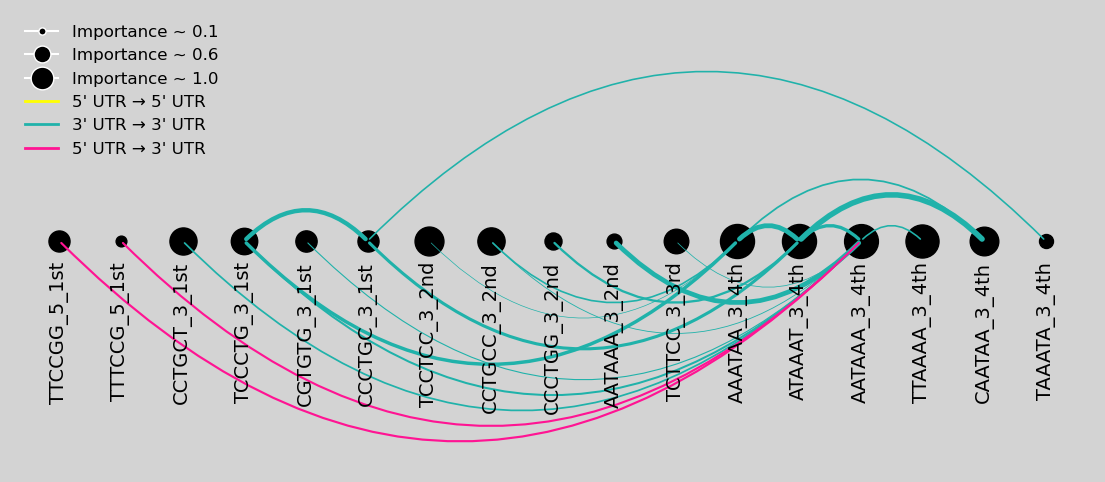

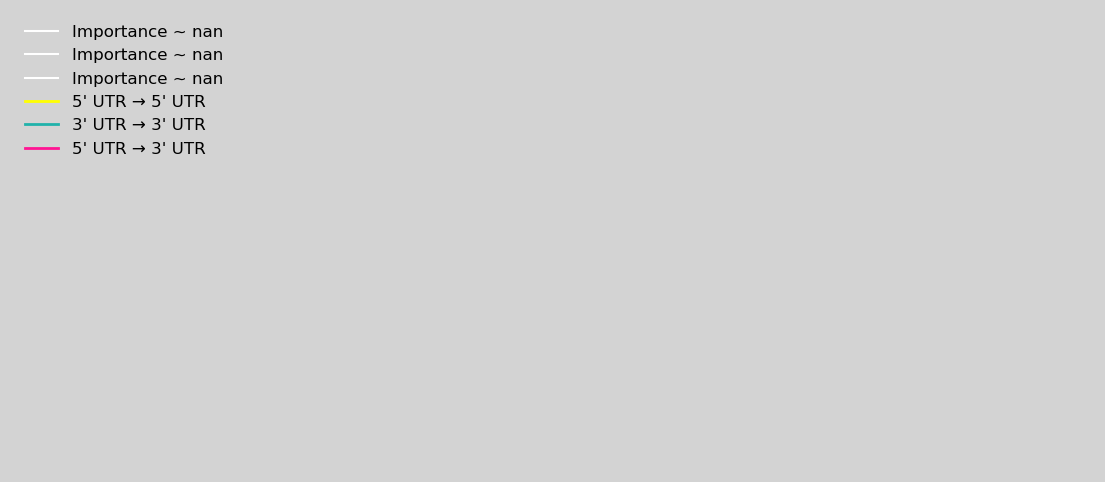

In [259]:
plot_utr_features_with_colored_arcs(positiveComb, utr53 = 'deeppink', utr3s = 'lightseagreen', utr5s = 'yellow')
plot_utr_features_with_colored_arcs(negativeComb, utr53 = 'deeppink', utr3s = 'lightseagreen', utr5s = 'yellow')

In [262]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from matplotlib.lines import Line2D

def plot_utr_features_with_colored_arcs(data, utr53='deeppink', utr3s='lightseagreen', utr5s='yellow'):
    def scale_to_range(column, new_min, new_max):
        return ((column - column.min()) / (column.max() - column.min())) * (new_max - new_min) + new_min

    df = pd.DataFrame(data)
    df['Scaled_FC'] = scale_to_range(df['FC'], 0.1, 1.0)
    df['Scaled_Score'] = scale_to_range(df['Score'], 0.1, 1.0)

    G = nx.Graph()
    
    for _, row in df.iterrows():
        features = row['Feature'].split(',')
        for i in range(len(features) - 1):
            G.add_edge(features[i], features[i + 1], weight=row['Scaled_FC'])
    
    def modify_label(label):
        return label[:-4] + "'UTR" if label[-4:] in ['_1st', '_2nd', '_3rd', '_4th'] else label
    
    def sort_key(node):
        if '_5_1st' in node:
            return 0
        elif '_5_2nd' in node:
            return 1
        elif '_3_1st' in node:
            return 2
        elif '_3_2nd' in node:
            return 3
        elif '_3_3rd' in node:
            return 4
        elif '_3_4th' in node:
            return 5
        return 6  # Catch-all for any other cases
    
    sorted_nodes = sorted(G.nodes, key=sort_key)
    pos_sorted_fixed = {node: (i, 0) for i, node in enumerate(sorted_nodes)}
    
    color_map = {"5to5": utr5s, "3to3": utr3s, "5to3": utr53}
    
    def get_arc_color(u, v):
        if '_5' in u and '_5' in v:
            return color_map["5to5"]
        elif '_3' in u and '_3' in v:
            return color_map["3to3"]
        elif ('_5' in u and '_3' in v) or ('_3' in u and '_5' in v):
            return color_map["5to3"]
        return "black"
    
    def draw_colored_arcs(pos, G, ax):
        for edge in G.edges(data=True):
            u, v = edge[0], edge[1]
            arc_color = get_arc_color(u, v)
            row = df[df['Feature'].str.contains(u) & df['Feature'].str.contains(v)].iloc[0]
            fc_value = row['Scaled_FC']
            lw = 0.1 + (fc_value * 3.9)
            rad = -0.5  
            ax.annotate("",
                        xy=pos[v], xycoords='data',
                        xytext=pos[u], textcoords='data',
                        arrowprops=dict(arrowstyle="-", color=arc_color,
                                        connectionstyle=f"arc3,rad={rad}",
                                        lw=lw))
    
    dot_size_legend = []
    unique_scaled_scores = np.linspace(df['Scaled_Score'].min(), df['Scaled_Score'].max(), num=3)
    sizes = unique_scaled_scores * 600  

    for size in sizes:
        dot_size_legend.append(Line2D([0], [0], marker='o', color='w', label=f'Importance ~ {size / 600:.1f}',
                                      markerfacecolor='black', markersize=(np.sqrt(size) / 1.5)))

    arc_color_legend = [
        Line2D([0], [0], color=color_map["5to5"], lw=2, label="5' UTR → 5' UTR"),
        Line2D([0], [0], color=color_map["3to3"], lw=2, label="3' UTR → 3' UTR"),
        Line2D([0], [0], color=color_map["5to3"], lw=2, label="5' UTR → 3' UTR")
    ]
    
    fig, ax = plt.subplots(figsize=(14, 6))
    fig.patch.set_facecolor('lightgray')
    ax.set_facecolor('lightgray')
    
    for node, (x, y) in pos_sorted_fixed.items():
        row = df[df['Feature'].str.contains(node)].iloc[0]
        size = row['Scaled_Score'] * 600
        nx.draw_networkx_nodes(G, pos={node: (x, y)}, nodelist=[node], node_size=size, node_color='black', ax=ax)
    
    draw_colored_arcs(pos_sorted_fixed, G, ax)
    
    for node, (x, y) in pos_sorted_fixed.items():
        ax.text(x, y - 0.005, modify_label(node), fontsize=14, ha='center', va='top', rotation=90, color='black', zorder=3)
    
    ax.legend(handles=dot_size_legend + arc_color_legend, loc='upper left', frameon=False, fontsize=12, title="")
    
    plt.axis('off')
    plt.show()


In [ ]:
plot_utr_features_with_colored_arcs(positiveComb)
plot_utr_features_with_colored_arcs(negativeComb)

In [332]:
file_paths = {
    "df_5kmer_1st": "kmers/top50_kmers_5_1st.csv",
    "df_5kmer_2nd": "kmers/top50_kmers_5_2nd.csv",
    "df_3kmer_1st": "kmers/top50_kmers_3_1st.csv",
    "df_3kmer_2nd": "kmers/top50_kmers_3_2nd.csv",
    "df_3kmer_3rd": "kmers/top50_kmers_3_3rd.csv",
    "df_3kmer_4th": "kmers/top50_kmers_3_4th.csv",
}

# Read the CSV files into dataframes
dataframes = {name: pd.read_csv(path) for name, path in file_paths.items()}

# Access individual dataframes using their keys
df_5kmer_1st = dataframes["df_5kmer_1st"]
df_5kmer_2nd = dataframes["df_5kmer_2nd"]
df_3kmer_1st = dataframes["df_3kmer_1st"]
df_3kmer_2nd = dataframes["df_3kmer_2nd"]
df_3kmer_3rd = dataframes["df_3kmer_3rd"]
df_3kmer_4th = dataframes["df_3kmer_4th"]

# Optionally, print to verify
print(df_5kmer_1st.head())
print(df_3kmer_1st.head())


        Feature  Importance    Kmer  Mean_Position  SE_Position        FC  \
0  TTTCCG_5_1st    0.001898  TTTCCG       8.765957     9.260331  5.238346   
1  GAGCTG_5_1st    0.001458  GAGCTG      18.392857    10.045750  0.725255   
2  GGAGCA_5_1st    0.001316  GGAGCA      19.789062    10.250497  0.679160   
3  CGGCAG_5_1st    0.001292  CGGCAG      20.115385     9.129384  1.167687   
4  CCTGAC_5_1st    0.001287  CCTGAC      18.109589     8.518411  4.626026   

     Modified_Feature  
0  TTTCCG 08.8 (09.3)  
1  GAGCTG 18.4 (10.0)  
2  GGAGCA 19.8 (10.3)  
3  CGGCAG 20.1 (09.1)  
4  CCTGAC 18.1 (08.5)  
        Feature  Importance    Kmer  Mean_Position  SE_Position         FC  \
0  CTCTGG_3_1st    0.001642  CTCTGG      16.671533     9.386362   0.660011   
1  AGATTT_3_1st    0.001068  AGATTT      13.150000    14.280319  16.496717   
2  CGTGTG_3_1st    0.000972  CGTGTG      19.722222     9.650209   7.492021   
3  CAGCGA_3_1st    0.000962  CAGCGA      17.177419     9.582451   0.998936   
4  

In [143]:
negative_kmers = pd.concat([
    df_5kmer_1st[df_5kmer_1st['FC'] < 1]['Feature'],
    df_5kmer_2nd[df_5kmer_2nd['FC'] < 1]['Feature'],
    df_3kmer_1st[df_3kmer_1st['FC'] < 1]['Feature'],
    df_3kmer_2nd[df_3kmer_2nd['FC'] < 1]['Feature'],
    df_3kmer_3rd[df_3kmer_3rd['FC'] < 1]['Feature'],
    df_3kmer_4th[df_3kmer_4th['FC'] < 1]['Feature']
]).tolist()

positive_kmers = pd.concat([
    df_5kmer_1st[df_5kmer_1st['FC'] > 1]['Feature'],
    df_5kmer_2nd[df_5kmer_2nd['FC'] > 1]['Feature'],
    df_3kmer_1st[df_3kmer_1st['FC'] > 1]['Feature'],
    df_3kmer_2nd[df_3kmer_2nd['FC'] > 1]['Feature'],
    df_3kmer_3rd[df_3kmer_3rd['FC'] > 1]['Feature'],
    df_3kmer_4th[df_3kmer_4th['FC'] > 1]['Feature']
]).tolist()


def classify_kmers(row):
    kmers = row.split(',')
    classification = []
    for kmer in kmers:
        if kmer in positive_kmers:
            classification.append('P')
        elif kmer in negative_kmers:
            classification.append('N')
        else:
            classification.append('')  # Empty string for kmers not in lists
    return ','.join(classification)

# Applying the function to the DataFrame
df['pos_neg'] = df['Feature'].apply(classify_kmers)

print(df)

# df.drop('pos_neg', axis=1, inplace=True)

                                       Feature     Score        FC pos_neg
0       TGCCCT_3_2nd,TCTTCA_3_2nd,AAATGT_3_4th  0.000644  1.010532   P,N,P
1       TCTTCA_3_2nd,GGGCTG_3_3rd,AAATGT_3_4th  0.000484  0.944613   N,N,P
2       AGGGGC_5_2nd,GATACT_3_1st,GTGTTA_3_3rd  0.000414  0.668366   N,N,N
3       CTCCGT_3_1st,GTGTTA_3_3rd,GGCCTC_3_3rd  0.000399  0.594704   N,N,N
4       CGCTGC_5_2nd,TCTTCA_3_2nd,GCTGCC_3_3rd  0.000332  0.879848   P,N,N
...                                        ...       ...       ...     ...
193327  CGGCCC_5_2nd,CCCCTG_5_2nd,GGGGCA_3_1st  0.000000  0.715804   N,N,N
193328  CGGCCC_5_2nd,CCCCTG_5_2nd,CTCCGT_3_1st  0.000000  0.755320   N,N,N
193329  CGGCCC_5_2nd,CCCCTG_5_2nd,TGAGAC_3_2nd  0.000000  0.808156   N,N,N
193330  CGGCCC_5_2nd,CCCCTG_5_2nd,GCAGGC_3_3rd  0.000000  0.760776   N,N,N
193331  AATGAA_3_4th,GGCCTC_3_4th,CCTCCT_3_4th  0.000000  0.773034   N,N,N

[193332 rows x 4 columns]


In [ ]:

# Assuming 'df' is your DataFrame
# Create new labels combining 'pos_neg' and 'Feature'
df['new_labels'] = df['pos_neg'].str.replace(",", "") + " " + df['Feature']

# Plotting
fig, ax = plt.subplots(dpi=350, figsize=(6, 4.5), tight_layout=True)

# Colors based on the condition
colors = np.where(df['FC'] > 1, 'red', 'blue')  # 'red' for 'Positive', 'blue' for 'Negative'

# Scatter plot with custom colors
scatter = ax.scatter(df.index, df['Score'], c=colors, s=6, alpha=0.6)

# Setting x-ticks and labels
ax.set_xticks(df.index)
ax.set_xticklabels(df['new_labels'], fontsize=3, rotation=90, fontname='Monospace')

# Setting plot title and labels
ax.set_title("TOP-50 hexamers within 5' and 3' UTRs predicted (Random forests) to affect TE", fontsize=6)
ax.set_ylabel("Feature importance", fontsize=5)
ax.tick_params(axis='both', labelsize=4, width=0.05, pad=1)
ax.grid(True, linestyle='-', linewidth=0.15)
ax.set_xlim(left=-2, right=len(df) + 1)

# Thinner plot borders
for spine in ax.spines.values():
    spine.set_linewidth(0.2)

# Adding a legend
legend_labels = ['Positive' if fc > 1 else 'Negative' for fc in df['FC']]
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Positive',
                          markerfacecolor='red', markersize=5),
                   Line2D([0], [0], marker='o', color='w', label='Negative',
                          markerfacecolor='blue', markersize=5)]
ax.legend(handles=legend_elements, fontsize=4)

plt.show()


## Bi-modality Regression analysis

Translational regulation often appears heterogeneous across transcripts, with evidence suggesting that mRNAs do not distribute uniformly along a continuous regulatory spectrum. Instead, they may segregate into distinct regulatory regimes.  

To test this hypothesis, we perform regression analysis explicitly incorporating **bi-modality structure** in translational behavior.

---

**Conceptual Rationale**

If translational efficiency were governed purely by gradual tuning of sequence features, we would expect:

- A unimodal distribution of translational output  
- Smooth relationships between motif abundance and expression  

However, accumulating evidence suggests that mRNAs may partition into:

- A **permissive state** characterized by efficient translation  
- A **constrained or regulated state** characterized by reduced or tightly controlled translation  

Such separation implies discrete regulatory architectures rather than incremental modulation.

Bi-modality regression therefore evaluates whether sequence-derived features predict not just magnitude, but **membership in distinct translational regimes**.

---

**Analytical Strategy**

The regression framework:

1. Quantifies translational output as a continuous variable (e.g., ΔTE).
2. Evaluates whether the response distribution exhibits bimodal structure.
3. Tests whether k-mer composition explains variance differently across inferred regulatory states.
4. Assesses whether incorporating bimodal structure improves model fit relative to single-distribution assumptions.

This approach allows us to distinguish:

- Continuous quantitative effects  
- State-dependent regulatory logic  
- Nonlinear transitions between translational regimes  

---

**Biological Interpretation**

If bimodality improves explanatory power, it suggests that:

- Translational control operates in discrete regulatory programs.
- Motif architecture may encode switches rather than sliders.
- Evolution may favor stable translational states rather than intermediate instability.

Such organization would imply that UTR sequence composition encodes regulatory identity, not merely regulatory strength.

---

**Implications**

A bimodal regression framework reframes translational control as:

- Structured
- State-dependent
- Potentially threshold-driven

Rather than purely additive and continuous.

This provides insight into how sequence-level architecture maps onto functional translational phenotypes.

In [ ]:
# For 0.05 test size
# Defining lists to store metrics
rf_train_acc_n_l_ref = []
rf_train_roc_n_l_ref = []
rf_train_f1_n_l_ref = []
rf_test_acc_n_l_ref = []
rf_test_roc_n_l_ref = []
rf_test_f1_n_l_ref = []
rf_val_acc_n_l_ref = []
rf_val_roc_n_l_ref = []
rf_val_f1_n_l_ref = []

rf_train_acc_n_l_sel = []
rf_train_roc_n_l_sel = []
rf_train_f1_n_l_sel = []
rf_test_acc_n_l_sel = []
rf_test_roc_n_l_sel = []
rf_test_f1_n_l_sel = []
rf_val_acc_n_l_sel = []
rf_val_roc_n_l_sel = []
rf_val_f1_n_l_sel = []

rf_train_acc_n_l_sel_opt = []
rf_train_roc_n_l_sel_opt = []
rf_train_f1_n_l_sel_opt = []
rf_test_acc_n_l_sel_opt = []
rf_test_roc_n_l_sel_opt = []
rf_test_f1_n_l_sel_opt = []
rf_val_acc_n_l_sel_opt = []
rf_val_roc_n_l_sel_opt = []
rf_val_f1_n_l_sel_opt = []

model_hyper_param = []
fdr_and_stats_eq_n = []
corr_coeff_train = []
corr_coeff_test = []
    
for n_split in range(N_SPLITS)[0:2]:
    # Spliting data set into train val and test sets
    #-----------------------------------------------
    rnd_seed = RANDOM_SEEDS[n_split]
    
    # numeric features
    X_train_n, X_new, y_train, y_new = train_test_split(X_n, y_categories, test_size=0.05 ,shuffle=True, stratify=y_categories, random_state=rnd_seed)
    X_test_n, X_val_n, y_test, y_val = train_test_split(X_new, y_new, test_size=0.0075 ,shuffle=True, stratify=y_new, random_state=rnd_seed)
 
    X_train_n, X_new, y_train_num, y_new_num = train_test_split(X_n, y, test_size=0.05 ,shuffle=True, stratify=y_categories, random_state=rnd_seed)
    X_test_n, X_val_n, y_test_num, y_val_num = train_test_split(X_new, y_new_num, test_size=0.0075 ,shuffle=True, stratify=y_new, random_state=rnd_seed)
    
    # # labled features
    # No labeled features in that calculation

    
    feat_col_0 = X_train_n.columns

    X_n_kemrs_5_3_utr = pd.concat((X_n_kemrs_5utr,X_n_kemrs_3utr), axis=1)
    
    #kmers-total    
    X_n_kemrs_5_3_prime_train, X_new, y_train, y_new = train_test_split(X_n_kemrs_5_3_utr, y_categories, test_size=0.05 ,shuffle=True, stratify=y_categories, random_state=rnd_seed)
    X_n_kemrs_5_3_prime_test, X_n_kemrs_5_3_prime_val, y_test, y_val = train_test_split(X_new, y_new, test_size=0.0075 ,shuffle=True, stratify=y_new, random_state=rnd_seed)

    X_n_kemrs_5_3_prime_train, X_new, y_train_num, y_new_num = train_test_split(X_n_kemrs_5_3_utr, y, test_size=0.05 ,shuffle=True, stratify=y_categories, random_state=rnd_seed)
    X_n_kemrs_5_3_prime_test, X_n_kemrs_5_3_prime_val, y_test_num, y_val_num = train_test_split(X_new, y_new_num, test_size=0.0075 ,shuffle=True, stratify=y_new, random_state=rnd_seed)
    
    # Main input
    print(f'\nPreprocessing split #{n_split}...\n')
    
    X_train_n_kmer = X_n_kemrs_5_3_prime_train

    X_val_n_kmer = X_n_kemrs_5_3_prime_val

    X_test_n_kmer = X_n_kemrs_5_3_prime_test

    feat_col_1 = X_train_n_kmer.columns

    feat_col = list(feat_col_0) + list(feat_col_1)

    X_train_n = np.concatenate((X_train_n, X_train_n_kmer), axis=1)
    X_val_n = np.concatenate((X_val_n, X_val_n_kmer), axis=1)
    X_test_n = np.concatenate((X_test_n, X_test_n_kmer), axis=1)
    
    # Scaling the numerical features 
    X_train_n_scaled, X_val_n_scaled, X_test_n_scaled = scale_numerics(X_train_n, X_val_n, X_test_n, scaler_type='standard')

    X_train_n_l_scaled = np.copy(X_train_n_scaled)
    X_val_n_l_scaled = np.copy(X_val_n_scaled)
    X_test_n_l_scaled = np.copy(X_test_n_scaled)

    print(X_n_kemrs_5_3_utr.shape)
    print(X_train_n_scaled.shape)
    print(X_val_n_scaled.shape)
    print(X_test_n_scaled.shape)
    
    # 2)
    #----------------------------------------------------- 
    # Selecting numerical features with statistics
    X_train_n_l_scaled_sel, X_val_n_l_scaled_sel, X_test_n_l_scaled_sel, sel_feat_by_stats, sel_feat_by_stats_pval, mannWhit_UpperVsLower = feat_sel_by_stats(X_train_n, X_train_n_l_scaled,
    X_val_n_l_scaled,
    X_test_n_l_scaled,
    y_train, feat_col,
    5e-02)

    fdr_and_stats_eq = np.array_equal(fdrcorrection(sel_feat_by_stats_pval,
                                                        alpha=0.05,
                                                        method='indep',
                                                        is_sorted='False')[0], 
                                      (np.array(sel_feat_by_stats_pval) < 0.05))

    fdr_and_stats_eq_n.append(fdr_and_stats_eq)
    
    print(f'Before feature selection we got {X_train_n_l_scaled.shape[1]} features')
    print(f'After feature selection by stat we got {X_train_n_l_scaled_sel.shape[1]} features')

   


    # Regression
    y_train_num_scaled, y_train_num_pred, y_test_num_scaled, y_test_num_pred, corr_coeff_train_, corr_coeff_test_ = xgb_reg_tune(X_train_=X_train_n_l_scaled_sel,
                                                                                                                                 X_test_=X_test_n_l_scaled_sel,
                                                                                                                                 y_train_num=y_train_num,
                                                                                                                                 y_test_num=y_test_num,
                                                                                                                                 n_estimators=1200, learning_rate=0.12, max_depth=8, gamma=0.05,
                                                                                                                                 bound_lower=-1.75,
                                                                                                                                 bound_higher=2)
    
    
    
    corr_coeff_train.append(corr_coeff_train_)

    corr_coeff_test.append(corr_coeff_test_)
    # End Regression  